In [1]:
# Code Carbon

from codecarbon import OfflineEmissionsTracker

# stop a tracker left running from a previous run of this cell
try:
    tracker.stop()
except NameError:
    pass          # no tracker defined yet (first run)
except Exception:
    pass          # partially-initialized/already-stopped tracker; ignore

tracker = OfflineEmissionsTracker(country_iso_code="USA", log_level="error", project_name="College Baseball XGBoost")
tracker.start()

[codecarbon INFO @ 15:28:32] offline tracker init


[codecarbon WARNING @ 15:28:32] Multiple instances of codecarbon are allowed to run at the same time.


In [2]:
# Imports

import pandas as pd
import numpy as np
import re
import xgboost as xgb
import json
import os
import pynvml
import shap
import shap
from difflib import get_close_matches, SequenceMatcher
from sklearn.model_selection import train_test_split
from scipy.special import expit
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import plotly.express as px
from sklearn.inspection import PartialDependenceDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, classification_report,
    confusion_matrix, mean_absolute_error, r2_score
)

In [3]:
# PUBLIC-DATA VARIANT of xgboostAllWithTeamsV7.ipynb -- generated by
# csv_editing_scripts/make_v7_public_notebooks.py. Do not hand-edit; edit
# the generator so the diff against V7 stays re-derivable.
#   population: full no-minimum population, ~51k rows and a ~4% base rate
#   `age` -> `class_ord`, plus `first_class_ord` (69 player features,
#   151 total); eligibility counts seasons by person_id, not playerid.
#   2026 is absent: the public mirror stopped updating mid-season.

# Settings -- data file, figure output, run configuration.
# The env overrides exist so the metrics harness can run several configurations
# without editing cells; the defaults below are the shipping values.

DATA_FILE      = os.environ.get('V7_DATA_FILE', 'batting_pitching_combined_with_rpi_public_v2_nomin.csv')
TEAM_META_FILE = os.environ.get('V7_TEAM_META', DATA_FILE)
JSON_DIR       = './MLBStatsAPIDraftDataAccess'
PROSPECTS_DIR  = 'mlb_draft_prospects'

# Cap the dataset at a given year (None = every year present in DATA_FILE).
MAX_YEAR = int(os.environ['V7_MAX_YEAR']) if os.environ.get('V7_MAX_YEAR') else None

# The data spells the two-way role 'Two-Way'; the original map only had 'Both',
# which silently turned those rows into NaN.
ROLE_FIX = os.environ.get('V7_ROLE_FIX', '1') == '1'

# 2025/2026 draft JSONs encode round-11+ slot values as the string "0", which is
# truthy -- the loader stored a real $0 instead of a missing value.
SLOT_ZERO_NULL = os.environ.get('V7_SLOT_ZERO_NULL', '1') == '1'

# Playing-time ratios (ported from V10). Counting totals and team totals live in
# separate columns, so without these the trees have to learn the division themselves.
USAGE_FEATURES = os.environ.get('V7_USAGE', '1') == '1'

# EADA program-budget block (12 team-level columns from the federal Equity in Athletics
# Disclosure Act survey; see EADA Data/FEATURES.txt). Requires a DATA_FILE built by
# csv_editing_scripts/add_team_eada.py -- turning this on without those columns will fail
# loudly at the feature-selection cell rather than silently training on fewer features.
EADA_FEATURES = os.environ.get('V7_EADA', '1') == '1'

# `age` is FanGraphs' date of birth, and FanGraphs publishes one only for players
# it has already linked to a professional record. It is null for 43% of rows but
# 0.3% of DRAFTED rows -- P(drafted | age present) 16.9%, P(drafted | age absent)
# 0.07% -- so XGBoost's NaN branch reads "age is missing" as "not drafted" and
# Stage 1 gains ~0.10 PR-AUC it has not earned. That artefact, not the public
# data, is most of the measured public-vs-private gap.
#
# Off by default: the shipping private model does not use age. V7_AGE=1 restores
# it to reproduce the pre-2026-08 numbers.
#
# Scope: this flag governs the MODEL FEATURE ONLY. The pre-draft simulation's
# eligibility filter still reads `age` from the dataframe, because there it
# encodes an actual draft rule -- a player 21 or older is eligible -- rather than
# a learned signal, and it is the private counterpart of the public build's
# `class_ord >= 3` basis. That filter has its own smaller version of the same
# problem (a missing age resolves to 'unknown', which is treated as ineligible,
# so mostly-undrafted players are dropped from the board); it is measured in the
# eligibility audit the simulation prints.
# Guard: csv_editing_scripts/check_feature_leakage.py
AGE_FEATURE = os.environ.get('V7_AGE', '0') == '1'

SAVE_FIGS = True
FIG_DIR   = os.environ.get('V7_FIG_DIR', 'figures_v7_public_nomin')   # never 'figures' -- that is V10's
FIG_DPI   = 200
RUN_TAG   = os.environ.get('V7_RUN_TAG', 'public_nomin')

METRICS = {}   # ledger filled in by the metric cells, dumped as JSON near the end

print(f"DATA_FILE = {DATA_FILE}")
print(f"FIG_DIR   = {FIG_DIR}    MAX_YEAR = {MAX_YEAR}    ROLE_FIX = {ROLE_FIX}")
print(f"SLOT_ZERO_NULL = {SLOT_ZERO_NULL}    USAGE_FEATURES = {USAGE_FEATURES}    RUN_TAG = {RUN_TAG}")
print(f"EADA_FEATURES  = {EADA_FEATURES}")
print(f"AGE_FEATURE    = {AGE_FEATURE}")

DATA_FILE = batting_pitching_combined_with_rpi_public_v2_nomin.csv
FIG_DIR   = figures_v7_public_nomin    MAX_YEAR = None    ROLE_FIX = True
SLOT_ZERO_NULL = True    USAGE_FEATURES = True    RUN_TAG = public_nomin
EADA_FEATURES  = True
AGE_FEATURE    = False


In [4]:
# Batting and pitching dataset with teams
df = pd.read_csv(DATA_FILE, delimiter=',')

if MAX_YEAR is not None:
    df = df[df['year'] <= MAX_YEAR].reset_index(drop=True)
    print(f"Capped at year <= {MAX_YEAR}")

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from {DATA_FILE}")
print(df.groupby('year')['Drafted?'].agg(players='size', drafted='sum'))

Loaded 50,836 rows x 189 columns from batting_pitching_combined_with_rpi_public_v2_nomin.csv
      players  drafted
year                  
2021     9817      411
2022    10039      417
2023    10092      420
2024    10393      435
2025    10495      426


In [5]:
def calc_wp(record):
    if pd.isna(record):
        return np.nan
    
    # Extract all numbers from the string
    nums = re.findall(r'\d+', str(record))
    
    # Need at least wins and losses
    if len(nums) < 2:
        return np.nan
    
    wins = int(nums[0])
    losses = int(nums[1])
    
    total = wins + losses
    
    if total == 0:
        return np.nan
    
    return wins / total

columns = [
    'Conference_Record_team',
    'NC_Rec_team',
    'Home_team',
    'Road_team',
    'Neutral_team',
    'Q1_team',
    'Q2_team',
    'Q3_team',
    'Q4_team'
]

for col in columns:
    new_col = col.replace('_team', '') + '_WP_team'
    df[new_col] = df[col].apply(calc_wp)

/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3878603772.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].apply(calc_wp)
/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3878603772.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[col].apply(calc_wp)
/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3878603772.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

In [6]:
# list and drop columns that are less related to the target
cols_to_drop = ['team_old', 'league_team', 'name', 'playerid', 'person_id', 'class', 'team', 'Acronym', 'Full Name_team', 'Full Team Name', 'Drafted By', 'Drafted From', 'team_new', 'division_team', 'id_team', 'team_teamstats', 'Difference_team', 'conf_national_rec_team', 'Conference_Record_team', 'Conference_Record_Wins_team', 'Conference_Record_Losses_team', 'NC_Rec_team', 'Home_team', 'Road_team', 'Neutral_team', 'Q1_team', 'Q2_team', 'Q3_team', 'Q4_team']
more_cols_to_drop = ['NC_Rec_Wins_team', 'NC_Rec_Losses_team', 'NC_RPI_team', 'NC_SOS_team', 'Home_Wins_team', 'Home_Losses_team', 'Road_Wins_team', 'Road_Losses_team', 'Neutral_Wins_team', 'Neutral_Losses_team', 'Q1_Wins_team', 'Q1_Losses_team', 'Q2_Wins_team', 'Q2_Losses_team', 'Q3_Wins_team', 'Q3_Losses_team', 'Q4_Wins_team', 'Q4_Losses_team']
cols_to_drop.extend(more_cols_to_drop)
df = df.drop(columns=cols_to_drop)
print(df.columns.tolist())

# convert the target to numerical values
df['Drafted?'] = df['Drafted?'].astype(int)


# Pythagorean Expectation Percent: ratio of expected win% (PE) to actual win% (WPCT)
# >1 = team underperformed (unlucky), <1 = team overperformed (lucky)
df['PE_pct_team'] = df['PE_team'] / df['WPCT_team'].replace(0, np.nan)

['nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP_team',

In [7]:
# Playing-time ratios. The raw file keeps counting totals and team totals apart, so without
# these the model has to learn the division itself.
def add_usage_features(d):
    made = []

    def ratio(name, num, den):
        d[name] = d[num] / d[den].replace(0, np.nan)
        made.append(name)

    ratio('ip_per_g_pitch', 'ip_pitch', 'g_pitch')      # innings per appearance
    ratio('start_share_pitch', 'gs_pitch', 'g_pitch')   # share of appearances that were starts
    ratio('pa_per_g_bat', 'pa_bat', 'g_bat')            # plate appearances per game
    ratio('g_share_bat', 'g_bat', 'G_team')             # share of the team's games played
    ratio('ip_share_pitch', 'ip_pitch', 'IP_team')      # share of the team's innings thrown
    ratio('ab_share_bat', 'ab_bat', 'AB_team')          # share of the team's at-bats taken
    ratio('so_per_ip_pitch', 'so_pitch', 'ip_pitch')    # strikeouts on an innings basis
    return made

usage_features = add_usage_features(df) if USAGE_FEATURES else []
print(f"usage features: {len(usage_features)} -> {usage_features}" if usage_features
      else "usage features: disabled")

usage features: 7 -> ['ip_per_g_pitch', 'start_share_pitch', 'pa_per_g_bat', 'g_share_bat', 'ip_share_pitch', 'ab_share_bat', 'so_per_ip_pitch']


/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3930125448.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d[name] = d[num] / d[den].replace(0, np.nan)


In [8]:
pd.options.display.max_columns = None
df.head(10)

,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,rpi_team,SOS_team,budget_pct_eada_team,log_budget_eada_team,opex_per_player_pct_eada_team,log_opex_per_player_eada_team,log_budget_per_player_eada_team,roster_size_eada_team,log_revenue_eada_team,net_revenue_eada_team,coaching_staff_size_eada_team,dept_recruiting_pct_eada_team,log_dept_recruiting_eada_team,log_dept_coach_salary_eada_team,qualified_pitch,qualified_bat,PE_pct_team,class_ord,seasons_elapsed,first_class_ord,Conference_Record_WP_team,NC_Rec_WP_team,Home_WP_team,Road_WP_team,Neutral_WP_team,Q1_WP_team,Q2_WP_team,Q3_WP_team,Q4_WP_team,ip_per_g_pitch,start_share_pitch,pa_per_g_bat,g_share_bat,ip_share_pitch,ab_share_bat,so_per_ip_pitch
0,A.J. Arnold,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,26.0,31.0,2.0,0.0,2.0,0.0,0.0,2.0,3.0,4.0,12.0,1.0,0.0,0.0,NaN,0.0,0.0,0.076923,0.129032,0.387097,0.333333,0.225806,0.153846,0.379653,0.076923,1.303571,0.142857,-0.016059,0.438768,-3.905882,0.204541,10.099033,Batter,NaN,NaN,0,0.4758,22.0,0.4097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,271.0,241.0,0.782895,13.399158,0.908553,8.678972,9.685647,41.0,13.399158,0.0,4.0,0.201974,6.612041,11.422147,NaN,False,NaN,2.0,0.0,2.0,0.333333,0.217391,0.347826,0.160000,1.000000,0.125000,0.000000,0.083333,0.478261,NaN,NaN,3.875000,NaN,NaN,NaN,NaN
1,A.J. Arnold,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0,52.0,11.0,9.0,2.0,0.0,0.0,5.0,3.0,5.0,15.0,0.0,0.0,1.0,0.0,0.0,0.0,0.239130,0.096154,0.288462,0.333333,0.313725,0.282609,0.596334,0.043478,1.470982,0.354839,-0.038104,4.907097,-2.977414,0.299490,62.237180,Batter,NaN,NaN,0,0.4933,15.0,0.4720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,280.0,191.0,0.809235,13.555265,0.906440,9.046291,9.971791,36.0,13.555265,0.0,4.0,0.823815,11.435191,11.580313,NaN,False,NaN,4.0,NaN,NaN,0.266667,0.125000,0.368421,0.121212,0.000000,0.000000,0.000000,0.133333,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A.J. Colarusso,2023,1.0,1.0,8.437500,10.0,5.0,0.0,0.0,1.0,21.1,106.0,32.0,24.0,20.0,2.0,8.0,1.0,1.0,0.0,15.0,6.328125,3.375000,1.875000,0.843750,0.141509,0.075472,0.066038,0.329897,1.875000,0.375000,0.445026,4.701251,3.736249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.5724,2.0,0.7729,37.0,20.0,0.0,57.0,0.649,0.565,304.0,1945.0,527.0,0.271,45.0,0.79,93.0,1.63,506.0,324.0,307.0,5.46,1518.0,511.0,37.0,0.982,58.0,83.0,547.0,9.73,72.0,1.26,27.0,18.0,0.387,64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50836 entries, 0 to 50835
Columns: 158 entries, nameascii to so_per_ip_pitch
dtypes: float64(152), int64(2), object(2), str(2)
memory usage: 61.3+ MB


In [10]:
player_features = list(df[['class_ord', 'role', 'seasons_elapsed', 'first_class_ord', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 
                           'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 
                           'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 
                           'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 
                           'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 
                           'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 
                           'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 
                           'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 
                           'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 
                           'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 
                           'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']].columns)

team_features = list(df[['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                         'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 
                         'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team', '2B_team', '2BPG_team', 
                         'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team', 'PO_team', 'A_team', 
                         'E_team', 'FPCT_team', 'HB_team', 'HBP_team', 'HA_team', 'HAPG_team', 'HR_team', 
                         'HRPG_team', 'SF_team', 'SH_team', 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 
                         'R (Batting)_team', 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team', 
                         'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team', '3B_team', '3BPG_team', 
                         'WHIP_team', 'BBPG (Pitching)_team', 'PE_pct_team']].columns)

rpi_team_features = ['rpi_team', 'SOS_team', 'Conference_Record_WP_team', 'NC_Rec_WP_team', 'Home_WP_team', 'Road_WP_team', 'Neutral_WP_team', 'Q1_WP_team', 'Q2_WP_team', 'Q3_WP_team', 'Q4_WP_team']

# Program resources from the federal EADA survey -- the only block here that is not derived
# from on-field results. Budget columns are given in both within-season percentile and log
# dollars: the percentile is what survives the 2025->2026 carry-forward, since budgets
# inflate ~5%/yr but budget *rank* is stable. The three `dept_` columns are department-wide
# across all men's sports (EADA does not publish coach pay or recruiting spend by sport).
# Data dictionary and the measured A/B: EADA Data/FEATURES.txt
eada_team_features = ['budget_pct_eada_team', 'log_budget_eada_team',
                      'opex_per_player_pct_eada_team', 'log_opex_per_player_eada_team',
                      'log_budget_per_player_eada_team', 'roster_size_eada_team',
                      'log_revenue_eada_team', 'net_revenue_eada_team',
                      'coaching_staff_size_eada_team', 'dept_recruiting_pct_eada_team',
                      'log_dept_recruiting_eada_team', 'log_dept_coach_salary_eada_team']
if EADA_FEATURES:
    missing_eada = [f for f in eada_team_features if f not in df.columns]
    if missing_eada:
        raise KeyError(f"EADA_FEATURES is on but DATA_FILE lacks {missing_eada}. "
                       "Run csv_editing_scripts/add_team_eada.py, or set V7_EADA=0.")
else:
    eada_team_features = []

# The age flag, applied here rather than in the list literal so the column list
# stays a readable inventory of what the matrix carries. A no-op in the public
# variants, which have no `age` column to remove.
if not AGE_FEATURE and 'age' in player_features:
    player_features = [f for f in player_features if f != 'age']
    print(f"AGE_FEATURE off -> `age` dropped; {len(player_features)} player features")

# Partial-dependence plots want "the age-like feature", which differs by build:
# `age` privately, `class_ord` publicly, and `seasons_elapsed` when V7_AGE=0.
# Resolved from the feature list so no variant needs its own edit.
AGE_LIKE = next(f for f in ('age', 'class_ord', 'seasons_elapsed')
                if f in player_features)
print(f"AGE_LIKE (PDP axis) = {AGE_LIKE}")

redundant_features = ['']

# IGNORE
#lasso_selected_features = [
#    'age', 'fip', 'K/9', 'WHIP', 'so', 'g', 'L', 'hr/9', 'wp', 'l', 'ER',
#    'HRPG', 'SF', 'babip', 'SHO', 'A', 'bk', 'BB (Pitching)', 'PE', '3B',
#    'ip', 'FPCT', 'CS', 'w', 'HB', 'DPPG', 'SH', 'T', 'SO', 'BBPG (Pitching)',
#    'SBPG', 'cg', 'RPG', 'k-bb%', 'HBP', '2BPG', 'sho', 'e-f', 'lob%', 'sv', 'E'
#]
# lasso_selected_features = [f for f in lasso_selected_features if f not in redundant_features]
#features = lasso_selected_features

features = player_features + team_features + rpi_team_features + usage_features + eada_team_features
features = [f for f in features if f not in redundant_features]
# The data spells the two-way role 'Two-Way'; the original map only had 'Both',
# so those rows silently became NaN. ROLE_FIX (config cell) controls the behavior.
mapping = ({'Pitcher': 0, 'Batter': 1, 'Two-Way': 2, 'Both': 2} if ROLE_FIX
           else {'Pitcher': 0, 'Batter': 1, 'Both': 2})

# Guard so re-running this cell alone does not map already-numeric roles to NaN.
# Tested as "not yet numeric" rather than "== object": under pandas 3 the default
# string dtype is `str`, not `object`, so the old check silently skipped the
# mapping and handed XGBoost a string column (KeyError: 'str' in
# xgboost/data.py::pandas_feature_info). Both dtypes are non-numeric, so this
# form is correct on pandas 2 and 3 alike.
if not pd.api.types.is_numeric_dtype(df['role']):
    df['role'] = df['role'].map(mapping)
print('role counts:', df['role'].value_counts(dropna=False).to_dict())

X = df[features]
y = df['Drafted?'].astype(int)

AGE_LIKE (PDP axis) = class_ord
role counts: {1.0: 24888, 0.0: 23927, 2.0: 1933, nan: 88}


In [11]:
X.head(10)

,class_ord,role,seasons_elapsed,first_class_ord,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team,rpi_team,SOS_team,Conference_Record_WP_team,NC_Rec_WP_team,Home_WP_team,Road_WP_team,Neutral_WP_team,Q1_WP_team,Q2_WP_team,Q3_WP_team,Q4_WP_team,ip_per_g_pitch,start_share_pitch,pa_per_g_bat,g_share_bat,ip_share_pitch,ab_share_bat,so_per_ip_pitch,budget_pct_eada_team,log_budget_eada_team,opex_per_player_pct_eada_team,log_opex_per_player_eada_team,log_budget_per_player_eada_team,roster_size_eada_team,log_revenue_eada_team,net_revenue_eada_team,coaching_staff_size_eada_team,dept_recruiting_pct_eada_team,log_dept_recruiting_eada_team,log_dept_coach_salary_eada_team
0,2.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,26.0,31.0,2.0,0.0,2.0,0.0,0.0,2.0,3.0,4.0,12.0,1.0,0.0,0.0,NaN,0.0,0.0,0.076923,0.129032,0.387097,0.333333,0.225806,0.153846,0.379653,0.076923,1.303571,0.142857,-0.016059,0.438768,-3.905882,0.204541,10.099033,0.4758,22.0,0.4097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,271.0,241.0,0.333333,0.217391,0.347826,0.160000,1.000000,0.125000,0.000000,0.083333,0.478261,NaN,NaN,3.875000,NaN,NaN,NaN,NaN,0.782895,13.399158,0.908553,8.678972,9.685647,41.0,13.399158,0.0,4.0,0.201974,6.612041,11.422147
1,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0,52.0,11.0,9.0,2.0,0.0,0.0,5.0,3.0,5.0,15.0,0.0,0.0,1.0,0.0,0.0,0.0,0.239130,0.096154,0.288462,0.333333,0.313725,0.282609,0.596334,0.043478,1.470982,0.354839,-0.038104,4.907097,-2.977414,0.299490,62.237180,0.4933,15.0,0.4720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,280.0,191.0,0.266667,0.125000,0.368421,0.121212,0.000000,0.000000,0.000000,0.133333,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.809235,13.555265,0.906440,9.046291,9.971791,36.0,13.555265,0.0,4.0,0.823815,11.435191,11.580313
2,1.0,0.0,0.0,1.0,1.0,1.0,8.437500,10.0,5.0,0.0,0.0,1.0,21.1,106.0,32.0,24.0,20.0,2.0,8.0,1.0,1.0,0.0,15.0,6.328125,3.375000,1.875000,0.843750,0.141509,0.075472,0.066038,0.329897,1.875000,0.375000,0.445026,4.701251,3.736249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5724,2.0,0.7729,37.0,20.0,0.0,57.0,0.649,0.565,304.0,1945.0,527.0,0.271,45.0,0.79,93.0,1.63,506.0,324.0,307.0,5.46,1518.0,511.0,37.0,0.982,58.0,83.0,547.0,9.73,72.0,1.26,27.0,18.0,0.387,64.0,1.12,11.0,374.0,6.6,2.0,844.0,0.434,510.0,201.0,2.54,9.1,NaN,4.0,0.07,1.48,3.58,0.870570,22.0,33.0,0.533333,0.857143,0.590909,0.666667,0.750000,0.466667,0.700000,1.

---
## Figure Helpers

One shared style system for Stages 1-3: the poster palette, a column-name
prettifier, and `save_fig()` writing `figures_v7/s{stage}_{name}.{png,pdf}`.
Every figure below goes through these, so the three stages match.

In [12]:
# Shared figure helpers -- one style system for Stages 1-3.
# Lifted from V10 so V7's figures match; adds `features=` on plot_pdp_grid,
# `sample=None` on plot_pcp, and plot_shap_waterfall().

NAVY, RED, GRAY = '#1a2a4a', '#c8102e', '#d7d7d7'
STAGE_TITLE = {1: 'Stage 1 - Draft Classifier',
               2: 'Stage 2 - College Draft Order',
               3: 'Stage 3 - Signing Bonus / Slot Value'}

# raw column name -> display label
BASE_OVERRIDES = {
    'rpi': 'RPI', 'conf_rpi': 'Conf. RPI', 'sos': 'SOS',
    'wrc': 'wRC', 'wrc+': 'wRC+', 'woba': 'wOBA', 'wraa': 'wRAA', 'wsb': 'wSB',
    'ops': 'OPS', 'slg': 'SLG', 'obp': 'OBP', 'iso': 'ISO', 'avg': 'AVG',
    'babip': 'BABIP', 'spd': 'Spd', 'fip': 'FIP', 'whip': 'WHIP', 'wpct': 'WPCT',
    'k/9': 'K/9', 'bb/9': 'BB/9', 'k/bb': 'K/BB', 'hr/9': 'HR/9', 'era': 'ERA',
    'k%': 'K%', 'bb%': 'BB%', 'k-bb%': 'K-BB%', 'lob%': 'LOB%', 'e-f': 'ERA-FIP',
    # acronyms longer than 3 chars, which the fallback would title-case
    'ip_per_g': 'IP/G', 'start_share': 'Start share', 'pa_per_g': 'PA/G',
    'g_share': 'Team G share', 'ip_share': 'Team IP share',
    'ab_share': 'Team AB share', 'so_per_ip': 'SO/IP',
    'bb/k': 'BB/K', 'tbf': 'TBF', 'gdp': 'GDP', 'fpct': 'FPCT',
    'dppg': 'DPPG', 'hapg': 'HAPG', 'hrpg': 'HRPG', 'sbpg': 'SBPG', 'rpg': 'RPG',
    '2bpg': '2BPG', '3bpg': '3BPG',
    'bb (batting)': 'BB (bat)', 'bb (pitching)': 'BB (pitch)',
    'r (batting)': 'R (bat)', 'r (pitching)': 'R (pitch)',
    'bbpg (pitching)': 'BB/G (pitch)',
}
_TOK = {'conf': 'Conf.', 'wp': 'WP', 'rpi': 'RPI', 'sos': 'SOS', 'pe': 'PE',
        'nc': 'NC', 'wpct': 'WPCT', 'rec': 'Rec', 'pct': '%',
        'q1': 'Q1', 'q2': 'Q2', 'q3': 'Q3', 'q4': 'Q4'}

def _fallback(base):
    out = []
    for p in base.split('_'):
        pl = p.lower()
        if pl in _TOK:                    out.append(_TOK[pl])
        elif len(p) <= 3 and p.isalpha(): out.append(p.upper())
        else:                             out.append(p.capitalize())
    return ' '.join(out)

def _pretty(col):
    if col == 'class_ord':    return 'Class (1=Fr .. 4=Sr)'
    if col == 'role':         return 'Role'
    if col == 'is_post10':    return 'Round 11+'
    for suf in ('_bat', '_pitch', '_team'):
        if col.endswith(suf):
            base, grp = col[:-len(suf)], suf[1:]
            disp = BASE_OVERRIDES.get(base.lower()) or _fallback(base)
            return f"{disp} ({grp})"
    if col.startswith('api_'):
        return 'API ' + _fallback(col[4:])
    return BASE_OVERRIDES.get(col.lower()) or _fallback(col)

def save_fig(fig, stage, name, dpi=None, pdf_only=False):
    """Write figures/s{stage}_{name}.{png,pdf}. stage=None -> no prefix."""
    if not SAVE_FIGS:
        return
    os.makedirs(FIG_DIR, exist_ok=True)
    stem = f"{FIG_DIR}/{'' if stage is None else f's{stage}_'}{name}"
    if not pdf_only:
        fig.savefig(f'{stem}.png', dpi=dpi or FIG_DPI, bbox_inches='tight')
    fig.savefig(f'{stem}.pdf', bbox_inches='tight')
    print(f"  saved {stem}.pdf")

def gain_table(model, label='', top=200, show=True):
    """Gain-importance table, sorted and normalized to % of total gain."""
    gain = model.get_booster().get_score(importance_type='gain')
    t = (pd.DataFrame({'Feature': list(gain.keys()), 'Importance': list(gain.values())})
         .sort_values('Importance', ascending=False).reset_index(drop=True))
    t.insert(0, 'Rank', '#' + (t.index + 1).astype(str))
    t['Label'] = t['Feature'].map(_pretty)
    t['% of gain'] = (100 * t['Importance'] / t['Importance'].sum()).round(2)
    if show:
        print(f"\nFeatures by gain{f' - {label}' if label else ''} "
              f"({len(t)} used of {model.n_features_in_}):")
        with pd.option_context('display.max_rows', None):
            print(t.head(top).to_string(index=False))
    return t

def spearman_ci(a, b, alpha=0.05):
    """Spearman rho with a Fisher z-transform confidence interval."""
    rho, p = spearmanr(a, b)
    n = len(a)
    z, se, zc = np.arctanh(rho), 1 / np.sqrt(max(n - 3, 1)), 1.96
    lo, hi = np.tanh(z - zc * se), np.tanh(z + zc * se)
    print(f"  Spearman: {rho:.3f} (p={p:.2e})  95% CI [{lo:.3f}, {hi:.3f}]  n={n}")
    return rho, p, lo, hi

def _binary_cols(X):
    return {c for c in X.columns if X[c].dropna().nunique() <= 2}

def _top_feature_idx(model, X, top_n, skip_binary=False):
    """Indices of the top-n features by importance, positionally into X."""
    imp = model.feature_importances_
    order = np.argsort(imp)[::-1]
    skip = _binary_cols(X) if skip_binary else set()
    out = [int(i) for i in order if X.columns[i] not in skip and imp[i] > 0]
    return out[:top_n]

def plot_feature_importance(model, stage, top_n=10, as_percent=True, n_highlight=1,
                            name='feature_importance', title=None):
    gain = model.get_booster().get_score(importance_type='gain')
    if not gain:
        print('  (model used no features)'); return
    total = sum(gain.values()) if as_percent else 1.0
    items = sorted(gain.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    labels = [_pretty(k) for k, _ in items][::-1]
    values = [(v / total * 100.0) if as_percent else v for _, v in items][::-1]
    colors = [NAVY] * len(values)
    for j in range(min(n_highlight, len(colors))):
        colors[-(j + 1)] = RED

    fig, ax = plt.subplots(figsize=(11, 4.6))
    ypos = range(len(values))
    ax.barh(ypos, values, color=colors, height=0.62, zorder=3)
    vmax = max(values)
    for yi, v in zip(ypos, values):
        ax.text(v + vmax * 0.012, yi, f"{v:.2f}", va='center', ha='left',
                fontsize=13, color='#222222')
    ax.set_yticks(list(ypos)); ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlim(0, vmax * 1.12)
    ax.set_xlabel('% of total gain' if as_percent else 'gain', fontsize=13)
    ax.set_title(title or f'{STAGE_TITLE[stage]} - Top {len(values)} Features (Gain)',
                 fontsize=17, color=NAVY, pad=16)
    ax.xaxis.grid(True, color=GRAY, linewidth=0.9, zorder=0); ax.set_axisbelow(True)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color('#bbbbbb')
    ax.tick_params(left=False); ax.tick_params(axis='x', labelsize=12, colors='#444444')
    plt.tight_layout()
    save_fig(fig, stage, name)
    plt.show()

def plot_pdp_grid(model, X, stage, top_n=6, name='pdp', skip_binary=True, title=None,
                  features=None):
    """1D partial dependence for the top features. Binary columns are skipped by default,
    since a two-point line reads as a rendering bug."""
    if features is None:
        idx = _top_feature_idx(model, X, top_n, skip_binary=skip_binary)
    else:
        idx = [X.columns.get_loc(c) if isinstance(c, str) else int(c) for c in features]
    if not idx:
        print('  (no non-binary features to plot)'); return
    # .astype(float) as in plot_pdp_2d below: scikit-learn writes float grid
    # values into the column it varies, and pandas 3 raises LossySetitemError
    # on an integer column where pandas 2 silently upcast. sklearn already
    # warns that int columns will be a hard error in 1.9.
    Xp = X.fillna(X.median(numeric_only=True)).astype(float)
    ncol = 3
    nrow = int(np.ceil(len(idx) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.3 * ncol, 4 * nrow), squeeze=False)
    PartialDependenceDisplay.from_estimator(
        model, Xp, features=idx, kind='average',
        ax=axes.flatten()[:len(idx)], grid_resolution=50)
    for ax in axes.flatten()[len(idx):]:
        ax.axis('off')
    for ax in axes[:, 1:].flatten():
        ax.set_ylabel('')
    fig.suptitle(title or f'{STAGE_TITLE[stage]} - Partial Dependence', fontsize=14)
    plt.tight_layout()
    save_fig(fig, stage, name)
    plt.show()

def plot_pdp_2d(model, X, stage, pairs=None, top_n=4, name='pdp_2d', title=None):
    """2D interaction PDPs. Defaults to pairing the top features (0,1), (0,2), (1,3)."""
    if pairs is None:
        idx = _top_feature_idx(model, X, top_n, skip_binary=True)
        if len(idx) < 4:
            print('  (not enough features for interaction pairs)'); return
        pairs = [(idx[0], idx[1]), (idx[0], idx[2]), (idx[1], idx[3])]
    else:
        pairs = [tuple(X.columns.get_loc(c) if isinstance(c, str) else c for c in p) for p in pairs]
    Xp = X.fillna(X.median(numeric_only=True)).astype(float)
    fig, axes = plt.subplots(1, len(pairs), figsize=(6.7 * len(pairs), 5))
    axes = np.atleast_1d(axes)
    for ax, pair in zip(axes, pairs):
        PartialDependenceDisplay.from_estimator(
            model, Xp, features=[pair], kind='average', ax=ax, grid_resolution=30)
        ax.set_xlabel(_pretty(Xp.columns[pair[0]])); ax.set_ylabel(_pretty(Xp.columns[pair[1]]))
    fig.suptitle(title or f'{STAGE_TITLE[stage]} - Feature Interactions', fontsize=14)
    plt.tight_layout()
    save_fig(fig, stage, name)
    plt.show()

def plot_shap_summary(model, X, stage, sample=1500, name='shap_summary'):
    """SHAP beeswarm for the top features."""
    try:
        Xs = X.sample(min(sample, len(X)), random_state=42)
        sv = shap.TreeExplainer(model).shap_values(Xs)
        if isinstance(sv, list):
            sv = sv[1]
        fig = plt.figure()
        shap.summary_plot(sv, Xs, feature_names=[_pretty(c) for c in Xs.columns],
                          max_display=12, show=False, plot_size=(10, 6))
        plt.title(f'{STAGE_TITLE[stage]} - SHAP', fontsize=13)
        plt.tight_layout()
        save_fig(plt.gcf(), stage, name)
        plt.show()
    except Exception as e:
        print(f"  SHAP summary skipped ({e.__class__.__name__}: {e})")

def plot_pcp(frame, cols, color_col, stage, name, title=None, sample=4000,
             scale=None, reverse=False):
    """Plotly parallel coordinates. PDF only, since each export is several MB."""
    d = frame[cols + [color_col]].dropna()
    if sample is not None and len(d) > sample:
        d = d.sample(sample, random_state=42)
    fig = px.parallel_coordinates(
        d, dimensions=cols, color=color_col,
        labels={c: _pretty(c) for c in cols},
        color_continuous_scale=scale or ['#EF553B', '#636EFA'],
        title=title or f'{STAGE_TITLE[stage]} - {_pretty(color_col)}')
    fig.update_layout(width=1000, height=500)
    if reverse:
        fig.update_coloraxes(reversescale=True)
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)
        try:
            fig.write_image(f'{FIG_DIR}/s{stage}_{name}.pdf', scale=2)
            print(f"  saved {FIG_DIR}/s{stage}_{name}.pdf")
        except Exception as e:
            print(f"  PCP export skipped ({e.__class__.__name__}) -- needs kaleido")
    fig.show()

def plot_pr_curve(y_true, y_score, stage=1, name='pr_curve', label='classifier'):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    base = float(np.mean(y_true))
    plt.rcParams.update({'font.size': 13, 'axes.labelsize': 14})
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(rec, prec, lw=2.2, color='#1f77b4', label=f'{label} (PR-AUC = {ap:.3f})')
    ax.axhline(base, ls='--', lw=1.2, color='gray', label=f'Random baseline ({base:.3f})')
    ax.set_xlabel('Recall (drafted)'); ax.set_ylabel('Precision (drafted)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3); ax.legend(loc='upper right')
    plt.tight_layout()
    save_fig(fig, stage, name, dpi=300)
    plt.show()
    return ap

def plot_calibration(y_true, y_prob, stage=1, name='calibration', bins=10):
    frac, mean_pred = calibration_curve(y_true, y_prob, n_bins=bins, strategy='quantile')
    fig, ax = plt.subplots(figsize=(5.6, 5.2))
    ax.plot([0, 1], [0, 1], 'r--', lw=1.2, label='perfect calibration')
    ax.plot(mean_pred, frac, 'o-', color=NAVY, lw=2, label='model')
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed drafted rate')
    ax.set_title(f'{STAGE_TITLE[stage]} - Calibration', fontsize=13)
    ax.grid(ls=':', lw=0.5, alpha=0.6); ax.legend(loc='upper left')
    plt.tight_layout()
    save_fig(fig, stage, name)
    plt.show()

def plot_score_hist(scores, stage=1, name='prob_hist', bins=50, xlabel='Predicted probability'):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(scores, bins=bins, color=NAVY, alpha=0.85)
    ax.set_xlabel(xlabel); ax.set_ylabel('Players')
    ax.set_title(f'{STAGE_TITLE[stage]} - Score Distribution', fontsize=13)
    ax.grid(axis='y', ls=':', lw=0.5, alpha=0.6)
    plt.tight_layout()
    save_fig(fig, stage, name)
    plt.show()

def plot_pred_vs_actual(actual, pred, stage, name='pred_vs_actual', xlabel='Actual',
                        ylabel='Predicted', log=False, ref=None, title=None):
    a, p = np.asarray(actual, float), np.asarray(pred, float)
    plt.rcParams.update({'font.size': 13, 'axes.labelsize': 14})
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(a, p, alpha=0.55, s=26, color=NAVY, edgecolor='none')
    lo, hi = float(min(a.min(), p.min())), float(max(a.max(), p.max()))
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.3, label='perfect')
    if ref is not None:
        ax.axhline(ref, color='gray', ls=':', lw=1); ax.axvline(ref, color='gray', ls=':', lw=1)
    if log:
        ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, fontsize=13)
    ax.grid(ls=':', lw=0.5, alpha=0.5); ax.legend(loc='upper left')
    plt.tight_layout()
    save_fig(fig, stage, name, dpi=300)
    plt.show()

def plot_residuals(actual, pred, stage, name='residuals', hue=None, hue_label='',
                   xlabel='Predicted', ref=0.0):
    a, p = np.asarray(actual, float), np.asarray(pred, float)
    resid = p - a
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    if hue is None:
        axes[0].scatter(p, resid, alpha=0.55, s=26, color=NAVY, edgecolor='none')
    else:
        h = np.asarray(hue)
        for val, col in zip(np.unique(h), [NAVY, RED, '#2a9d8f', '#e9c46a']):
            m = h == val
            axes[0].scatter(p[m], resid[m], alpha=0.6, s=26, color=col, edgecolor='none',
                            label=f'{hue_label}={val}')
        axes[0].legend(fontsize=10)
    axes[0].axhline(ref, color='r', ls='--', lw=1.3)
    axes[0].set_xlabel(xlabel); axes[0].set_ylabel('Residual (pred - actual)')
    axes[0].grid(ls=':', lw=0.5, alpha=0.5)
    axes[1].hist(resid, bins=40, color=NAVY, alpha=0.85)
    axes[1].axvline(ref, color='r', ls='--', lw=1.3)
    axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Players')
    axes[1].grid(axis='y', ls=':', lw=0.5, alpha=0.6)
    fig.suptitle(f'{STAGE_TITLE[stage]} - Residuals', fontsize=14)
    plt.tight_layout()
    save_fig(fig, stage, name)
    plt.show()

def plot_target_dist(series, stage, name='target_dist', by=None, by_label='', ref=None,
                     logx=False, year=None):
    s = pd.Series(series).dropna()
    ncol = 2 if year is None else 3
    fig, axes = plt.subplots(1, ncol, figsize=(6 * ncol, 4.6))
    axes[0].hist(s, bins=60, color=NAVY, alpha=0.85)
    if ref is not None:
        axes[0].axvline(ref, color=RED, ls='--', lw=1.6, label=f'parity ({ref})')
        axes[0].legend(fontsize=10)
    if logx:
        axes[0].set_xscale('log')
    axes[0].set_xlabel(_pretty(name)); axes[0].set_ylabel('Players')
    axes[0].set_title('Distribution', fontsize=12)
    axes[0].grid(axis='y', ls=':', lw=0.5, alpha=0.6)
    if by is not None:
        groups = [s.values[np.asarray(by) == v] for v in np.unique(by)]
        axes[1].boxplot(groups, tick_labels=[f'{by_label}={v}' for v in np.unique(by)])
        axes[1].set_title(f'By {by_label or "group"}', fontsize=12)
    if ref is not None:
        axes[1].axhline(ref, color=RED, ls='--', lw=1.2)
    axes[1].grid(axis='y', ls=':', lw=0.5, alpha=0.6)
    if year is not None:
        axes[2].boxplot([s.values[np.asarray(year) == v] for v in np.unique(year)],
                        tick_labels=[str(int(v)) for v in np.unique(year)])
        if ref is not None:
            axes[2].axhline(ref, color=RED, ls='--', lw=1.2)
        axes[2].set_title('By year', fontsize=12)
        axes[2].grid(axis='y', ls=':', lw=0.5, alpha=0.6)
    fig.suptitle(f'{STAGE_TITLE[stage]} - Target', fontsize=14)
    plt.tight_layout()
    save_fig(fig, stage, name)
    plt.show()

def plot_shap_waterfall(model, X, row, stage, name, title=None, max_display=12):
    """Single-player SHAP waterfall. `row` is an index label or a positional int."""
    try:
        x = X.loc[[row]] if row in X.index else X.iloc[[int(row)]]
        ex = shap.TreeExplainer(model)
        sv = ex.shap_values(x)
        if isinstance(sv, list):
            sv = sv[1]
        base = float(np.atleast_1d(ex.expected_value)[-1])
        exp = shap.Explanation(values=np.asarray(sv)[0], base_values=base,
                               data=x.iloc[0].values,
                               feature_names=[_pretty(c) for c in X.columns])
        plt.figure(figsize=(9, 0.42 * max_display + 2))
        shap.plots.waterfall(exp, max_display=max_display, show=False)
        fig = plt.gcf()
        if title:
            fig.suptitle(title, fontsize=13, color=NAVY, y=1.02)
        plt.tight_layout()
        save_fig(fig, stage, name)
        plt.show()
    except Exception as e:
        print(f"  waterfall skipped ({e.__class__.__name__}: {e})")


def waterfall_picks(actual, pred, index, higher_is_better=True):
    """(best, worst) positional picks: the marquee case and the largest miss."""
    a, p = np.asarray(actual, float), np.asarray(pred, float)
    best = int(np.argmax(a) if higher_is_better else np.argmin(a))
    worst = int(np.argmax(np.abs(p - a)))
    return index[best], index[worst], best, worst


print('figure helpers ready:',
      'importance, pdp_grid, pdp_2d, shap_summary, shap_waterfall, pcp, pr_curve,',
      'calibration, score_hist, pred_vs_actual, residuals, target_dist')

figure helpers ready: importance, pdp_grid, pdp_2d, shap_summary, shap_waterfall, pcp, pr_curve, calibration, score_hist, pred_vs_actual, residuals, target_dist


In [13]:
# Separate the two classes
drafted_indices = df[df['Drafted?'] == 1].index
not_drafted_indices = df[df['Drafted?'] == 0].index

print(f"Original class distribution:")
print(f"  Class 0 (Not Drafted): {len(not_drafted_indices)}")
print(f"  Class 1 (Drafted): {len(drafted_indices)}")

# Randomly sample from class 0 to match class 1 size
np.random.seed(40)  # for reproducibility
undersampled_not_drafted = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)

# Combine the balanced indices
balanced_indices = np.concatenate([drafted_indices, undersampled_not_drafted])
np.random.shuffle(balanced_indices)

# Create balanced dataset
X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print(f"\nBalanced class distribution:")
print(f"  Class 0 (Not Drafted): {sum(y_balanced == 0)}")
print(f"  Class 1 (Drafted): {sum(y_balanced == 1)}")
print(f"  Total samples: {len(y_balanced)}")
print(f"  Class 1 percentage: {sum(y_balanced == 1) / len(y_balanced) * 100:.1f}%")

Original class distribution:
  Class 0 (Not Drafted): 48727
  Class 1 (Drafted): 2109

Balanced class distribution:
  Class 0 (Not Drafted): 2109
  Class 1 (Drafted): 2109
  Total samples: 4218
  Class 1 percentage: 50.0%


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

In [15]:
# Show training class distribution and compute scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

print(f"\nTraining set distribution:")
print(f"  Class 0: {neg_count}")
print(f"  Class 1: {pos_count}")
print(f"  Scale_pos_weight: {scale_pos_weight:.2f}")


Training set distribution:
  Class 0: 1687
  Class 1: 1687
  Scale_pos_weight: 1.00


In [16]:
# Train XGBoost classifier on balanced training set
draft_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

draft_model.fit(X_train, y_train)

y_pred = draft_model.predict(X_test)
y_proba = draft_model.predict_proba(X_test)[:,1]

print("\nDrafted? Classifier Results (Balanced Dataset):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))

METRICS['s1_balanced'] = dict(
    n=int(len(y_test)),
    accuracy=float(accuracy_score(y_test, y_pred)),
    precision=float(precision_score(y_test, y_pred, zero_division=0)),
    recall=float(recall_score(y_test, y_pred, zero_division=0)),
    f1=float(f1_score(y_test, y_pred, zero_division=0)),
    roc_auc=float(roc_auc_score(y_test, y_proba)),
)


Drafted? Classifier Results (Balanced Dataset):
Accuracy: 0.896

              precision    recall  f1-score   support

           0      0.924     0.863     0.892       422
           1      0.871     0.929     0.899       422

    accuracy                          0.896       844
   macro avg      0.897     0.896     0.896       844
weighted avg      0.897     0.896     0.896       844



In [17]:
# Show top features by importance from the trained classifier
importance = draft_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                          Feature  Importance
0      #1                         rpi_team   55.986729
1      #2                          wrc_bat   51.702225
2      #3                         so_pitch   28.352045
3      #4             budget_pct_eada_team   12.612155
4      #5                         wraa_bat    9.834267
5      #6                      k-bb%_pitch    9.814281
6      #7                          SO_team    9.065025
7      #8                         k%_pitch    8.953067
8      #9                            r_bat    7.631636
9     #10                        class_ord    6.821507
10    #11                     pa_per_g_bat    6.816931
11    #12                          slg_bat    5.338664
12    #13                   ip_per_g_pitch    4.283389
13    #14                        tbf_pitch    4.260262
14    #15                         ip_pitch    4.227732
15    #16                start_share_pitch    3.509768
16    #17                         SO

  saved figures_v7_public_nomin/s1_feature_importance.pdf


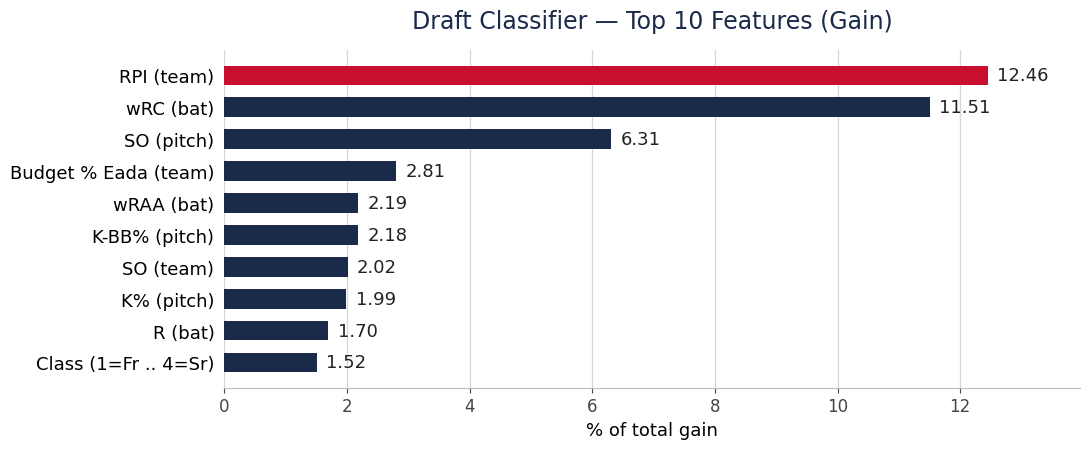

In [18]:
# Stage 1 feature-importance bar chart (paper figure) -- top 10 by gain, as % of total.
plot_feature_importance(draft_model, stage=1, top_n=10,
                        title='Draft Classifier — Top 10 Features (Gain)')

/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3837196070.py:194: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, feature_names=[_pretty(c) for c in Xs.columns],


  saved figures_v7_public_nomin/s1_shap_summary.pdf


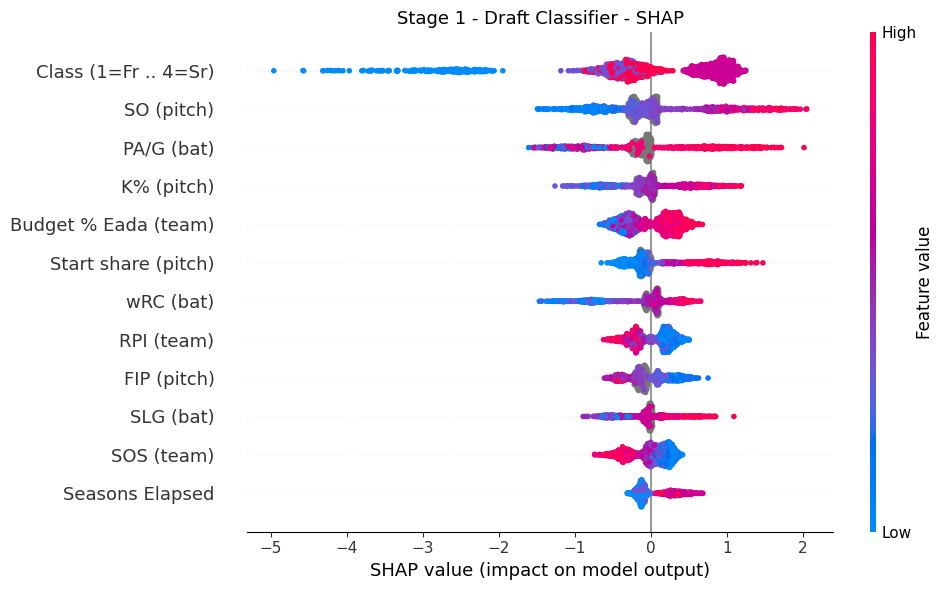

In [19]:
# Stage 1 -- SHAP beeswarm over the balanced training set.
plot_shap_summary(draft_model, X_train, stage=1)

  saved figures_v7_public_nomin/s1_waterfall_top.pdf


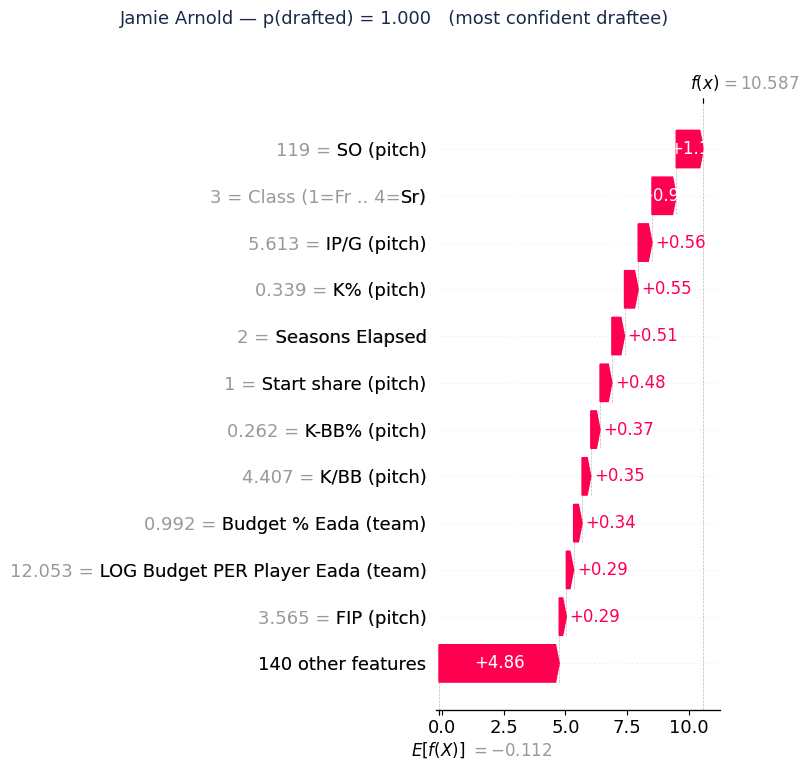

  saved figures_v7_public_nomin/s1_waterfall_borderline.pdf


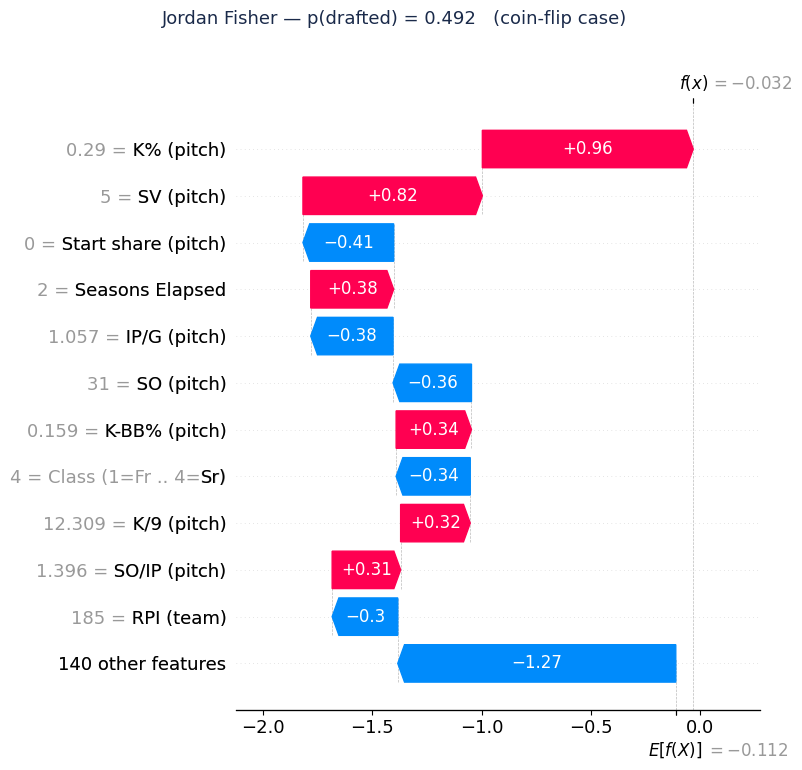

  saved figures_v7_public_nomin/s1_waterfall_miss.pdf


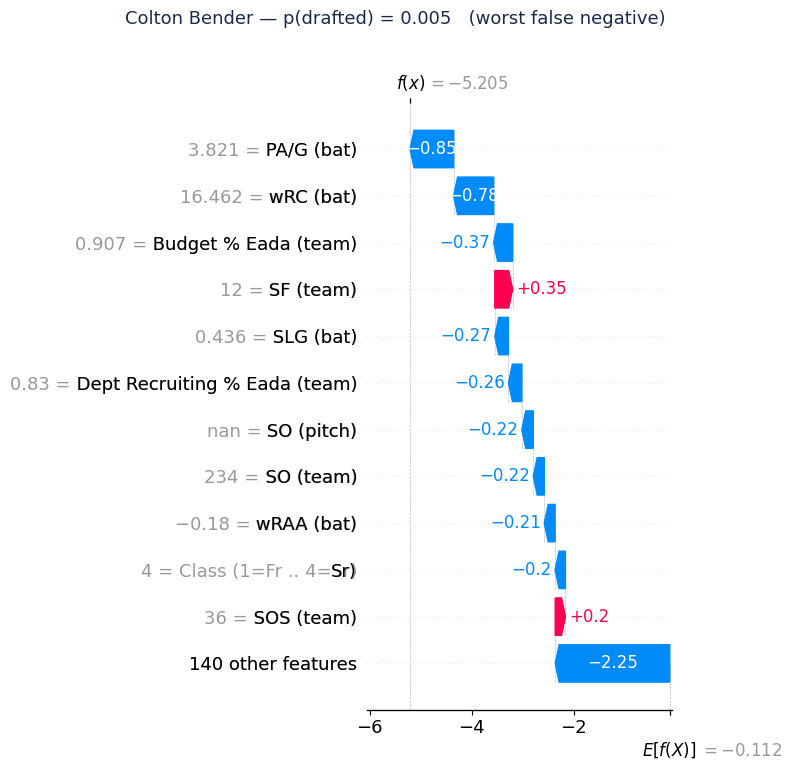

In [20]:
# Stage 1 -- per-player SHAP waterfalls.
# Three cases: the most confident draftee, the coin-flip case that motivates the
# threshold sweep further down, and the worst false negative.
_names1  = df.loc[X_test.index, 'nameascii'].values
_yt1     = np.asarray(y_test)
_i_top1  = int(np.argmax(y_proba))
_i_edge1 = int(np.argmin(np.abs(y_proba - 0.5)))
_pos1    = np.where(_yt1 == 1)[0]
_i_miss1 = int(_pos1[np.argmin(y_proba[_pos1])]) if len(_pos1) else _i_top1

for _i, _slug, _blurb in [(_i_top1,  'waterfall_top',        'most confident draftee'),
                          (_i_edge1, 'waterfall_borderline', 'coin-flip case'),
                          (_i_miss1, 'waterfall_miss',       'worst false negative')]:
    plot_shap_waterfall(draft_model, X_test, X_test.index[_i], stage=1, name=_slug,
                        title=f"{_names1[_i]} — p(drafted) = {y_proba[_i]:.3f}   ({_blurb})")

In [21]:
# Parallel coordinates: pitching features by actual draft status
pcp_features = ['rpi_team', 'era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

plot_pcp(df, pcp_features, 'Drafted?', stage=1, name='pcp_actual', sample=None,
         title='Stage 1 — Pitching Features by Draft Status')

  saved figures_v7_public_nomin/s1_pcp_actual.pdf


In [22]:
pcp_features = ['rpi_team', 'era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

# keep X_test's index/order so predictions stay paired with rows
pcp_df = X_test[pcp_features].copy()
pcp_df['Drafted?'] = np.asarray(y_pred)[:len(pcp_df)]   # positional, avoids index-alignment surprises

before = len(pcp_df)
pcp_df = pcp_df.dropna(subset=pcp_features)
print(f"Dropped {before - len(pcp_df)} rows with NaN features, {len(pcp_df)} remaining")

plot_pcp(pcp_df, pcp_features, 'Drafted?', stage=1, name='pcp_predicted', sample=None,
         title='Stage 1 — Pitching Features by Predicted Draft Status')

Dropped 375 rows with NaN features, 469 remaining


  saved figures_v7_public_nomin/s1_pcp_predicted.pdf


In [23]:
pcp_features = ['rpi_team', 'era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

# keep X_test's index/order so predictions stay paired with rows
pcp_df = X_test[pcp_features].copy()
pcp_df['Drafted?'] = np.asarray(y_proba)[:len(pcp_df)]   # positional, avoids index-alignment surprises

before = len(pcp_df)
pcp_df = pcp_df.dropna(subset=pcp_features)
print(f"Dropped {before - len(pcp_df)} rows with NaN features, {len(pcp_df)} remaining")

plot_pcp(pcp_df, pcp_features, 'Drafted?', stage=1, name='pcp_probability', sample=None,
         title='Stage 1 — Pitching Features by Predicted Draft Probability')

Dropped 375 rows with NaN features, 469 remaining


  saved figures_v7_public_nomin/s1_pcp_probability.pdf


  saved figures_v7_public_nomin/s1_prob_hist.pdf


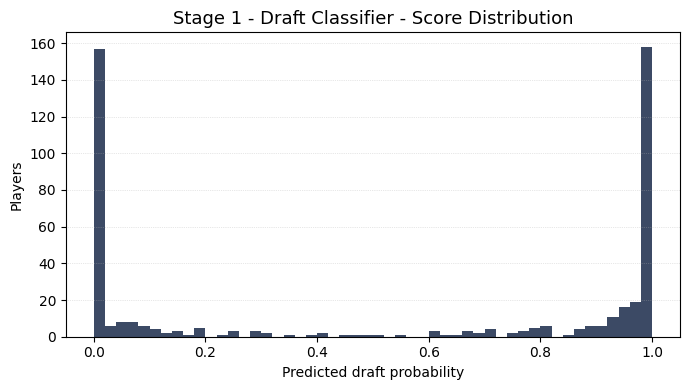

In [24]:
plot_score_hist(y_proba[:len(pcp_df)], stage=1,
                xlabel='Predicted draft probability')

  saved figures_v7_public_nomin/s1_calibration.pdf


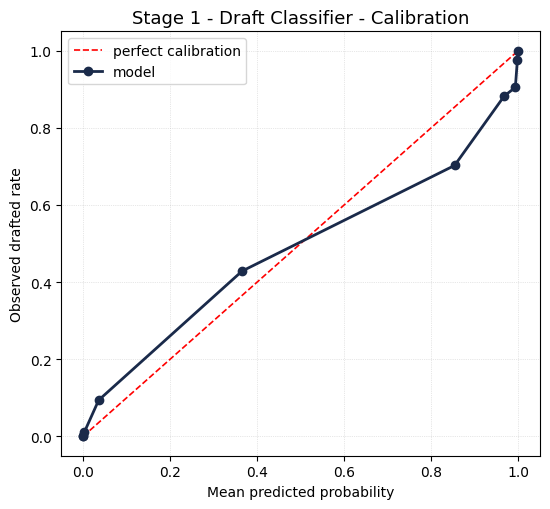

In [25]:
# Stage 1 -- reliability of the predicted probabilities on the balanced test set.
plot_calibration(y_test, y_proba, stage=1)

  saved figures_v7_public_nomin/s1_pdp.pdf


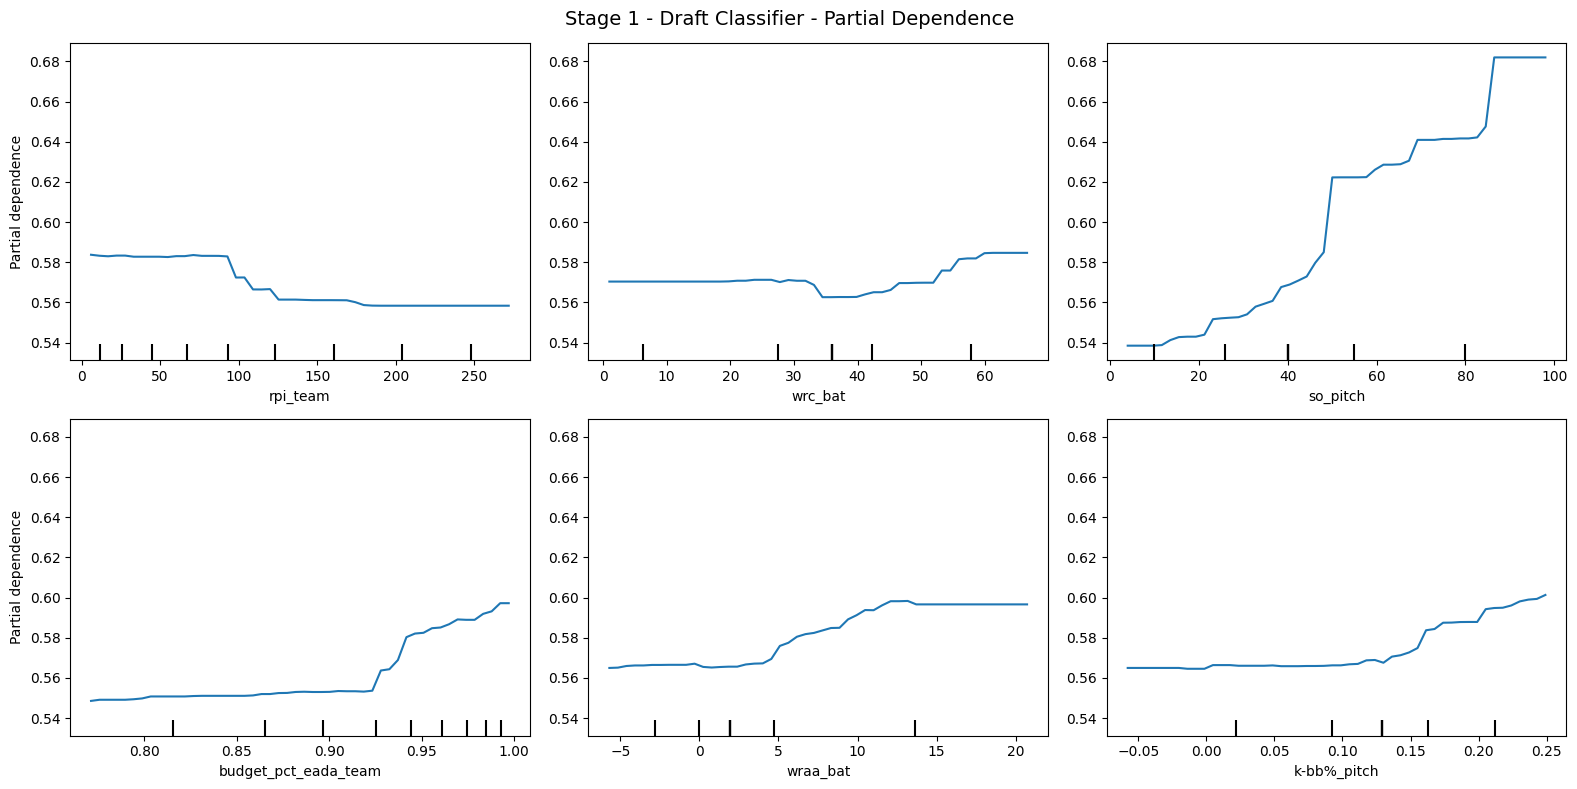

In [26]:
# Partial Dependence Plots - Draft Probability Classifier
# skip_binary=False keeps the same top-6-by-importance selection the cell used before.
plot_pdp_grid(draft_model, X_balanced, stage=1, top_n=6, skip_binary=False)

  saved figures_v7_public_nomin/s1_pdp_shap_dependence.pdf


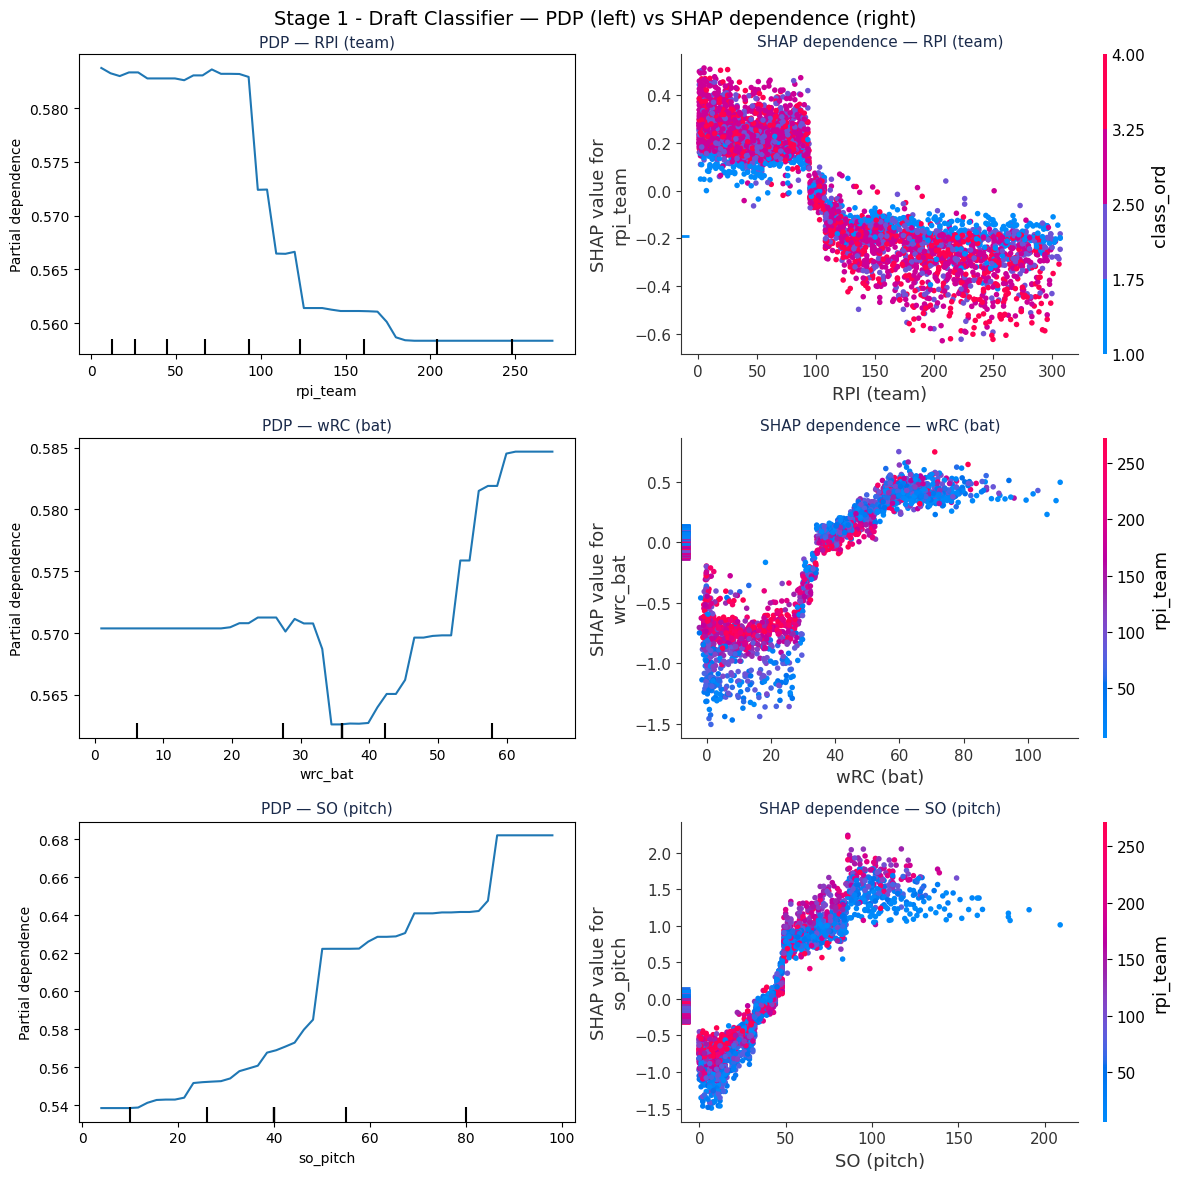

In [27]:
# Stage 1 -- PDP (left) vs SHAP dependence (right) for the top features.
top_n = 3
importances = draft_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:top_n].tolist()
top_names = X_balanced.columns[top_indices].tolist()

# PDP needs a NaN-free grid; SHAP can use the real (NaN-containing) data
X_pdp = X_balanced.fillna(X_balanced.median()).astype(float)

# Compute SHAP once, reuse for every right-column panel (TreeExplainer is exact + fast for XGB)
explainer = shap.TreeExplainer(draft_model)
shap_exp = explainer.shap_values(X_balanced)
if isinstance(shap_exp, list):      # older SHAP returns [class0, class1]
    shap_exp = shap_exp[1]          # keep positive (drafted) class

fig, axes = plt.subplots(top_n, 2, figsize=(12, 4 * top_n))

for row, (idx, name) in enumerate(zip(top_indices, top_names)):
    PartialDependenceDisplay.from_estimator(
        draft_model, X_pdp, features=[idx],
        kind='average', ax=axes[row, 0], grid_resolution=50
    )
    axes[row, 0].set_xlabel(_pretty(name))
    axes[row, 0].set_title(f'PDP — {_pretty(name)}', fontsize=11, color=NAVY)

    shap.dependence_plot(
        idx, shap_exp, X_balanced,
        ax=axes[row, 1], show=False, interaction_index='auto'
    )
    axes[row, 1].set_xlabel(_pretty(name))
    axes[row, 1].set_title(f'SHAP dependence — {_pretty(name)}', fontsize=11, color=NAVY)

fig.suptitle(f'{STAGE_TITLE[1]} — PDP (left) vs SHAP dependence (right)', fontsize=14)
plt.tight_layout()
save_fig(fig, 1, 'pdp_shap_dependence')
plt.show()

  saved figures_v7_public_nomin/s1_pdp_2d.pdf


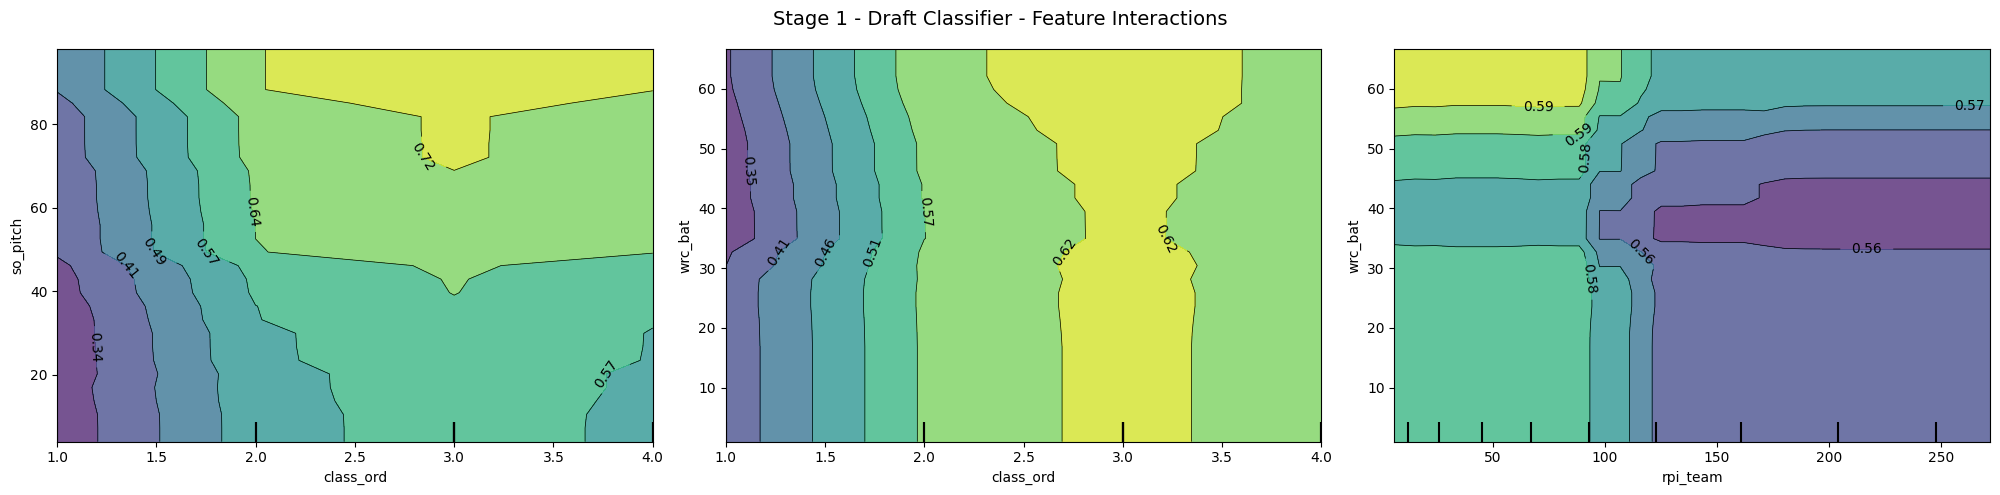

In [28]:
# The three fixed interactions the paper discusses, independent of importance order.
plot_pdp_2d(draft_model, X_balanced, stage=1, name='pdp_2d',
            pairs=[(AGE_LIKE, 'so_pitch'), (AGE_LIKE, 'wrc_bat'), ('rpi_team', 'wrc_bat')])

Top 6 features for PDP: ['RPI (team)', 'wRC (bat)', 'SO (pitch)', 'Budget % Eada (team)', 'wRAA (bat)', 'K-BB% (pitch)']


  saved figures_v7_public_nomin/s1_pdp_paper.pdf


  saved figures_v7_public_nomin/s1_pdp.pdf


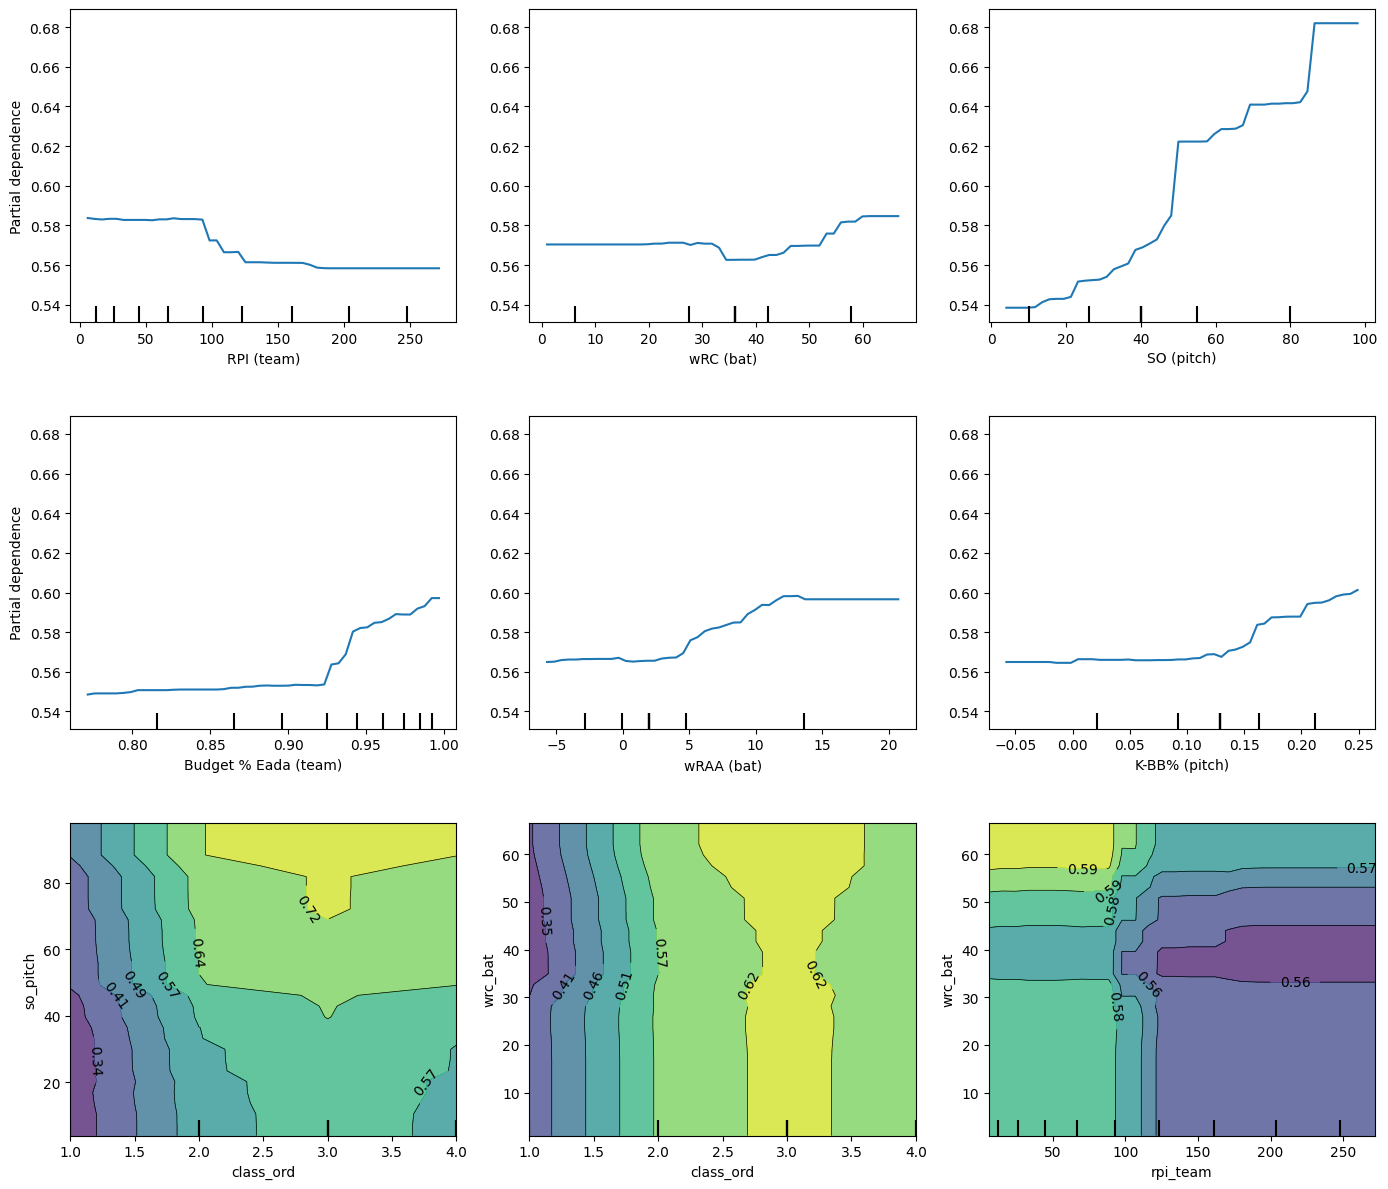

In [29]:
# Stage 1 paper figure: 2 rows of 1D PDPs over the top 6 features, plus a
# bottom row of the three fixed 2D interactions.

top_indices = np.argsort(draft_model.feature_importances_)[::-1][:6].tolist()
top_names = [X_balanced.columns[i] for i in top_indices]
print("Top 6 features for PDP:", [_pretty(n) for n in top_names])

pairs = [(AGE_LIKE, 'so_pitch'), (AGE_LIKE, 'wrc_bat'), ('rpi_team', 'wrc_bat')]
missing = [c for p in pairs for c in p if c not in X_balanced.columns]
if missing:
    raise ValueError(f"Missing required columns for the fixed 2D PDPs: {sorted(set(missing))}")
pair_idx = [(X_balanced.columns.get_loc(a), X_balanced.columns.get_loc(b)) for a, b in pairs]

X_pdp = X_balanced.fillna(X_balanced.median()).astype(float)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

# Top two rows: 1D PDPs for the top 6 features
PartialDependenceDisplay.from_estimator(
    draft_model, X_pdp, features=top_indices, kind='average',
    ax=axes[:2].flatten(), grid_resolution=50
)
for ax, name in zip(axes[:2].flatten(), top_names):
    ax.set_xlabel(_pretty(name))

# Bottom row: fixed 2D interaction PDPs
for ax, pair in zip(axes[2], pair_idx):
    PartialDependenceDisplay.from_estimator(
        draft_model, X_pdp, features=[pair], kind='average',
        ax=ax, grid_resolution=30
    )
    ax.set_xlabel(_pretty(X_pdp.columns[pair[0]]))
    ax.set_ylabel(_pretty(X_pdp.columns[pair[1]]))

# Keep "Partial dependence" only on the left 1D column (top two rows).
# Bottom-row y-labels are feature names, so leave them alone.
for ax in axes[:2, 1:].flatten():
    ax.set_ylabel('')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)

# Saved under both names: 'pdp_paper' is the composite, and 'pdp' is kept because
# the paper already cites s1_pdp.pdf.
save_fig(fig, 1, 'pdp_paper')
save_fig(fig, 1, 'pdp')
plt.show()

Not-drafted players the model never saw: 46618
Drafted players in balanced test set (unseen by model): 422
Target Positive Rate: 4.15%

Operational test set:
  Total samples:   10172
  Positives:       422 (4.15%)
  Target rate:     4.15%

OPERATIONAL METRICS (imbalanced test set)
  PR-AUC:        0.556    (random baseline 0.041)
  ROC-AUC:       0.962

  Thresh      Prec    Recall      F1       TN    FP    FN    TP
  0.50       0.248     0.929   0.391     8561  1189    30   392
  0.40       0.231     0.936   0.371     8438  1312    27   395
  0.30       0.212     0.943   0.346     8270  1480    24   398
  0.20       0.194     0.955   0.322     8074  1676    19   403

Full classification report at threshold 0.5:
              precision    recall  f1-score   support

 Not drafted      0.997     0.878     0.934      9750
     Drafted      0.248     0.929     0.391       422

    accuracy                          0.880     10172
   macro avg      0.622     0.903     0.662     10172
weight

  saved figures_v7_public_nomin/s1_pr_curve.pdf


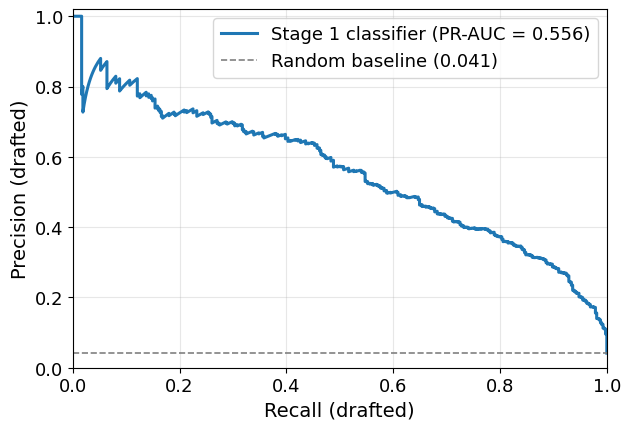


VALUES FOR THE PAPER

ABSTRACT and CONCLUSION:
  PR-AUC 0.556 on the operational imbalanced distribution

RESULTS PARAGRAPH (Stage 1, operational):
  PR-AUC:                       0.556
  ROC-AUC:                      0.962
  Random baseline (PR):         0.041
  At threshold 0.5: precision = 0.248, recall = 0.929
  At threshold 0.3: precision = 0.212, recall = 0.943

The model achieves PR-AUC of 0.556 on this imbalanced test set
(random baseline 0.041) and ROC-AUC of 0.962.
At the default 0.5 probability threshold, operational precision on the
drafted class is 0.248 with recall 0.929;
lowering the threshold to 0.3 raises recall to 0.943 at
the cost of precision 0.212.



In [30]:
# Used AI to help make the PR-AUC and ROC-AUC numbers for the paper

# Operational (imbalanced) evaluation for Stage 1
#
# Reuses the trained model (no retraining) and evaluates it
# on a constructed test set at the natural positive rate of the data.
# This gives the reviewer-facing operational metrics (PR-AUC,
# threshold-specific precision/recall) without changing any of
# the balanced numbers

# Step 1: Identify rows the model has never seen
# `undersampled_not_drafted` are the not-drafted players included
# in the balanced training+test pool. Everything else is unseen.
unseen_not_drafted_idx = np.setdiff1d(
    not_drafted_indices.values,
    undersampled_not_drafted
)
print(f"Not-drafted players the model never saw: {len(unseen_not_drafted_idx)}")

# Drafted players in y_test were held out from training; reusing them.
drafted_test_idx = y_test[y_test == 1].index.values
print(f"Drafted players in balanced test set (unseen by model): {len(drafted_test_idx)}")

# Step 2: Build the operational test set at the natural positive rate
# To hit the natural rate, the negative-class sample size is:
#     n_neg = n_pos * (1 - p) / p,  where p = target_positive_rate
target_positive_rate = drafted_indices.shape[0] / df.shape[0]
print(f"Target Positive Rate: {target_positive_rate*100:.2f}%")
n_pos = len(drafted_test_idx)
n_neg = int(round(n_pos * (1 - target_positive_rate) / target_positive_rate))

# Safety check
n_neg = min(n_neg, len(unseen_not_drafted_idx))

np.random.seed(42)
op_neg_idx = np.random.choice(unseen_not_drafted_idx, size=n_neg, replace=False)

op_test_idx = np.concatenate([drafted_test_idx, op_neg_idx])
X_op_test = X.loc[op_test_idx]
y_op_test = y.loc[op_test_idx]

print(f"\nOperational test set:")
print(f"  Total samples:   {len(y_op_test)}")
print(f"  Positives:       {y_op_test.sum()} ({y_op_test.mean()*100:.2f}%)")
print(f"  Target rate:     {target_positive_rate*100:.2f}%")

# Step 3: Score with the existing draft_model
y_op_proba = draft_model.predict_proba(X_op_test)[:, 1]
baseline_pr = y_op_test.mean()

pr_auc  = average_precision_score(y_op_test, y_op_proba)
roc_auc = roc_auc_score(y_op_test, y_op_proba)

def metrics_at_thresh(threshold):
    y_pred = (y_op_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_op_test, y_pred, zero_division=0),
        "recall":    recall_score(y_op_test, y_pred, zero_division=0),
        "f1":        f1_score(y_op_test, y_pred, zero_division=0),
        "tn_fp_fn_tp": confusion_matrix(y_op_test, y_pred).ravel().tolist(),
    }

results = [metrics_at_thresh(t) for t in (0.50, 0.40, 0.30, 0.20)]

# Step 4: Print everything cleanly
print("\n" + "=" * 64)
print("OPERATIONAL METRICS (imbalanced test set)")
print("=" * 64)
print(f"  PR-AUC:        {pr_auc:.3f}    (random baseline {baseline_pr:.3f})")
print(f"  ROC-AUC:       {roc_auc:.3f}")
print()
print(f"  {'Thresh':<8}{'Prec':>8}{'Recall':>10}{'F1':>8}    {'TN':>5} {'FP':>5} {'FN':>5} {'TP':>5}")
for r in results:
    tn, fp, fn, tp = r["tn_fp_fn_tp"]
    print(f"  {r['threshold']:<8.2f}{r['precision']:>8.3f}{r['recall']:>10.3f}"
          f"{r['f1']:>8.3f}    {tn:>5} {fp:>5} {fn:>5} {tp:>5}")

print("\nFull classification report at threshold 0.5:")
print(classification_report(
    y_op_test, (y_op_proba >= 0.5).astype(int),
    target_names=["Not drafted", "Drafted"], digits=3
))

# Step 5: Precision-recall curve
plot_pr_curve(y_op_test, y_op_proba, stage=1, label="Stage 1 classifier")

# Step 6: Snippet for the paper placeholders
r05 = results[0]   # threshold 0.5
r03 = results[2]   # threshold 0.3

print("\n" + "=" * 64)
print("VALUES FOR THE PAPER")
print("=" * 64)
print(f"""
ABSTRACT and CONCLUSION:
  PR-AUC {pr_auc:.3f} on the operational imbalanced distribution

RESULTS PARAGRAPH (Stage 1, operational):
  PR-AUC:                       {pr_auc:.3f}
  ROC-AUC:                      {roc_auc:.3f}
  Random baseline (PR):         {baseline_pr:.3f}
  At threshold 0.5: precision = {r05['precision']:.3f}, recall = {r05['recall']:.3f}
  At threshold 0.3: precision = {r03['precision']:.3f}, recall = {r03['recall']:.3f}

The model achieves PR-AUC of {pr_auc:.3f} on this imbalanced test set
(random baseline {baseline_pr:.3f}) and ROC-AUC of {roc_auc:.3f}.
At the default 0.5 probability threshold, operational precision on the
drafted class is {r05['precision']:.3f} with recall {r05['recall']:.3f};
lowering the threshold to 0.3 raises recall to {r03['recall']:.3f} at
the cost of precision {r03['precision']:.3f}.
""")

METRICS['s1_operational'] = dict(
    n=int(len(y_op_test)), n_pos=int(y_op_test.sum()),
    base_rate=float(baseline_pr), pr_auc=float(pr_auc), roc_auc=float(roc_auc),
    pr_lift=float(pr_auc / baseline_pr),
    thresholds={f"{r['threshold']:.2f}": dict(precision=float(r['precision']),
                                              recall=float(r['recall']),
                                              f1=float(r['f1'])) for r in results},
)

In [31]:
# Now to set up for pick prediction among drafted players

target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

# Keep only drafted players
drafted_df = df[df[target_drafted] == 1].copy()
pd.options.display.max_columns = None
display(drafted_df.head(5))

,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,rpi_team,SOS_team,budget_pct_eada_team,log_budget_eada_team,opex_per_player_pct_eada_team,log_opex_per_player_eada_team,log_budget_per_player_eada_team,roster_size_eada_team,log_revenue_eada_team,net_revenue_eada_team,coaching_staff_size_eada_team,dept_recruiting_pct_eada_team,log_dept_recruiting_eada_team,log_dept_coach_salary_eada_team,qualified_pitch,qualified_bat,PE_pct_team,class_ord,seasons_elapsed,first_class_ord,Conference_Record_WP_team,NC_Rec_WP_team,Home_WP_team,Road_WP_team,Neutral_WP_team,Q1_WP_team,Q2_WP_team,Q3_WP_team,Q4_WP_team,ip_per_g_pitch,start_share_pitch,pa_per_g_bat,g_share_bat,ip_share_pitch,ab_share_bat,so_per_ip_pitch
29,A.J. Wilson,2024,5.0,3.0,4.853933,27.0,0.0,0.0,0.0,0.0,59.1,260.0,48.0,35.0,32.0,4.0,23.0,12.0,6.0,0.0,86.0,13.044944,3.488764,3.739130,0.606742,0.330769,0.088462,0.242308,0.213333,1.196629,0.325926,0.620155,3.628101,1.225832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.0,372.0,1,0.5065,12.0,0.5200,24.0,34.0,0.0,58.0,0.414,0.430,263.0,1906.0,493.0,0.259,30.0,0.52,89.0,1.53,492.2,405.0,352.0,6.43,1478.0,464.0,60.0,0.970,89.0,53.0,519.0,9.48,65.0,1.12,21.0,11.0,0.361,46.0,0.79,15.0,347.0,6.0,NaN,805.0,0.422,572.0,280.0,2.04,10.4,NaN,14.0,0.24,1.62,5.12,142.0,57.0,0.947242,14.630420,0.970624,10.085767,10.966876,39.0,14.630420,0.0,4.0,0.955036,13.788781,12.862595,True,NaN,1.038647,4.0,2.0,2.0,0.444444,0.392857,0.562500,0.238095,0.200000,0.166667,0.350000,0.312500,0.687500,2.188889,0.000000,NaN,NaN,0.120073,NaN,1.455161
44,AJ Blubaugh,2022,3.0,3.0,3.246835,16.0,7.0,0.0,0.0,6.0,52.2,212.0,40.0,20.0,19.0,4.0,16.0,1.0,4.0,1.0,51.0,8.715190,2.734177,3.187500,0.683544,0.240566,0.075472,0.165094,0.205128,1.063291,0.257143,0.719844,4.417033,-1.170198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.0,223.0,1,0.4566,25.0,0.3187,20.0,30.0,0.0,50.0,0.400,0.406,180.0,1690.0,455.0,0.269,22.0,0.44,80.0,1.60,418.0,342.0,292.0,6.29,1253.0,434.0,53.0,0.970,51.0,50.0,489.0,10.53,34.0,0.68,17.0,12.0,0.354,63.0,1.26,10.0,278.0,5.6,5.0,665.0,0.393,407.0,244.0,1.67,8.8,NaN,14.0,0.28,1.75,5.25,266.0,269.0,0.868165,13.866139,0.861179,8.744966,10.152605,41.0,13.866139,0.0,4.0,0.832928,11.536632,11.901990,True,NaN,1.015000,2.0,1.0,1.0,0.333333,0.400000,0.300000,0.407407,NaN,0.000000,0.000000,0.363636,0.419355,3.262500,0.437500,NaN,NaN,0.124880,NaN,0.977011
51,AJ Causey,2024,13.0,3.0,4.434307,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836622,0.597685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1.0,0.8182,60

In [32]:
# USED AI TO LOAD AND MERGE MLB Stats API draft data for pick prediction

def _slot_millions(raw):
    """pickValue -> millions of dollars, or None when there is no real slot value.

    In 2025 and 2026 every round-11+ pick carries pickValue as the literal string "0".
    That is truthy, so the original `if pick.get("pickValue")` guard stored a real 0.0
    -- about 40% of the college draftees in those years -- and the slot model was fitting
    a target with a spike at zero. Only rounds 1-10 (plus compensation rounds) have an
    official slot value; later picks get a bonus-pool exemption threshold instead.
    """
    if raw is None:
        return None
    try:
        v = float(str(raw).replace(",", "").strip())
    except (TypeError, ValueError):
        return None
    if v > 0:
        return v / 1e6
    return None if SLOT_ZERO_NULL else 0.0


def load_draft_jsons(json_dir: str) -> pd.DataFrame:
    """Load all mlb_draft_YYYY.json files and flatten into a DataFrame."""
    rows = []
    for fname in sorted(os.listdir(json_dir)):
        if not fname.endswith(".json"):
            continue
        print(f"  Loading {fname}...")
        with open(os.path.join(json_dir, fname), "r", encoding="utf-8") as f:
            data = json.load(f)

        draft_year = data.get("drafts", {}).get("draftYear")
        if draft_year is None:
            print(f"    ⚠️ No draftYear found, skipping")
            continue

        for rd in data.get("drafts", {}).get("rounds", []):
            for pick in rd.get("picks", []):
                person = pick.get("person", {}) or {}
                pos = person.get("primaryPosition", {}) or {}
                bat = person.get("batSide", {}) or {}
                pitch = person.get("pitchHand", {}) or {}

                ov = pick.get("pickOverall") or pick.get("displayPickNumber")

                rows.append({
                    "year": int(draft_year),
                    "Pick": float(ov) if ov else None,
                    "api_name": person.get("fullName"),
                    "api_batSide": bat.get("code"),
                    "api_pitchHand": pitch.get("code"),
                    "api_primaryPos": pos.get("abbreviation"),
                    "api_weight": person.get("weight"),
                    "api_height": person.get("height"),
                    "api_pickValue": _slot_millions(pick.get("pickValue")),
                    "api_signingBonus": float(pick["signingBonus"]) / 1e6 if pick.get("signingBonus") else None,
                })

    df = pd.DataFrame(rows)
    if df.empty:
        print("⚠️ No picks loaded! Check your JSON_DIR path and file contents.")
        return df
    return df.drop_duplicates(subset=["year", "Pick"])


def name_similarity(a, b) -> float:
    if pd.isna(a) or pd.isna(b):
        return 0.0
    return round(SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio() * 100, 1)


def height_to_inches(h):
    if pd.isna(h):
        return None
    try:
        parts = str(h).replace('"', '').split("'")
        return int(parts[0].strip()) * 12 + int(parts[1].strip())
    except (ValueError, IndexError):
        return None


# ── Load JSONs ────────────────────────────────────────────────────────
JSON_DIR = "./MLBStatsAPIDraftDataAccess"

print(f"Looking in: {os.path.abspath(JSON_DIR)}")
print(f"Files found: {os.listdir(JSON_DIR)}\n")

api_df = load_draft_jsons(JSON_DIR)

print(f"\nAPI data: {len(api_df)} picks across years {sorted(api_df['year'].unique()) if not api_df.empty else 'NONE'}")
print(f"Drafted data: {len(drafted_df)} rows, Pick dtype={drafted_df['Pick'].dtype}, year dtype={drafted_df['year'].dtype}")

# ── Print unique string values before mapping ─────────────────────────
print(f"\nUnique api_batSide values:   {sorted(api_df['api_batSide'].dropna().unique())}")
print(f"Unique api_pitchHand values: {sorted(api_df['api_pitchHand'].dropna().unique())}")
print(f"Unique api_primaryPos values: {sorted(api_df['api_primaryPos'].dropna().unique())}")
print(f"Unique api_height values:    {sorted(api_df['api_height'].dropna().unique())}")

# ── Ensure matching dtypes ────────────────────────────────────────────
drafted_df["Pick"] = drafted_df["Pick"].astype(float)
drafted_df["year"] = drafted_df["year"].astype(int)

if not api_df.empty:
    api_df["Pick"] = api_df["Pick"].astype(float)
    api_df["year"] = api_df["year"].astype(int)

    # Spot check: do the keys overlap?
    draft_keys = set(zip(drafted_df["year"], drafted_df["Pick"]))
    api_keys = set(zip(api_df["year"], api_df["Pick"]))
    overlap = draft_keys & api_keys
    print(f"\nKey overlap: {len(overlap)} matches out of {len(draft_keys)} drafted rows")

    # Merge
    drafted_df = drafted_df.merge(api_df, on=["year", "Pick"], how="left")

    # Name match
    drafted_df["name_match_pct"] = drafted_df.apply(
        lambda r: name_similarity(r["nameascii"], r["api_name"]), axis=1
    )

    print(f"\nMatched: {drafted_df['api_name'].notna().sum()} / {len(drafted_df)}")

    # Drop bad matches
    MATCH_THRESHOLD = 70
    low_match = drafted_df[drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)]
    if len(low_match) > 0:
        print(f"\n⚠️ Dropping {len(low_match)} rows with name match < {MATCH_THRESHOLD}%:")
        print(low_match[["year", "Pick", "nameascii", "api_name", "name_match_pct"]].to_string(index=False))

    drafted_df = drafted_df[~drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)].copy()
    print(f"\nRows remaining: {len(drafted_df)}")

    # ── Encode string columns to numeric ──────────────────────────────
    bat_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_batSide"] = drafted_df["api_batSide"].map(bat_map)

    pitch_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_pitchHand"] = drafted_df["api_pitchHand"].map(pitch_map)

    pos_map = {
        "C": 1, "SS": 2, "2B": 3, "3B": 4, "CF": 5,
        "LF": 6, "RF": 7, "IF": 8, "1B": 9, "OF": 10, "DH": 11,
        "P": 12, "TWP": 13,
    }
    drafted_df["api_primaryPos"] = drafted_df["api_primaryPos"].map(pos_map)

    drafted_df["api_height"] = drafted_df["api_height"].apply(height_to_inches).astype(float)

    # Verify
    print("\nConverted dtypes:")
    for col in ["api_batSide", "api_pitchHand", "api_primaryPos", "api_height", "api_weight"]:
        print(f"  {col}: {drafted_df[col].dtype}, unique: {sorted(drafted_df[col].dropna().unique())}")

else:
    print("\n❌ No API data loaded — nothing to merge.")

Looking in: /Users/mateobiggs/ncaaBaseballDraft-Predictor/CSV+Code Files/Main XGBoost Files/MLBStatsAPIDraftDataAccess
Files found: ['enrich_draft_dataV2.py', '.DS_Store', 'statsapi_draft_2026.json', 'statsapi_draft_2021.json', 'statsapi_teams.json', 'enrich_draft_data.py', 'statsapi_draft_2023.json', 'statsapi_draft_2022.json', 'statsapi_draft_2025.json', 'statsapi_draft_2024.json']

  Loading statsapi_draft_2021.json...
  Loading statsapi_draft_2022.json...
  Loading statsapi_draft_2023.json...
  Loading statsapi_draft_2024.json...
  Loading statsapi_draft_2025.json...
  Loading statsapi_draft_2026.json...
  Loading statsapi_teams.json...
    ⚠️ No draftYear found, skipping

API data: 3685 picks across years [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Drafted data: 2109 rows, Pick dtype=float64, year dtype=int64

Unique api_batSide values:   ['L', 'R', 'S']
Unique api_pitchHand values: ['L', 'R', 'S']
Unique api_primaryPos values: 


Matched: 2109 / 2109

Rows remaining: 2109

Converted dtypes:
  api_batSide: int64, unique: [np.int64(0), np.int64(1), np.int64(2)]
  api_pitchHand: int64, unique: [np.int64(0), np.int64(1), np.int64(2)]
  api_primaryPos: int64, unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13)]
  api_height: float64, unique: [np.float64(66.0), np.float64(67.0), np.float64(68.0), np.float64(69.0), np.float64(70.0), np.float64(71.0), np.float64(72.0), np.float64(73.0), np.float64(74.0), np.float64(75.0), np.float64(76.0), np.float64(77.0), np.float64(78.0), np.float64(79.0), np.float64(80.0), np.float64(81.0), np.float64(82.0), np.float64(83.0)]
  api_weight: int64, unique: [np.int64(150), np.int64(151), np.int64(156), np.int64(159), np.int64(160), np.int64(161), np.int64(163), np.int64(165), np.int64(167), np.int64(168), np.int64(169), np.int64(170), np.int64(171), np.int64(172), np.int

In [33]:
draftedClean_df = drafted_df.drop(columns=['api_name', 'name_match_pct'])

print(draftedClean_df.columns.tolist())
display(draftedClean_df.head(10))

['nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP_team',

,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,rpi_team,SOS_team,budget_pct_eada_team,log_budget_eada_team,opex_per_player_pct_eada_team,log_opex_per_player_eada_team,log_budget_per_player_eada_team,roster_size_eada_team,log_revenue_eada_team,net_revenue_eada_team,coaching_staff_size_eada_team,dept_recruiting_pct_eada_team,log_dept_recruiting_eada_team,log_dept_coach_salary_eada_team,qualified_pitch,qualified_bat,PE_pct_team,class_ord,seasons_elapsed,first_class_ord,Conference_Record_WP_team,NC_Rec_WP_team,Home_WP_team,Road_WP_team,Neutral_WP_team,Q1_WP_team,Q2_WP_team,Q3_WP_team,Q4_WP_team,ip_per_g_pitch,start_share_pitch,pa_per_g_bat,g_share_bat,ip_share_pitch,ab_share_bat,so_per_ip_pitch,api_batSide,api_pitchHand,api_primaryPos,api_weight,api_height,api_pickValue,api_signingBonus
0,A.J. Wilson,2024,5.0,3.0,4.853933,27.0,0.0,0.0,0.0,0.0,59.1,260.0,48.0,35.0,32.0,4.0,23.0,12.0,6.0,0.0,86.0,13.044944,3.488764,3.739130,0.606742,0.330769,0.088462,0.242308,0.213333,1.196629,0.325926,0.620155,3.628101,1.225832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.0,372.0,1,0.5065,12.0,0.5200,24.0,34.0,0.0,58.0,0.414,0.430,263.0,1906.0,493.0,0.259,30.0,0.52,89.0,1.53,492.2,405.0,352.0,6.43,1478.0,464.0,60.0,0.970,89.0,53.0,519.0,9.48,65.0,1.12,21.0,11.0,0.361,46.0,0.79,15.0,347.0,6.0,NaN,805.0,0.422,572.0,280.0,2.04,10.4,NaN,14.0,0.24,1.62,5.12,142.0,57.0,0.947242,14.630420,0.970624,10.085767,10.966876,39.0,14.630420,0.0,4.0,0.955036,13.788781,12.862595,True,NaN,1.038647,4.0,2.0,2.0,0.444444,0.392857,0.562500,0.238095,0.200000,0.166667,0.350000,0.312500,0.687500,2.188889,0.000000,NaN,NaN,0.120073,NaN,1.455161,1,1,12,225,75.0,NaN,0.0500
1,AJ Blubaugh,2022,3.0,3.0,3.246835,16.0,7.0,0.0,0.0,6.0,52.2,212.0,40.0,20.0,19.0,4.0,16.0,1.0,4.0,1.0,51.0,8.715190,2.734177,3.187500,0.683544,0.240566,0.075472,0.165094,0.205128,1.063291,0.257143,0.719844,4.417033,-1.170198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7.0,223.0,1,0.4566,25.0,0.3187,20.0,30.0,0.0,50.0,0.400,0.406,180.0,1690.0,455.0,0.269,22.0,0.44,80.0,1.60,418.0,342.0,292.0,6.29,1253.0,434.0,53.0,0.970,51.0,50.0,489.0,10.53,34.0,0.68,17.0,12.0,0.354,63.0,1.26,10.0,278.0,5.6,5.0,665.0,0.393,407.0,244.0,1.67,8.8,NaN,14.0,0.28,1.75,5.25,266.0,269.0,0.868165,13.866139,0.861179,8.744966,10.152605,41.0,13.866139,0.0,4.0,0.832928,11.536632,11.901990,True,NaN,1.015000,2.0,1.0,1.0,0.333333,0.400000,0.300000,0.407407,NaN,0.000000,0.000000,0.363636,0.419355,3.262500,0.437500,NaN,NaN,0.124880,NaN,0.977011,0,0,12,190,74.0,0.2029,0.1725
2,AJ Causey,2024,13.0,3.0,4.434307,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836622,0.597685,NaN,NaN,NaN,NaN,NaN,

In [34]:
# Integrity of the slot partition, now that "0" is read as missing.
_dd = drafted_df
print(f"drafted rows after the name-match filter: {len(_dd)}")
print(f"  api_pickValue present: {int(_dd['api_pickValue'].notna().sum())}")
print(f"  api_pickValue == 0:    {int((_dd['api_pickValue'] == 0).sum())}")
if SLOT_ZERO_NULL:
    assert not (_dd['api_pickValue'] == 0).any(), 'a zero slot value survived the loader fix'
    _missing = _dd[_dd['api_pickValue'].isna()]
    print(f"  slot missing:          {len(_missing)}, rounds "
          f"{sorted(_missing['Round'].dropna().unique().astype(int))}")
print(_dd.assign(has_slot=_dd['api_pickValue'].notna())
         .groupby([year_col, 'has_slot']).size().unstack(fill_value=0).to_string())

drafted rows after the name-match filter: 2109
  api_pickValue present: 1174
  api_pickValue == 0:    0
  slot missing:          935, rounds [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
has_slot  False  True 
year                  
2021        187    224
2022        180    237
2023        182    238
2024        194    241
2025        192    234


In [35]:
# Create college-only rank as target for each year
# Filter to college players only and rank within each year
draftedClean_df = drafted_df[drafted_df[target_drafted] == 1].copy()

# Create college-only draft order within each year
draftedClean_df = draftedClean_df.sort_values([year_col, target_pick])
draftedClean_df['College_Draft_Order'] = draftedClean_df.groupby(year_col).cumcount() + 1

# Normalize to 0-1 so rankings are comparable across years with different class sizes
draftedClean_df['College_Draft_Pct'] = draftedClean_df.groupby(year_col)['College_Draft_Order'].transform(
    lambda x: (x - 1) / (len(x) - 1) if len(x) > 1 else 0.5
)

print("College draft order examples:")
print(draftedClean_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'College_Draft_Pct']].head(15))
print(f"\nPlayers per year:")
print(draftedClean_df.groupby(year_col).size())

College draft order examples:
      year         nameascii  Pick  College_Draft_Order  College_Draft_Pct
888   2021       Henry Davis   1.0                    1           0.000000
966   2021       Jack Leiter   2.0                    2           0.002439
549   2021     Colton Cowser   5.0                    3           0.004878
1798  2021       Sam Bachman   9.0                    4           0.007317
1307  2021      Kumar Rocker  10.0                    5           0.009756
2024  2021       Will Bednar  14.0                    6           0.012195
1795  2021       Sal Frelick  15.0                    7           0.014634
1467  2021       Matt McLain  17.0                    8           0.017073
1514  2021  Michael McGreevy  18.0                    9           0.019512
868   2021    Gunnar Hoglund  19.0                   10           0.021951
1959  2021      Trey Sweeney  20.0                   11           0.024390
1182  2021      Jordan Wicks  21.0                   12           0.02

In [36]:
# XGBoost regression to predict college draft order, using just College_Draft_Order as target (not pick number)

test_year = draftedClean_df[year_col].max()

train_df = draftedClean_df[draftedClean_df[year_col] < test_year]
test_df  = draftedClean_df[draftedClean_df[year_col] == test_year]

api_features = ['api_batSide', 'api_pitchHand', 'api_primaryPos', 'api_weight', 'api_height']
all_features = features + api_features

pick_features = [f for f in all_features if f not in redundant_features]

print(train_df.columns.tolist())
X_train = train_df[pick_features]
y_train = train_df['College_Draft_Order']

X_test = test_df[pick_features]
y_test_order = test_df['College_Draft_Order']

model_rank = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

model_rank.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test_order)],
    verbose=50
)

preds = model_rank.predict(X_test)
pred_order = pd.Series(preds).rank(method='min').astype(int).values
actual_order = y_test_order.values

print(f"College draft class sizes per year:")
print(draftedClean_df.groupby(year_col).size())

corr_order, p_value = spearmanr(actual_order, pred_order)
mae_order = mean_absolute_error(actual_order, pred_order)

print(f"\nCollege-Only Rank Model — Raw Order Target (n={len(y_test_order)}):")
print(f"  Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"  MAE:      {mae_order:.1f}")

METRICS['s2_order'] = dict(
    test_year=int(test_year), n_train=int(len(train_df)), n_test=int(len(y_test_order)),
    spearman=float(corr_order), p=float(p_value), mae=float(mae_order),
)

['nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP_team',

[50]	validation_0-mae:86.76569


[100]	validation_0-mae:80.68382


[150]	validation_0-mae:78.49168


[200]	validation_0-mae:77.51566


[250]	validation_0-mae:77.26935


[300]	validation_0-mae:77.16325


[350]	validation_0-mae:77.01845


[397]	validation_0-mae:77.37600


College draft class sizes per year:
year
2021    411
2022    417
2023    420
2024    435
2025    426
dtype: int64

College-Only Rank Model — Raw Order Target (n=426):
  Spearman: 0.626 (p=1.14e-47)
  MAE:      82.2


In [37]:
corr_order, p_value = spearmanr(actual_order, pred_order)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Range:    [{ci_high - ci_low:.3f}]")
METRICS['s2_order'].update(ci_low=float(ci_low), ci_high=float(ci_high))

Spearman: 0.626 (p=1.14e-47)
95% CI:   [0.564, 0.680]
Range:    [0.116]


In [38]:
# Show top features by importance from the trained classifier
importance = model_rank.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                          Feature     Importance
0      #1                         so_pitch  334279.406250
1      #2                          wrc_bat  234206.328125
2      #3                         gs_pitch  173795.843750
3      #4                      k-bb%_pitch  168241.562500
4      #5                        class_ord  150108.765625
5      #6                   conf_rank_team  142062.703125
6      #7                     pa_per_g_bat  124217.976562
7      #8                   ip_per_g_pitch  117117.179688
8      #9                    conf_rpi_team  115472.203125
9     #10                        fip_pitch  107787.031250
10    #11             budget_pct_eada_team  104550.335938
11    #12             log_budget_eada_team  104286.031250
12    #13                          ops_bat   99721.242188
13    #14                start_share_pitch   93622.398438
14    #15                         k%_pitch   90983.109375
15    #16                         bb/k_bat 

  saved figures_v7_public_nomin/s2_feature_importance.pdf


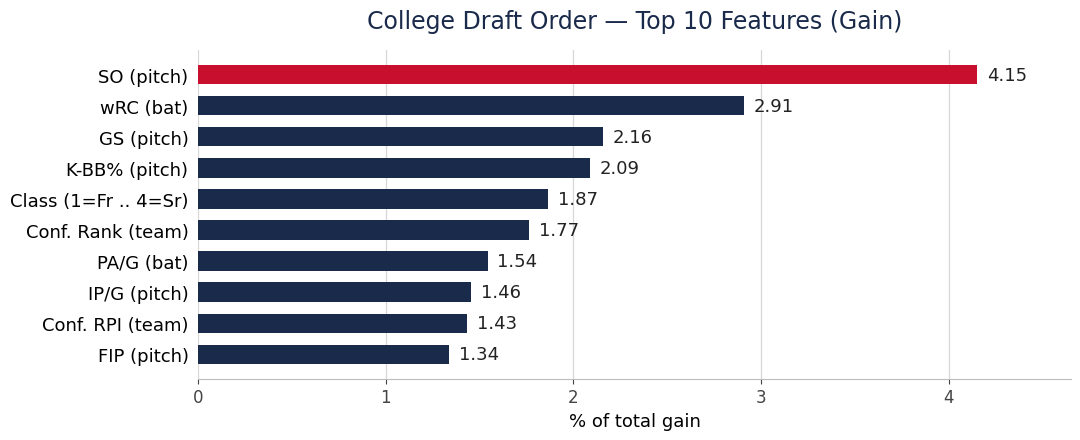

In [39]:
# Stage 2 -- feature importance (Stage 1 had this chart; Stage 2 did not).
plot_feature_importance(model_rank, stage=2, top_n=10,
                        title='College Draft Order — Top 10 Features (Gain)')

/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3837196070.py:194: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, feature_names=[_pretty(c) for c in Xs.columns],


  saved figures_v7_public_nomin/s2_shap_summary.pdf


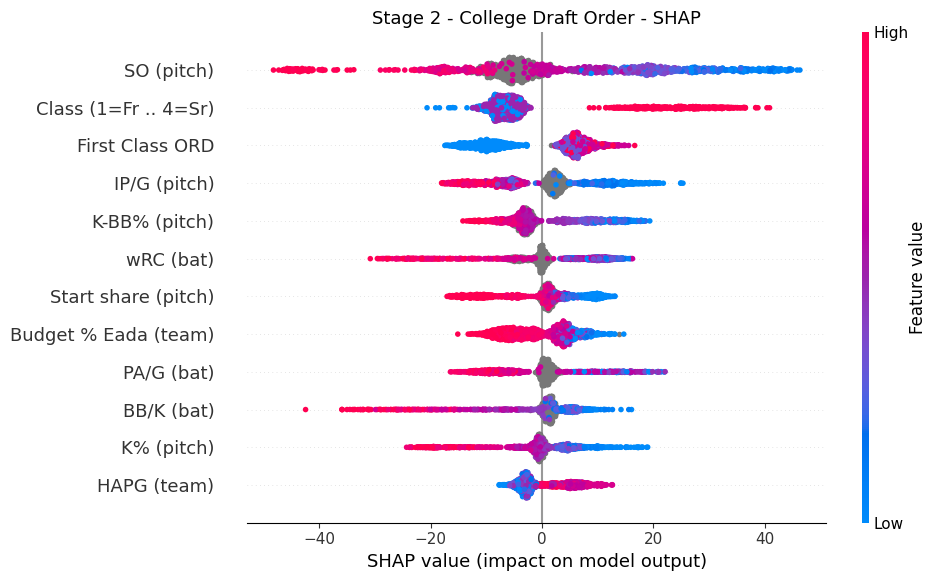

In [40]:
# Stage 2 -- SHAP beeswarm over the rank model's training set.
plot_shap_summary(model_rank, train_df[pick_features], stage=2)

  saved figures_v7_public_nomin/s2_waterfall_top.pdf


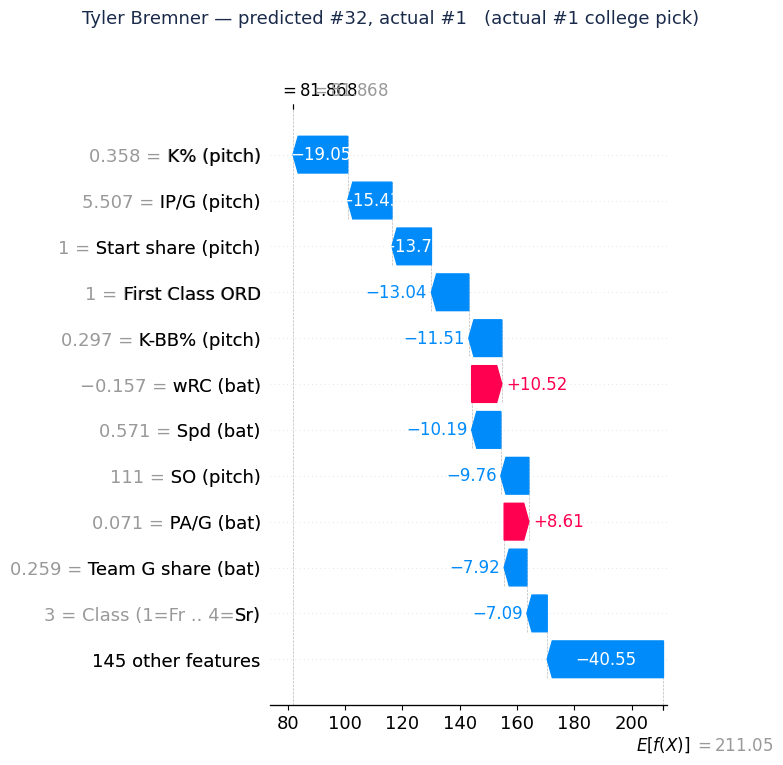

  saved figures_v7_public_nomin/s2_waterfall_miss.pdf


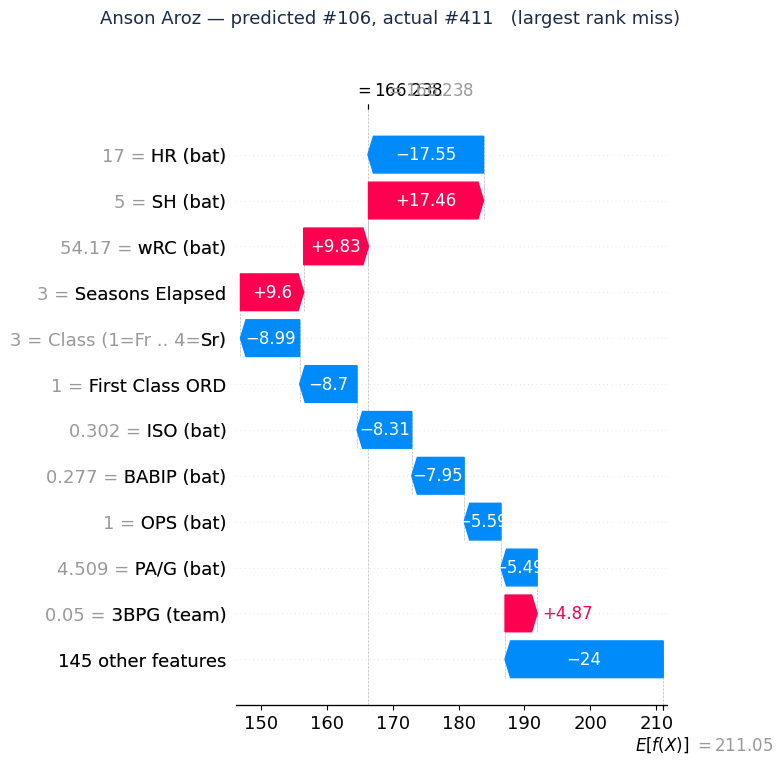

In [41]:
# Stage 2 -- per-player SHAP waterfalls: the test year's actual #1 college pick,
# and the player the model missed by the widest margin.
_names2  = test_df['nameascii'].values
_i_top2  = int(np.argmin(actual_order))
_i_miss2 = int(np.argmax(np.abs(pred_order - actual_order)))

for _i, _slug, _blurb in [(_i_top2,  'waterfall_top',  'actual #1 college pick'),
                          (_i_miss2, 'waterfall_miss', 'largest rank miss')]:
    plot_shap_waterfall(model_rank, X_test, X_test.index[_i], stage=2, name=_slug,
                        title=(f"{_names2[_i]} — predicted #{pred_order[_i]}, "
                               f"actual #{actual_order[_i]}   ({_blurb})"))

  saved figures_v7_public_nomin/s2_era_vs_order.pdf


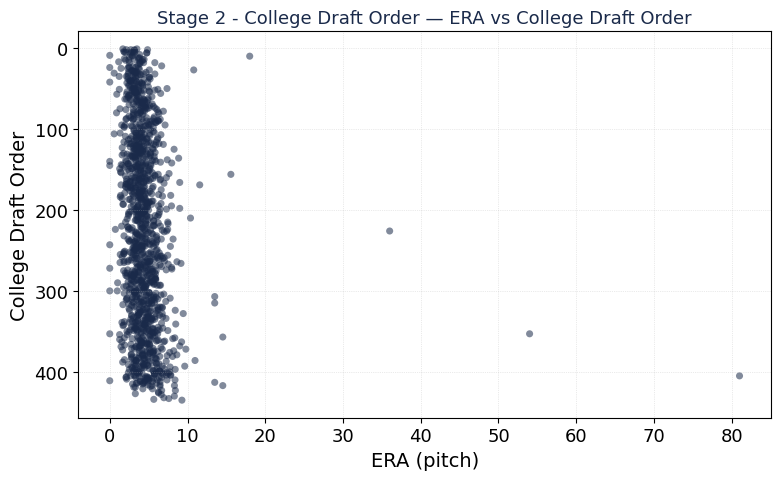

In [42]:
plot_df = draftedClean_df[['era_pitch', 'College_Draft_Order']].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df['era_pitch'], plot_df['College_Draft_Order'],
           alpha=0.55, s=26, color=NAVY, edgecolor='none')
ax.set_xlabel(_pretty('era_pitch'))
ax.set_ylabel('College Draft Order')
ax.invert_yaxis()   # pick 1 at top
ax.set_title(f'{STAGE_TITLE[2]} — ERA vs College Draft Order', fontsize=13, color=NAVY)
ax.grid(ls=':', lw=0.5, alpha=0.5)
plt.tight_layout()
save_fig(fig, 2, 'era_vs_order')
plt.show()

In [43]:
# Parallel coordinates: pitching features by college draft order
pcp_features = ['era_pitch', 'fip_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

plot_pcp(draftedClean_df, pcp_features, 'College_Draft_Order', stage=2, name='pcp', sample=None,
         title='Stage 2 — Pitching Features by College Draft Order')

  saved figures_v7_public_nomin/s2_pcp.pdf


  saved figures_v7_public_nomin/s2_pdp.pdf


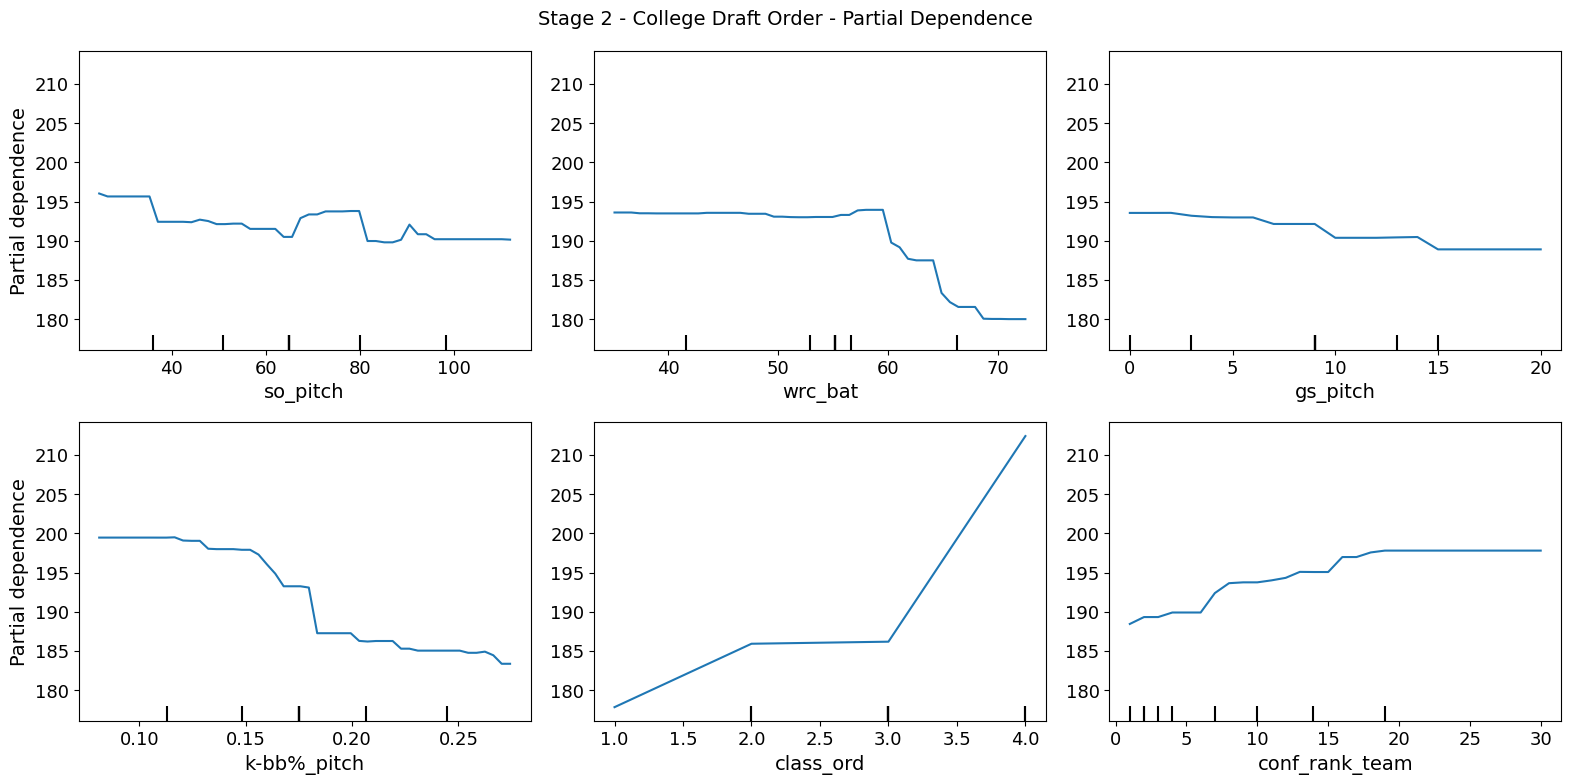

In [44]:
# Partial Dependence Plots - College Draft Order Model
plot_pdp_grid(model_rank, train_df[pick_features], stage=2, top_n=6, skip_binary=False)

  saved figures_v7_public_nomin/s2_pdp_2d.pdf


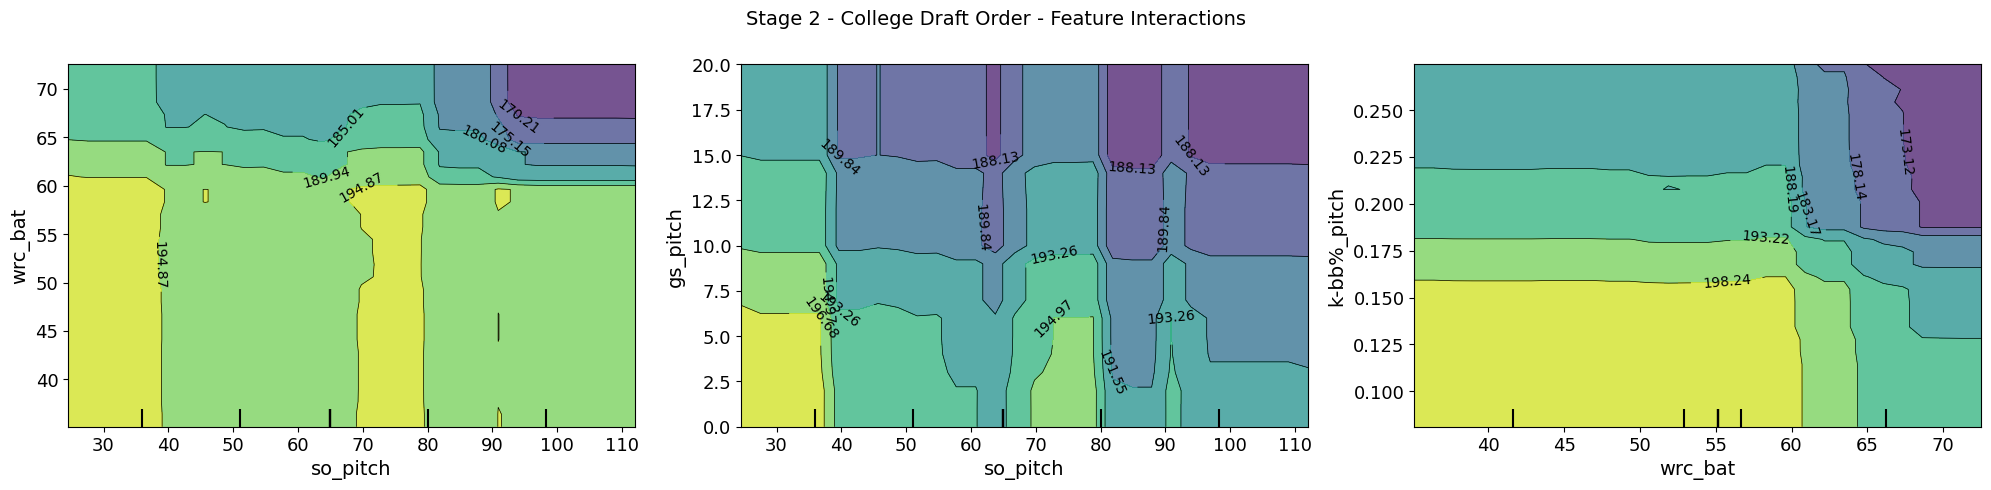

In [45]:
# 2D Interaction PDP - College Draft Order Model
# Same default pairing as before: (top1,top2), (top1,top3), (top2,top4).
plot_pdp_2d(model_rank, train_df[pick_features], stage=2, name='pdp_2d')

In [46]:
# Build results dataframe
results_rank_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_College_Order': pred_order,
    'Actual_College_Order': actual_order,
})

results_rank_df = results_rank_df.sort_values('Actual_College_Order').reset_index(drop=True)

print(f"Player College Draft Order Predictions (Test Year: {test_year})")
print(f"Total college draftees: {len(results_rank_df)}\n")
display(results_rank_df.head(20))

Player College Draft Order Predictions (Test Year: 2025)
Total college draftees: 426



,name,Predicted_College_Order,Actual_College_Order
0,Tyler Bremner,32,1
1,Kade Anderson,1,2
2,Liam Doyle,4,3
3,Aiva Arquette,13,4
4,Jamie Arnold,5,5
5,Gavin Kilen,22,6
6,Kyson Witherspoon,12,7
7,Marek Houston,17,8
8,Ethan Conrad,43,9
9,Ike Irish,6,10


---
## Percent-Based College Draft Order Model

In [47]:
# XGBoost regression to predict College_Draft_Pct (normalized 0-1)
y_train_pct = train_df['College_Draft_Pct']
y_test_pct = test_df['College_Draft_Pct']

model_rank_pct = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
model_rank_pct.fit(X_train, y_train_pct,
                   eval_set=[(X_test, y_test_pct)], verbose=50)

preds_pct = model_rank_pct.predict(X_test)
pred_order_pct = pd.Series(preds_pct).rank(method='min').astype(int).values

corr_pct, p_pct = spearmanr(actual_order, pred_order_pct)
mae_pct = mean_absolute_error(y_test_pct.values, preds_pct)

print(f"\nCollege-Only Rank Model - Percent Target (n={len(y_test_pct)}):")
print(f"  Spearman (rank): {corr_pct:.3f} (p={p_pct:.2e})")
print(f"  MAE (pct):       {mae_pct:.4f}")
print(f"\nComparison:")
print(f"  Raw Order Model Spearman: {corr_order:.3f}")
print(f"  Pct Model Spearman:       {corr_pct:.3f}")

METRICS['s2_pct'] = dict(n=int(len(y_test_pct)), spearman=float(corr_pct), mae=float(mae_pct))

[0]	validation_0-mae:0.24916


[50]	validation_0-mae:0.20432


[100]	validation_0-mae:0.18967


[150]	validation_0-mae:0.18522


[200]	validation_0-mae:0.18304


[250]	validation_0-mae:0.18237


[300]	validation_0-mae:0.18150


[350]	validation_0-mae:0.18133


[378]	validation_0-mae:0.18167



College-Only Rank Model - Percent Target (n=426):
  Spearman (rank): 0.628 (p=4.70e-48)
  MAE (pct):       0.1810

Comparison:
  Raw Order Model Spearman: 0.626
  Pct Model Spearman:       0.628


In [48]:
corr_order_pct, p_value_pct = spearmanr(actual_order, pred_order_pct)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order_pct)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order_pct:.3f} (p={p_value_pct:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Range:    [{ci_high - ci_low:.3f}]")
METRICS['s2_pct'].update(ci_low=float(ci_low), ci_high=float(ci_high))

Spearman: 0.628 (p=4.70e-48)
95% CI:   [0.566, 0.682]
Range:    [0.116]


In [49]:
# Percent model results table
results_pct_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_Pct': preds_pct,
    'Actual_Pct': y_test_pct.values,
    'Predicted_Order_from_Pct': pred_order_pct,
    'Actual_College_Order': actual_order,
})
results_pct_df = results_pct_df.sort_values('Actual_College_Order').reset_index(drop=True)
display(results_pct_df.head(20))

,name,Predicted_Pct,Actual_Pct,Predicted_Order_from_Pct,Actual_College_Order
0,Tyler Bremner,0.171858,0.000000,29,1
1,Kade Anderson,-0.003521,0.002353,1,2
2,Liam Doyle,0.006083,0.004706,3,3
3,Aiva Arquette,0.084890,0.007059,14,4
4,Jamie Arnold,0.025203,0.009412,6,5
5,Gavin Kilen,0.109192,0.011765,17,6
6,Kyson Witherspoon,0.066235,0.014118,11,7
7,Marek Houston,0.117718,0.016471,19,8
8,Ethan Conrad,0.246025,0.018824,52,9
9,Ike Irish,0.022808,0.021176,5,10


  saved figures_v7_public_nomin/s2_rank_scatter_full.pdf


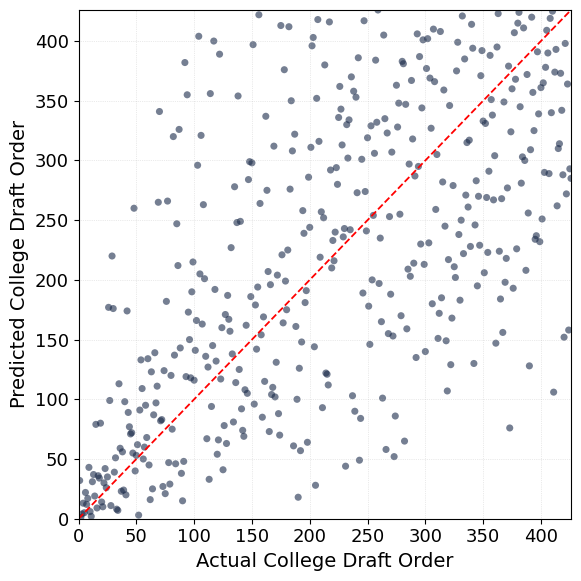

  saved figures_v7_public_nomin/s2_rank_scatter_zoom.pdf


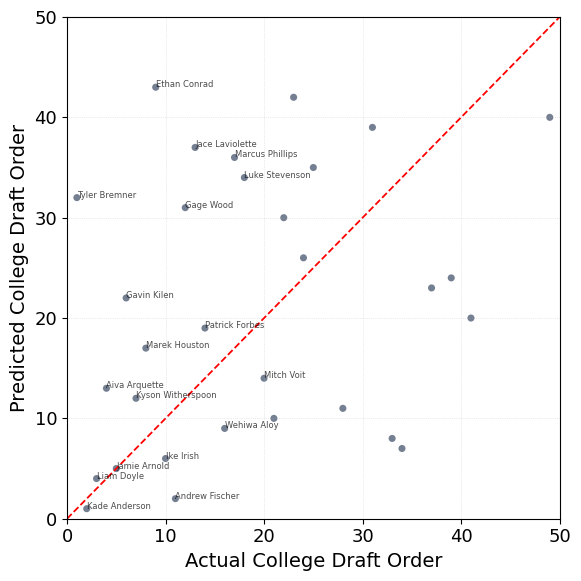

In [50]:
# Stage 2 -- predicted vs actual college draft order: full class, then a top-50 zoom.
# The axis limit is derived from the data (it used to be hardcoded to the 2025 class size).
for _name, _zoom in [('rank_scatter_full', None), ('rank_scatter_zoom', 50)]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(actual_order, pred_order, alpha=0.6, s=26, color=NAVY, edgecolor='none')

    if _zoom is None:
        _hi = float(max(np.max(actual_order), np.max(pred_order)))
    else:
        _hi = float(_zoom)
        for _, row in results_rank_df.head(20).iterrows():
            if row['Actual_College_Order'] <= 20 or row['Predicted_College_Order'] <= 20:
                ax.annotate(row['name'],
                            (row['Actual_College_Order'], row['Predicted_College_Order']),
                            fontsize=6, alpha=0.7)

    ax.plot([0, _hi], [0, _hi], 'r--', lw=1.3, label='Perfect')
    ax.set_xlim(0, _hi); ax.set_ylim(0, _hi)
    ax.set_xlabel('Actual College Draft Order')
    ax.set_ylabel('Predicted College Draft Order')
    ax.grid(True, which='major', ls=':', linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    save_fig(fig, 2, _name, dpi=300)
    plt.show()

  saved figures_v7_public_nomin/s2_residuals.pdf


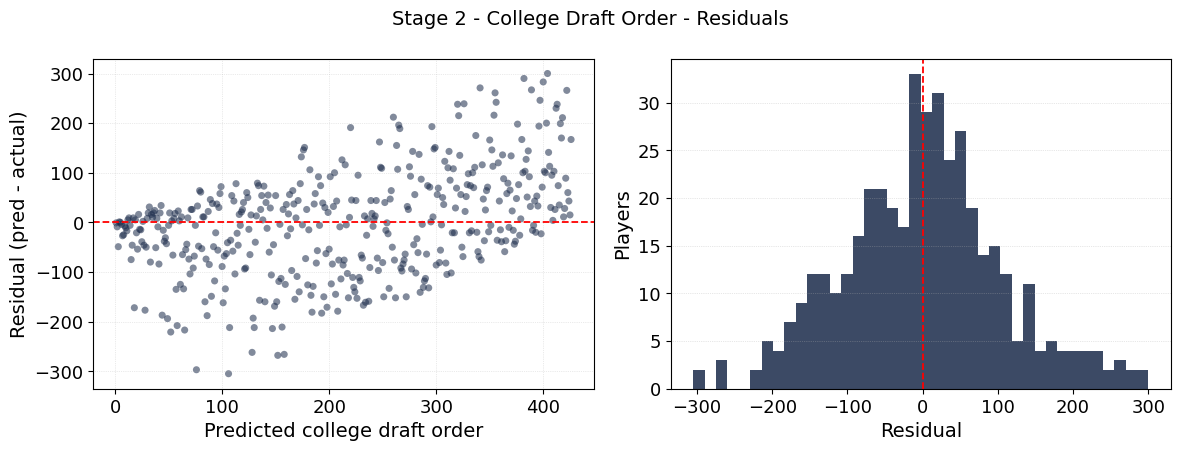

In [51]:
# Stage 2 -- residuals (Stage 2 had no residual plot before).
plot_residuals(actual_order, pred_order, stage=2,
               xlabel='Predicted college draft order')

In [52]:
prospects = pd.read_csv(f'{PROSPECTS_DIR}/mlb_{int(test_year)}_draft_prospects_top250.csv')

# Compare with MLB Pipeline on matched players
results_rank_df['name_clean'] = results_rank_df['name'].str.strip().str.lower()
prospects['name_clean'] = prospects['name'].str.strip().str.lower()

comp = results_rank_df.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')

# Re-rank everything among only matched players
comp = comp.sort_values('Actual_College_Order').reset_index(drop=True)
comp['Actual_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('Predicted_College_Order').reset_index(drop=True)
comp['Pred_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('rank').reset_index(drop=True)
comp['Pipeline_Order_Matched'] = range(1, len(comp) + 1)

corr_you, p_you = spearmanr(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
corr_pipe, p_pipe = spearmanr(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])
mae_you = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
mae_pipe = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])

print(f"Head-to-Head on Matched College Players (n={len(comp)})")
print(f"{'Comparison':<45} {'Spearman':>10}    {'P-Value':>8}  {'MAE':>10}")
print("-" * 80)
print(f"{'Your Rank Model vs Actual':<45} {corr_you:>10.3f}    {p_you:.2e} {mae_you:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<45} {corr_pipe:>10.3f}    {p_pipe:.2e} {mae_pipe:>10.1f}")

comp = comp[['name', 'Pipeline_Order_Matched', 'Predicted_College_Order', 'Actual_College_Order']].copy()
comp.columns = ['name', 'MLB_Pipeline_College_Order', 'Predicted_College_Order', 'Actual_College_Order']
display(comp.sort_values('Actual_College_Order').reset_index(drop=True).head(25))

METRICS['s2_h2h_testyear'] = dict(
    n=int(len(comp)),
    spearman_model=float(corr_you), spearman_pipeline=float(corr_pipe),
    mae_model=float(mae_you), mae_pipeline=float(mae_pipe),
)

Head-to-Head on Matched College Players (n=124)
Comparison                                      Spearman     P-Value         MAE
--------------------------------------------------------------------------------
Your Rank Model vs Actual                          0.597    2.58e-13       24.6
MLB Pipeline vs Actual                             0.838    6.83e-34       14.6


,name,MLB_Pipeline_College_Order,Predicted_College_Order,Actual_College_Order
0,Tyler Bremner,10,32,1
1,Kade Anderson,1,1,2
2,Liam Doyle,4,4,3
3,Aiva Arquette,3,13,4
4,Jamie Arnold,2,5,5
5,Gavin Kilen,12,22,6
6,Kyson Witherspoon,5,12,7
7,Marek Houston,7,17,8
8,Ethan Conrad,14,43,9
9,Ike Irish,6,6,10


## V6 — Multi-Year MLB Pipeline Benchmark

The cells below extend the cell-35 single-year comparison to every year of MLB Pipeline top-250 prospect rankings on disk. They:

1. Load `mlb_<year>_draft_prospects_top250.csv` from `mlb_draft_prospects/`, for every drafted year that has a file.
2. Generate out-of-fold per-year predictions from the rank model (each year predicted by a model that did NOT see it during training).
3. Run a per-year head-to-head: **Your Model** vs **MLB Pipeline** vs **Actual draft order**.
4. Run a developmental-success benchmark on 2021–2023 cohorts using `current_level` (post-draft ground truth).

`current_level` is used **only** for the eval in cell *develop-eval*. It is never merged into the training features.

In [53]:
# Load every MLB Pipeline top-250 prospect CSV that exists for a drafted year.
# Derived rather than hardcoded so a capped MAX_YEAR does not try to load a
# year that is not in the data.
PROSPECT_YEARS = [int(y) for y in sorted(draftedClean_df[year_col].unique())
                  if os.path.exists(f'{PROSPECTS_DIR}/mlb_{int(y)}_draft_prospects_top250.csv')]

prospects_by_year = {}
for y in PROSPECT_YEARS:
    p = pd.read_csv(f'{PROSPECTS_DIR}/mlb_{y}_draft_prospects_top250.csv')
    p['name_clean'] = p['name'].astype(str).str.strip().str.lower()
    p['year'] = y
    prospects_by_year[y] = p

all_prospects = pd.concat(prospects_by_year.values(), ignore_index=True)
print(f"Loaded prospects for years: {sorted(prospects_by_year.keys())}")
print(f"Total prospect rows: {len(all_prospects)}")
print(f"\ncurrent_level distribution (all years pooled):")
print(all_prospects['current_level'].fillna('BLANK').value_counts().to_string())

Loaded prospects for years: [2021, 2022, 2023, 2024, 2025]
Total prospect rows: 1250

current_level distribution (all years pooled):
current_level
A+       265
AA       221
BLANK    213
A        181
AAA      174
MLB      115
ROK       81


In [54]:
# Out-of-fold per-year rank-model predictions for 2021-2025.
# For each year y, train on (years != y) and predict on year y.
# Result: every year has predictions from a model that did NOT see that year during training.
years_all = sorted(draftedClean_df[year_col].unique())
print(f"Running leave-one-year-out CV across: {years_all}")

oof_frames = []
for y in years_all:
    train_slice = draftedClean_df[draftedClean_df[year_col] != y]
    test_slice  = draftedClean_df[draftedClean_df[year_col] == y]

    if len(test_slice) == 0:
        continue

    X_tr = train_slice[pick_features]
    y_tr = train_slice['College_Draft_Order']
    X_te = test_slice[pick_features]
    y_te = test_slice['College_Draft_Order']

    m = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
        colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
        random_state=42, early_stopping_rounds=50, eval_metric='mae'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    preds = m.predict(X_te)
    pred_order = pd.Series(preds).rank(method='min').astype(int).values

    oof_frames.append(pd.DataFrame({
        'name': test_slice['nameascii'].values,
        'year': y,
        'Predicted_College_Order': pred_order,
        'Actual_College_Order': y_te.values,
    }))

oof_results_rank_df = pd.concat(oof_frames, ignore_index=True)
oof_results_rank_df['name_clean'] = oof_results_rank_df['name'].astype(str).str.strip().str.lower()

print(f"\nOOF predictions: {len(oof_results_rank_df)} players across {oof_results_rank_df['year'].nunique()} years")
print(oof_results_rank_df.groupby('year').size().to_string())

Running leave-one-year-out CV across: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]



OOF predictions: 2109 players across 5 years
year
2021    411
2022    417
2023    420
2024    435
2025    426


In [55]:
# Per-year head-to-head: Your Model vs MLB Pipeline vs Actual draft order.
# Restricted to matched players (in both the year's draftees and the top-250 list).
per_year_rows = []
all_matched = []

for y in PROSPECT_YEARS:
    yr_oof = oof_results_rank_df[oof_results_rank_df['year'] == y]
    yr_prosp = prospects_by_year[y]
    merged = yr_oof.merge(yr_prosp[['name_clean', 'rank']], on='name_clean', how='inner')

    if len(merged) < 5:
        per_year_rows.append({'year': y, 'n_matched': len(merged),
                              'spearman_model': np.nan, 'spearman_pipeline': np.nan,
                              'mae_model': np.nan, 'mae_pipeline': np.nan})
        continue

    merged = merged.sort_values('Actual_College_Order').reset_index(drop=True)
    merged['actual_order_m'] = range(1, len(merged) + 1)
    merged = merged.sort_values('Predicted_College_Order').reset_index(drop=True)
    merged['pred_order_m'] = range(1, len(merged) + 1)
    merged = merged.sort_values('rank').reset_index(drop=True)
    merged['pipeline_order_m'] = range(1, len(merged) + 1)

    sp_m, _ = spearmanr(merged['actual_order_m'], merged['pred_order_m'])
    sp_p, _ = spearmanr(merged['actual_order_m'], merged['pipeline_order_m'])
    mae_m = mean_absolute_error(merged['actual_order_m'], merged['pred_order_m'])
    mae_p = mean_absolute_error(merged['actual_order_m'], merged['pipeline_order_m'])

    per_year_rows.append({'year': y, 'n_matched': len(merged),
                          'spearman_model': sp_m, 'spearman_pipeline': sp_p,
                          'mae_model': mae_m, 'mae_pipeline': mae_p})
    merged['year'] = y
    all_matched.append(merged)

per_year_h2h_df = pd.DataFrame(per_year_rows)
matched_pool = pd.concat(all_matched, ignore_index=True) if all_matched else pd.DataFrame()

print("=== Per-year head-to-head: stats-only XGBoost vs MLB Pipeline (vs actual draft order) ===\n")
display(per_year_h2h_df.round(3))

if len(matched_pool) > 0:
    n_total = len(matched_pool)
    sp_m_avg = per_year_h2h_df['spearman_model'].mean()
    sp_p_avg = per_year_h2h_df['spearman_pipeline'].mean()
    mae_m_avg = per_year_h2h_df['mae_model'].mean()
    mae_p_avg = per_year_h2h_df['mae_pipeline'].mean()
    print(f"\nMean-across-years (n_total_matched = {n_total}):")
    print(f"  Your Model    Spearman = {sp_m_avg:.3f} | MAE = {mae_m_avg:.1f}")
    print(f"  MLB Pipeline  Spearman = {sp_p_avg:.3f} | MAE = {mae_p_avg:.1f}")

METRICS['s2_oof'] = dict(
    years=[int(v) for v in per_year_h2h_df['year']],
    n_matched=int(per_year_h2h_df['n_matched'].sum()),
    spearman_model_mean=float(per_year_h2h_df['spearman_model'].mean()),
    spearman_pipeline_mean=float(per_year_h2h_df['spearman_pipeline'].mean()),
    mae_model_mean=float(per_year_h2h_df['mae_model'].mean()),
    mae_pipeline_mean=float(per_year_h2h_df['mae_pipeline'].mean()),
)

=== Per-year head-to-head: stats-only XGBoost vs MLB Pipeline (vs actual draft order) ===



,year,n_matched,spearman_model,spearman_pipeline,mae_model,mae_pipeline
0,2021,115,0.374,0.817,29.670,15.200
1,2022,121,0.553,0.857,25.091,13.967
2,2023,132,0.636,0.762,25.000,19.015
3,2024,116,0.684,0.832,20.379,14.448
4,2025,124,0.597,0.838,24.597,14.597



Mean-across-years (n_total_matched = 608):
  Your Model    Spearman = 0.569 | MAE = 24.9
  MLB Pipeline  Spearman = 0.821 | MAE = 15.4


In [56]:
# Developmental-success benchmark (cell: develop-eval).
# Uses post-draft `current_level` as ground truth -- which players actually advanced?
# IMPORTANT: current_level is NEVER used as a training feature; this is evaluation only.
# Restricted to 2021-2023 cohorts (4+ years of development time has elapsed).

LEVEL_ORD = {'ROK': 1, 'A': 2, 'A+': 3, 'AA': 4, 'AAA': 5, 'MLB': 6}

def lvl(x):
    if pd.isna(x):
        return 0
    s = str(x).strip().upper()
    if s in ('', 'NONE', 'NAN'):
        return 0
    return LEVEL_ORD.get(s, 0)

DEV_YEARS = [2021, 2022, 2023]
TOPK = 50
TARGET_LEVEL = LEVEL_ORD['AA']  # "reached AA+"

dev_rows = []
for y in DEV_YEARS:
    yr_oof = oof_results_rank_df[oof_results_rank_df['year'] == y].copy()
    yr_prosp = prospects_by_year[y].copy()
    yr_prosp['level_ord'] = yr_prosp['current_level'].apply(lvl)
    merged = yr_oof.merge(yr_prosp[['name_clean', 'rank', 'level_ord']], on='name_clean', how='inner')

    if len(merged) < TOPK:
        continue

    # Spearman: lower-is-better rankers vs higher-is-better level -> expect NEGATIVE.
    # We negate so "concordance" is positive when the ranker put successful pros at the top.
    sp_model,  _ = spearmanr(merged['Predicted_College_Order'], merged['level_ord'])
    sp_pipe,   _ = spearmanr(merged['rank'],                    merged['level_ord'])
    sp_actual, _ = spearmanr(merged['Actual_College_Order'],    merged['level_ord'])

    def pct_topk(df, ranker_col, k=TOPK, target=TARGET_LEVEL):
        sub = df.sort_values(ranker_col).head(k)
        return 100.0 * (sub['level_ord'] >= target).sum() / len(sub)

    dev_rows.append({
        'year': y,
        'n_matched': len(merged),
        'concord_model_vs_level':    -sp_model,
        'concord_pipeline_vs_level': -sp_pipe,
        'concord_actual_vs_level':   -sp_actual,
        f'pct_AAplus_top{TOPK}_model':    pct_topk(merged, 'Predicted_College_Order'),
        f'pct_AAplus_top{TOPK}_pipeline': pct_topk(merged, 'rank'),
        f'pct_AAplus_top{TOPK}_actual':   pct_topk(merged, 'Actual_College_Order'),
    })

dev_df = pd.DataFrame(dev_rows)
print("=== Developmental-success benchmark (2021-2023 cohorts) ===")
print("Concordance = -Spearman(ranking, level_reached). Higher = ranker put eventual pros at the top.")
print(f"pct_AAplus_top{TOPK} = of the ranker's top {TOPK} players, what % reached AA or higher.\n")
display(dev_df.round(3))

=== Developmental-success benchmark (2021-2023 cohorts) ===
Concordance = -Spearman(ranking, level_reached). Higher = ranker put eventual pros at the top.
pct_AAplus_top50 = of the ranker's top 50 players, what % reached AA or higher.



,year,n_matched,concord_model_vs_level,concord_pipeline_vs_level,concord_actual_vs_level,pct_AAplus_top50_model,pct_AAplus_top50_pipeline,pct_AAplus_top50_actual
0,2021,115,-0.030,0.448,0.409,88.0,92.0,90.0
1,2022,121,0.297,0.307,0.403,94.0,92.0,90.0
2,2023,132,0.347,0.505,0.472,80.0,82.0,82.0


In [57]:
# V6 summary -- single table for the paper.

print("=" * 78)
print("V6 SUMMARY -- Multi-Year MLB Pipeline Benchmark (stats-only XGBoost)")
print("=" * 78)

print("\n--- Draft-order agreement (Spearman with actual college draft order) ---")
order_summary = per_year_h2h_df[['year', 'n_matched', 'spearman_model', 'spearman_pipeline']].copy()
order_summary.columns = ['year', 'n', 'XGBoost (stats only)', 'MLB Pipeline']
mean_row = pd.DataFrame([{
    'year': 'mean',
    'n': order_summary['n'].sum(),
    'XGBoost (stats only)': order_summary['XGBoost (stats only)'].mean(),
    'MLB Pipeline': order_summary['MLB Pipeline'].mean(),
}])
order_summary = pd.concat([order_summary, mean_row], ignore_index=True)
display(order_summary.round(3))

if len(dev_df) > 0:
    print("\n--- Developmental success (concordance with post-draft level, 2021-2023) ---")
    dev_summary = dev_df[['year', 'n_matched', 'concord_model_vs_level', 'concord_pipeline_vs_level', 'concord_actual_vs_level']].copy()
    dev_summary.columns = ['year', 'n', 'XGBoost', 'MLB Pipeline', 'Actual draft']
    mean_row = pd.DataFrame([{
        'year': 'mean',
        'n': dev_summary['n'].sum(),
        'XGBoost': dev_summary['XGBoost'].mean(),
        'MLB Pipeline': dev_summary['MLB Pipeline'].mean(),
        'Actual draft': dev_summary['Actual draft'].mean(),
    }])
    dev_summary = pd.concat([dev_summary, mean_row], ignore_index=True)
    display(dev_summary.round(3))

    print(f"\n--- % of top-50 that reached AA+ (2021-2023) ---")
    topk_summary = dev_df[['year', 'pct_AAplus_top50_model', 'pct_AAplus_top50_pipeline', 'pct_AAplus_top50_actual']].copy()
    topk_summary.columns = ['year', 'XGBoost', 'MLB Pipeline', 'Actual draft']
    mean_row = pd.DataFrame([{
        'year': 'mean',
        'XGBoost': topk_summary['XGBoost'].mean(),
        'MLB Pipeline': topk_summary['MLB Pipeline'].mean(),
        'Actual draft': topk_summary['Actual draft'].mean(),
    }])
    topk_summary = pd.concat([topk_summary, mean_row], ignore_index=True)
    display(topk_summary.round(1))

V6 SUMMARY -- Multi-Year MLB Pipeline Benchmark (stats-only XGBoost)

--- Draft-order agreement (Spearman with actual college draft order) ---


,year,n,XGBoost (stats only),MLB Pipeline
0,2021,115,0.374,0.817
1,2022,121,0.553,0.857
2,2023,132,0.636,0.762
3,2024,116,0.684,0.832
4,2025,124,0.597,0.838
5,mean,608,0.569,0.821



--- Developmental success (concordance with post-draft level, 2021-2023) ---


,year,n,XGBoost,MLB Pipeline,Actual draft
0,2021,115,-0.030,0.448,0.409
1,2022,121,0.297,0.307,0.403
2,2023,132,0.347,0.505,0.472
3,mean,368,0.204,0.420,0.428



--- % of top-50 that reached AA+ (2021-2023) ---


,year,XGBoost,MLB Pipeline,Actual draft
0,2021,88.0,92.0,90.0
1,2022,94.0,92.0,90.0
2,2023,80.0,82.0,82.0
3,mean,87.3,88.7,87.3


In [58]:
# Show top features with missing values
missing_summary = X.isnull().mean().sort_values(ascending=False)
print(missing_summary[missing_summary > 0].head(15))

TP_team            0.979404
gdp_bat            0.575557
ip_share_pitch     0.505114
k/bb_pitch         0.502420
hr/9_pitch         0.493135
e-f_pitch          0.493135
bb/9_pitch         0.493135
whip_pitch         0.493135
fip_pitch          0.493135
k/9_pitch          0.493135
era_pitch          0.493135
so_per_ip_pitch    0.493135
babip_pitch        0.492564
ip_per_g_pitch     0.491305
ip_pitch           0.491305
dtype: float64


---
## Signing Bonus Prediction

Predict signing bonus using the same features as the rank model.

**Excluded** to avoid data leakage: `api_pickValue`, `Pick`, `Round`, `College_Draft_Order`

In [59]:
# Signing bonus model

bonus_df = draftedClean_df[draftedClean_df['api_signingBonus'].notna()].copy()
bonus_df['log_signingBonus'] = np.log1p(bonus_df['api_signingBonus'] * 1e6)

print(f"Players with signing bonus data: {len(bonus_df)} / {len(draftedClean_df)} ({len(bonus_df)/len(draftedClean_df)*100:.1f}%)")
print(f"Signing bonus range: ${bonus_df['api_signingBonus'].min()*1e6:,.0f} - ${bonus_df['api_signingBonus'].max()*1e6:,.0f}")
print(f"Median: ${bonus_df['api_signingBonus'].median()*1e6:,.0f}")

bonus_features = [f for f in pick_features if f not in ['api_pickValue']]

bonus_train = bonus_df[bonus_df[year_col] < test_year]
bonus_test = bonus_df[bonus_df[year_col] == test_year]

print(f"\nTrain: {len(bonus_train)} players (years < {test_year})")
print(f"Test:  {len(bonus_test)} players (year = {test_year})")

bonus_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
bonus_model.fit(bonus_train[bonus_features], bonus_train['log_signingBonus'],
                eval_set=[(bonus_test[bonus_features], bonus_test['log_signingBonus'])], verbose=50)

bonus_preds_log = bonus_model.predict(bonus_test[bonus_features])
bonus_preds_dollars = np.expm1(bonus_preds_log)
bonus_actual_dollars = np.expm1(bonus_test['log_signingBonus'].values)

mae_bonus = mean_absolute_error(bonus_actual_dollars, bonus_preds_dollars)
r2_bonus = r2_score(bonus_actual_dollars, bonus_preds_dollars)
corr_bonus, p_bonus = spearmanr(bonus_actual_dollars, bonus_preds_dollars)

print(f"\nSigning Bonus Model Results (Test Year: {test_year}, n={len(bonus_test)}):")
print(f"  MAE:      ${mae_bonus:,.0f}")
print(f"  R2:       {r2_bonus:.3f}")
print(f"  Spearman: {corr_bonus:.3f} (p={p_bonus:.2e})")

METRICS['s3_bonus'] = dict(
    test_year=int(test_year), n_train=int(len(bonus_train)), n_test=int(len(bonus_test)),
    mae=float(mae_bonus), r2=float(r2_bonus), spearman=float(corr_bonus),
)

Players with signing bonus data: 2051 / 2109 (97.2%)
Signing bonus range: $500 - $9,250,000
Median: $150,000

Train: 1629 players (years < 2025)
Test:  422 players (year = 2025)
[0]	validation_0-mae:0.90176


[50]	validation_0-mae:0.72767


[100]	validation_0-mae:0.70178


[150]	validation_0-mae:0.69387


[191]	validation_0-mae:0.69616



Signing Bonus Model Results (Test Year: 2025, n=422):
  MAE:      $316,894
  R2:       0.347
  Spearman: 0.721 (p=5.69e-69)


In [60]:
bonus_results_df = pd.DataFrame({
    'name': bonus_test['nameascii'].values,
    'Predicted_Bonus': bonus_preds_dollars,
    'Actual_Bonus': bonus_actual_dollars,
    'Actual_Pick': bonus_test['Pick'].values,
})
bonus_results_df['Error'] = bonus_results_df['Predicted_Bonus'] - bonus_results_df['Actual_Bonus']
bonus_results_df = bonus_results_df.sort_values('Actual_Pick').reset_index(drop=True)

disp = bonus_results_df.head(25).copy()
disp['Predicted_Bonus'] = disp['Predicted_Bonus'].apply(lambda x: f"${x:,.0f}")
disp['Actual_Bonus'] = disp['Actual_Bonus'].apply(lambda x: f"${x:,.0f}")
disp['Error'] = disp['Error'].apply(lambda x: f"${x:+,.0f}")
print("Top 25 Signing Bonus Predictions (by draft pick):")
display(disp)

Top 25 Signing Bonus Predictions (by draft pick):


,name,Predicted_Bonus,Actual_Bonus,Actual_Pick,Error
0,Tyler Bremner,"$649,892","$7,689,525",2.0,"$-7,039,633"
1,Kade Anderson,"$2,406,055","$8,800,000",3.0,"$-6,393,945"
2,Liam Doyle,"$2,854,247","$7,250,000",5.0,"$-4,395,753"
3,Aiva Arquette,"$2,168,606","$7,149,900",7.0,"$-4,981,294"
4,Jamie Arnold,"$1,142,660","$5,985,100",11.0,"$-4,842,440"
5,Gavin Kilen,"$1,091,991","$5,247,500",13.0,"$-4,155,509"
6,Kyson Witherspoon,"$1,266,418","$5,000,000",15.0,"$-3,733,582"
7,Marek Houston,"$946,404","$4,497,500",16.0,"$-3,551,096"
8,Ethan Conrad,"$659,160","$3,563,100",17.0,"$-2,903,940"
9,Ike Irish,"$1,883,401","$4,418,400",19.0,"$-2,534,999"


In [61]:
# Show top features by importance from the trained classifier
importance = bonus_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                          Feature  Importance
0      #1                        class_ord   88.428886
1      #2                          wrc_bat   39.390678
2      #3                         wraa_bat   31.088758
3      #4             log_budget_eada_team   28.127201
4      #5                  first_class_ord   27.411560
5      #6                         so_pitch   25.325039
6      #7                           pa_bat   24.403728
7      #8                          ops_bat   18.293211
8      #9                  seasons_elapsed   17.220823
9     #10                         woba_bat   17.153635
10    #11  log_budget_per_player_eada_team   17.136621
11    #12                    conf_rpi_team   15.848030
12    #13                           bb_bat   14.817599
13    #14                           hr_bat   13.812858
14    #15            conf_national_wp_team   13.567278
15    #16                      k-bb%_pitch   11.553826
16    #17                   conf_ran

  saved figures_v7_public_nomin/s3_feature_importance_bonus.pdf


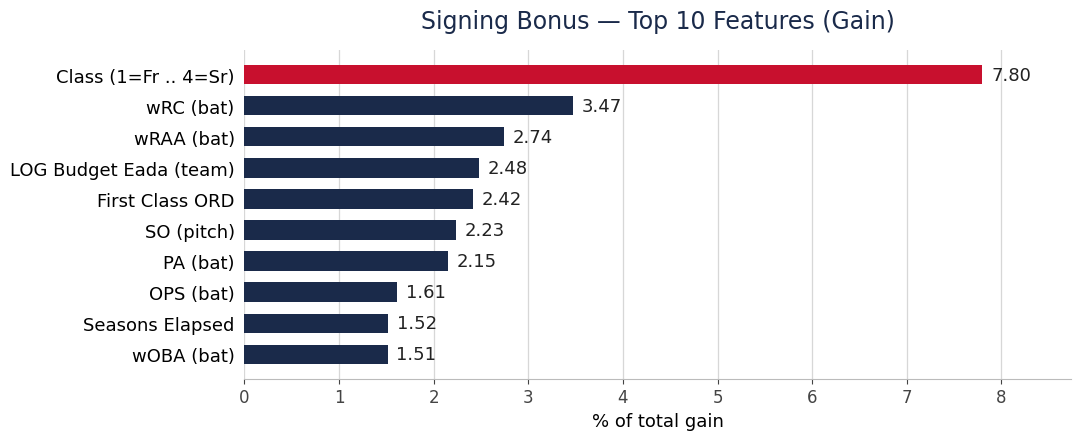

In [62]:
# Stage 3 (bonus) -- feature importance.
plot_feature_importance(bonus_model, stage=3, top_n=10, name='feature_importance_bonus',
                        title='Signing Bonus — Top 10 Features (Gain)')

/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3837196070.py:194: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, feature_names=[_pretty(c) for c in Xs.columns],


  saved figures_v7_public_nomin/s3_shap_summary_bonus.pdf


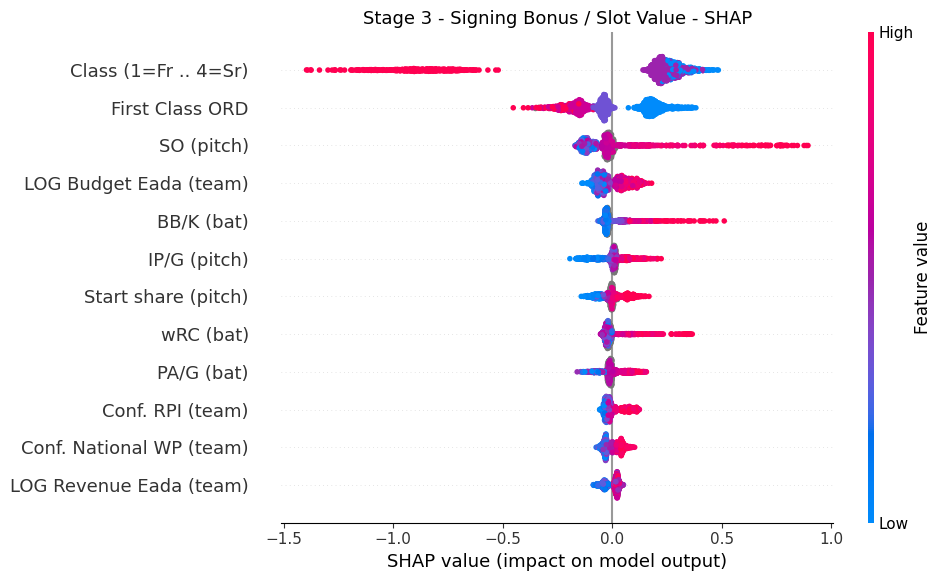

In [63]:
# Stage 3 (bonus) -- SHAP beeswarm.
plot_shap_summary(bonus_model, bonus_train[bonus_features], stage=3,
                  name='shap_summary_bonus')

  saved figures_v7_public_nomin/s3_waterfall_bonus_top.pdf


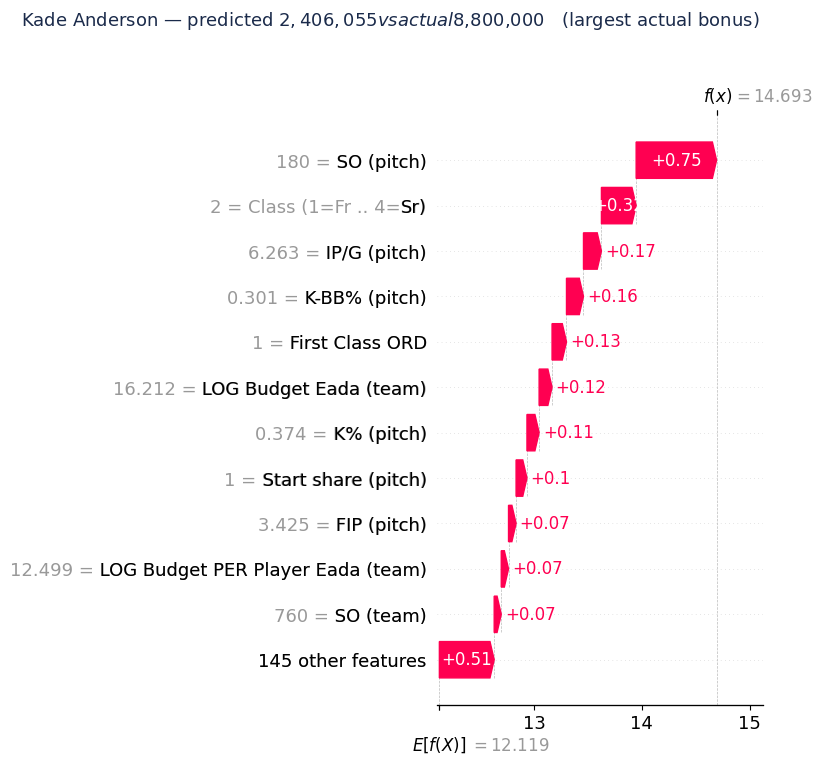

  saved figures_v7_public_nomin/s3_waterfall_bonus_miss.pdf


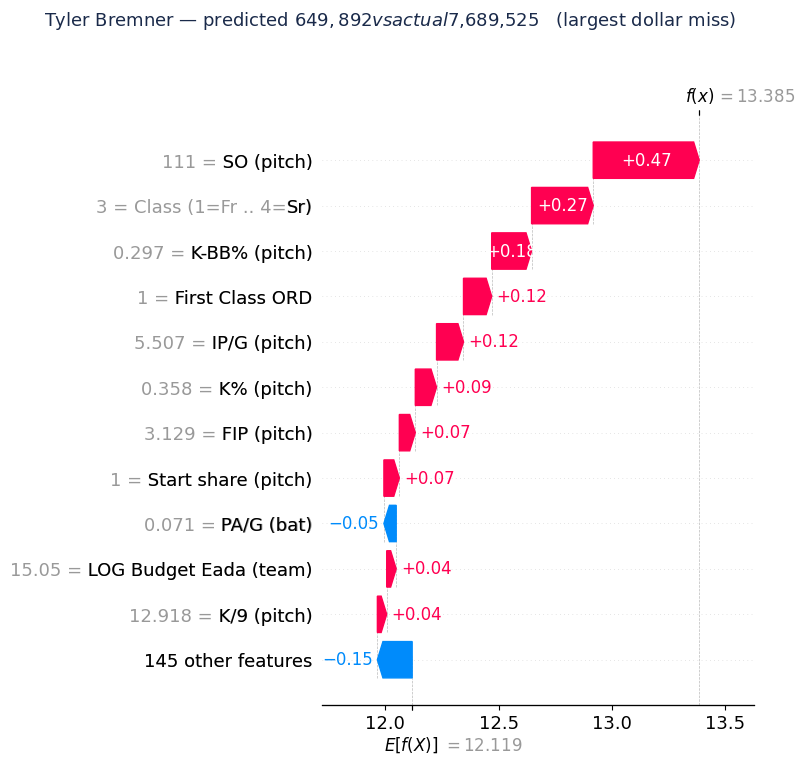

In [64]:
# Stage 3 (bonus) -- per-player SHAP waterfalls: the biggest bonus in the test
# year, and the largest dollar miss.
_nb = bonus_test['nameascii'].values
_Xb = bonus_test[bonus_features]
_i_topb  = int(np.argmax(bonus_actual_dollars))
_i_missb = int(np.argmax(np.abs(bonus_preds_dollars - bonus_actual_dollars)))

for _i, _slug, _blurb in [(_i_topb,  'waterfall_bonus_top',  'largest actual bonus'),
                          (_i_missb, 'waterfall_bonus_miss', 'largest dollar miss')]:
    plot_shap_waterfall(bonus_model, _Xb, _Xb.index[_i], stage=3, name=_slug,
                        title=(f"{_nb[_i]} — predicted ${bonus_preds_dollars[_i]:,.0f} vs "
                               f"actual ${bonus_actual_dollars[_i]:,.0f}   ({_blurb})"))

  saved figures_v7_public_nomin/s3_pdp_bonus.pdf


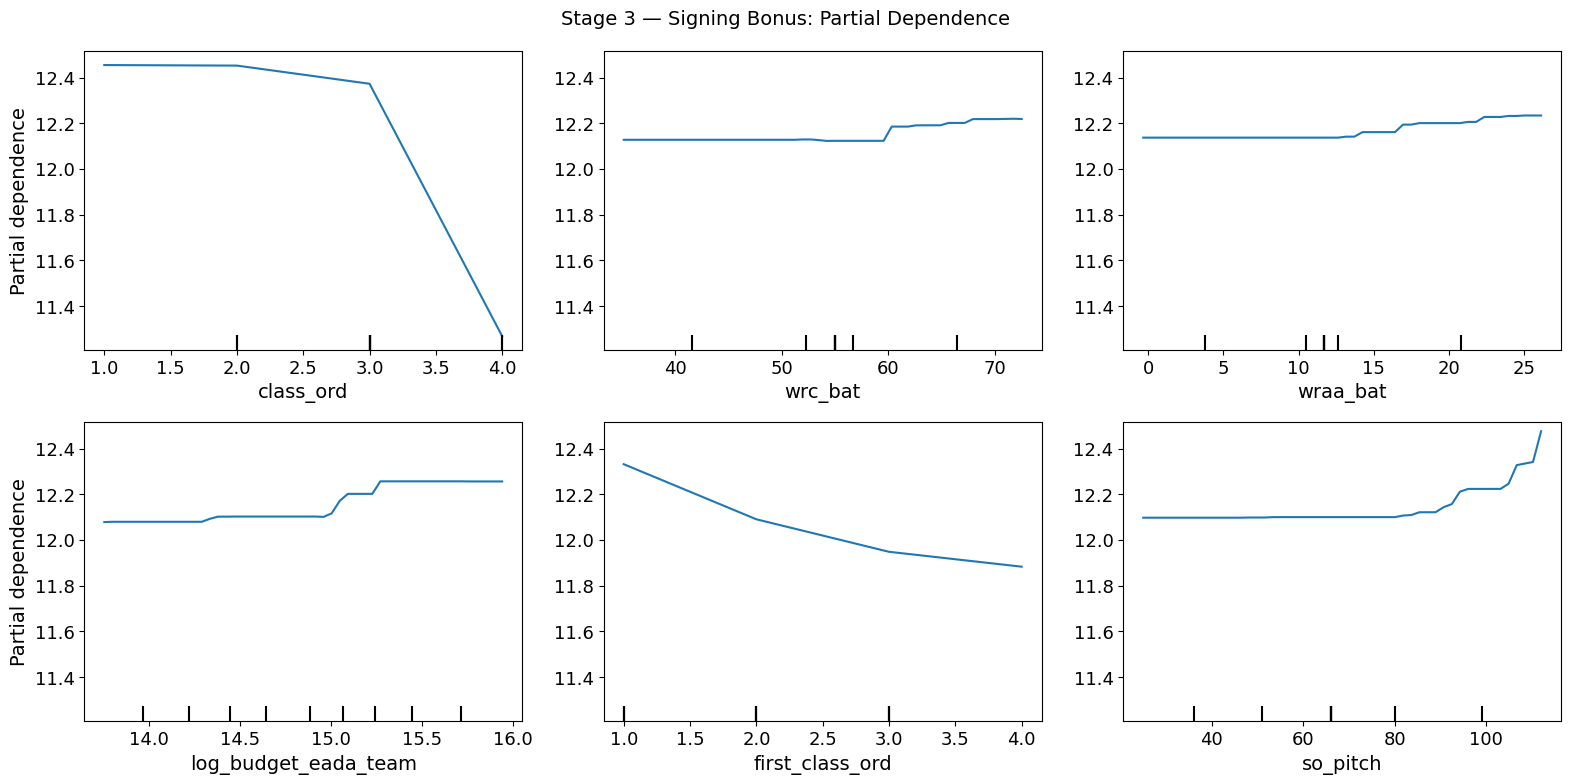

In [65]:
# Partial Dependence Plots - Signing Bonus Model
plot_pdp_grid(bonus_model, bonus_train[bonus_features], stage=3, top_n=6,
              skip_binary=False, name='pdp_bonus',
              title='Stage 3 — Signing Bonus: Partial Dependence')

  saved figures_v7_public_nomin/s3_pdp_2d_bonus.pdf


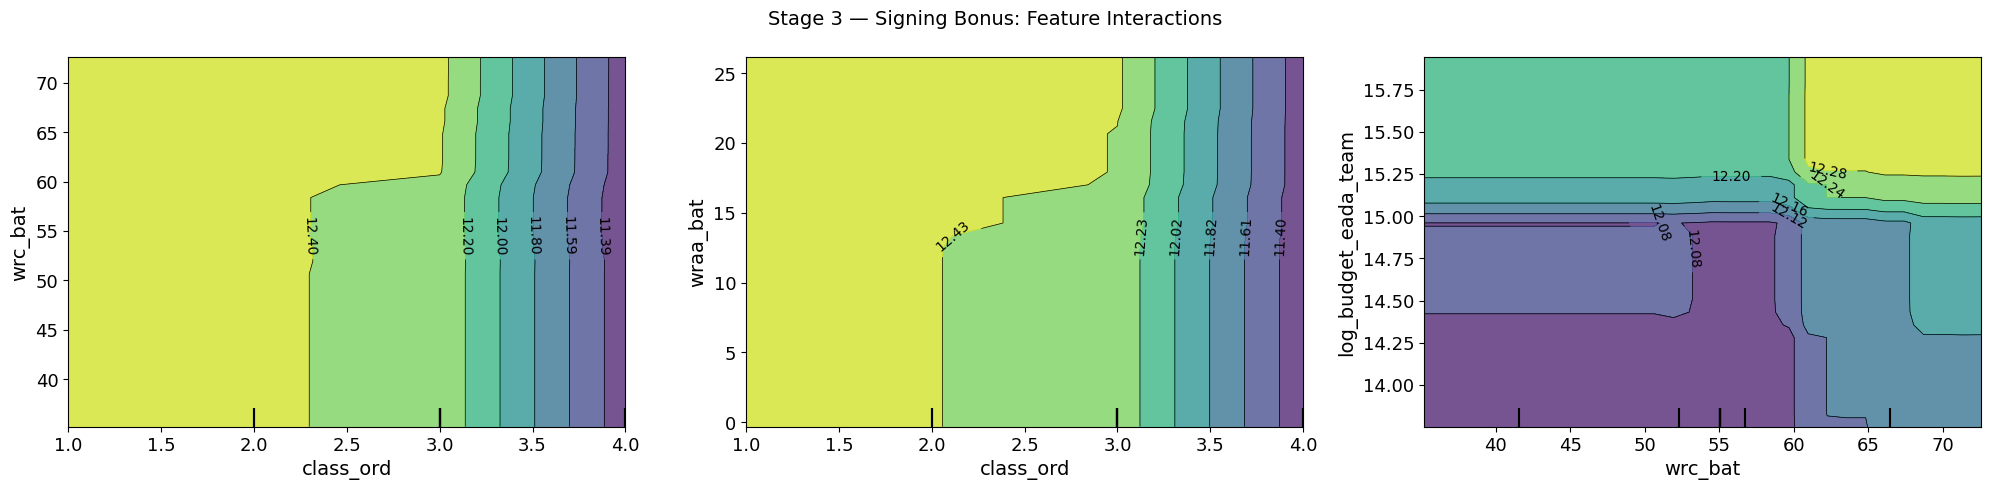

In [66]:
# 2D Interaction PDP - Signing Bonus Model
plot_pdp_2d(bonus_model, bonus_train[bonus_features], stage=3, name='pdp_2d_bonus',
            title='Stage 3 — Signing Bonus: Feature Interactions')

  saved figures_v7_public_nomin/s3_scatter.pdf


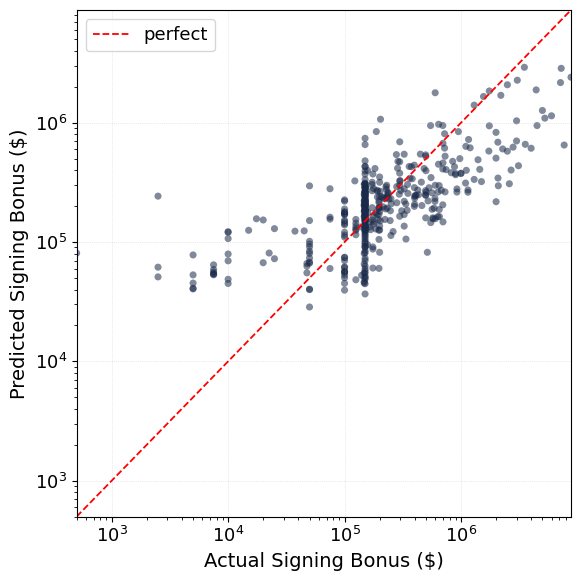

In [67]:
# Predicted vs actual signing bonus (log-log). Keeps the s3_scatter stem the paper cites.
plot_pred_vs_actual(np.maximum(bonus_results_df['Actual_Bonus'].values, 1.0),
                    np.maximum(bonus_results_df['Predicted_Bonus'].values, 1.0),
                    stage=3, name='scatter', log=True,
                    xlabel='Actual Signing Bonus ($)',
                    ylabel='Predicted Signing Bonus ($)')

  saved figures_v7_public_nomin/s3_residuals_bonus.pdf


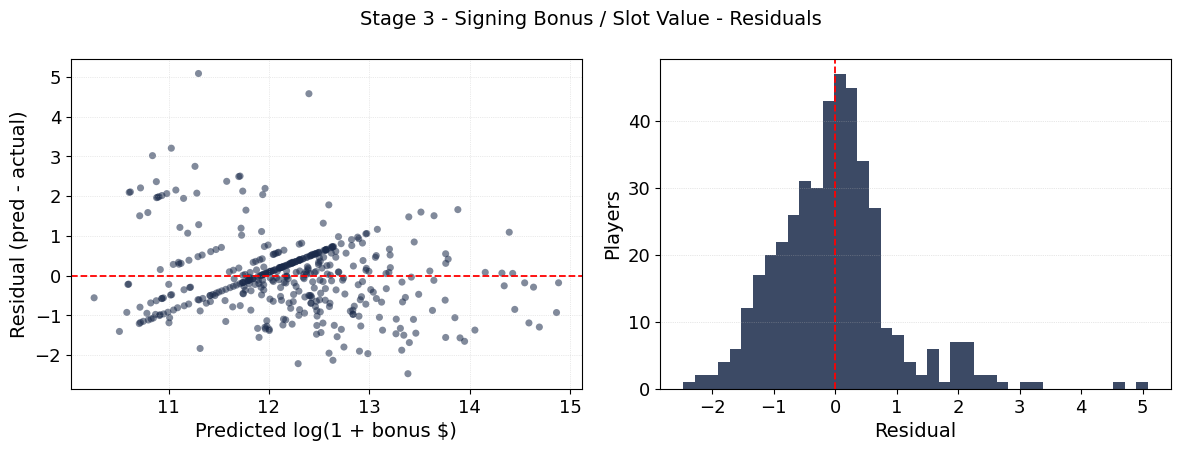

In [68]:
# Stage 3 -- signing-bonus residuals, in log space (dollar residuals are too
# heavy-tailed to read).
plot_residuals(bonus_test['log_signingBonus'].values, bonus_preds_log, stage=3,
               name='residuals_bonus', xlabel='Predicted log(1 + bonus $)')

---
## Slot Value Prediction & Bonus/Slot Ratio

In [69]:
# Slot value model - same structure as signing bonus model
# Target: log(1 + api_pickValue * 1e6)
slot_df = draftedClean_df[draftedClean_df['api_pickValue'].notna()].copy()
slot_df['log_pickValue'] = np.log1p(slot_df['api_pickValue'] * 1e6)

print(f"Players with pick value data: {len(slot_df)} / {len(draftedClean_df)}")
print(f"Pick value range: ${slot_df['api_pickValue'].min()*1e6:,.0f} - ${slot_df['api_pickValue'].max()*1e6:,.0f}")

# Use same features as bonus model (excludes api_pickValue to avoid leakage)
slot_features = bonus_features

slot_train = slot_df[slot_df[year_col] < test_year]
slot_test = slot_df[slot_df[year_col] == test_year]

print(f"\nTrain: {len(slot_train)} players | Test: {len(slot_test)} players")

slot_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
slot_model.fit(slot_train[slot_features], slot_train['log_pickValue'],
               eval_set=[(slot_test[slot_features], slot_test['log_pickValue'])], verbose=50)

slot_preds_log = slot_model.predict(slot_test[slot_features])
slot_preds_dollars = np.expm1(slot_preds_log)
slot_actual_dollars = np.expm1(slot_test['log_pickValue'].values)

mae_slot = mean_absolute_error(slot_actual_dollars, slot_preds_dollars)
r2_slot = r2_score(slot_actual_dollars, slot_preds_dollars)
corr_slot, p_slot = spearmanr(slot_actual_dollars, slot_preds_dollars)

print(f"\nSlot Value Model Results (Test Year: {test_year}, n={len(slot_test)}):")
print(f"  MAE:      ${mae_slot:,.0f}")
print(f"  R2:       {r2_slot:.3f}")
print(f"  Spearman: {corr_slot:.3f} (p={p_slot:.2e})")

METRICS['s3_slot'] = dict(
    test_year=int(test_year), n_train=int(len(slot_train)), n_test=int(len(slot_test)),
    mae=float(mae_slot), r2=float(r2_slot), spearman=float(corr_slot),
)

Players with pick value data: 1174 / 2109
Pick value range: $142,200 - $10,570,600

Train: 940 players | Test: 234 players


[0]	validation_0-mae:0.74975


[50]	validation_0-mae:0.59107


[100]	validation_0-mae:0.55591


[150]	validation_0-mae:0.54155


[200]	validation_0-mae:0.54064


[250]	validation_0-mae:0.53615


[300]	validation_0-mae:0.53462


[348]	validation_0-mae:0.53523



Slot Value Model Results (Test Year: 2025, n=234):
  MAE:      $515,393
  R2:       0.356
  Spearman: 0.636 (p=5.80e-28)


  saved figures_v7_public_nomin/s3_scatter_slot.pdf


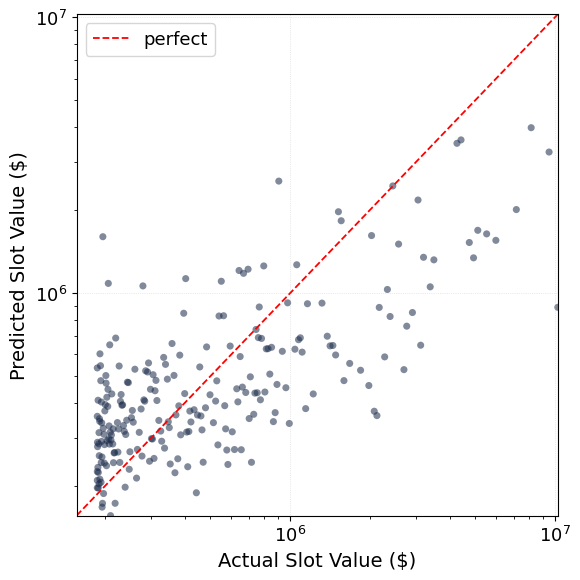

In [70]:
# Stage 3 (slot) -- predicted vs actual slot value (log-log).
plot_pred_vs_actual(np.maximum(slot_actual_dollars, 1.0),
                    np.maximum(slot_preds_dollars, 1.0),
                    stage=3, name='scatter_slot', log=True,
                    xlabel='Actual Slot Value ($)',
                    ylabel='Predicted Slot Value ($)')

  saved figures_v7_public_nomin/s3_residuals_slot.pdf


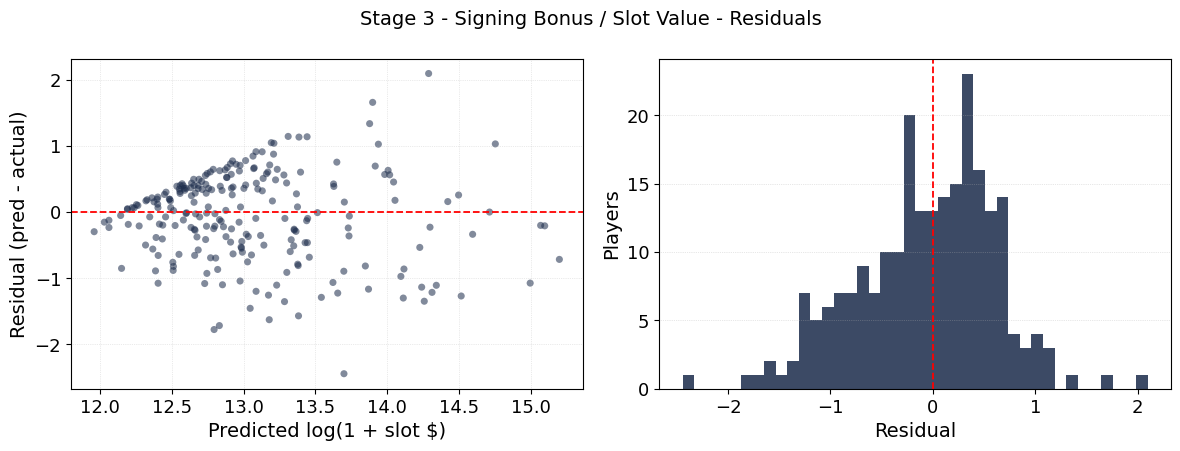

In [71]:
# Stage 3 (slot) -- residuals in log space.
plot_residuals(slot_test['log_pickValue'].values, slot_preds_log, stage=3,
               name='residuals_slot', xlabel='Predicted log(1 + slot $)')

---
## Official Slot by Predicted Pick

Slot value is a near-deterministic function of pick number, and `Pick` is withheld from
the models as leakage. So rather than regress slot dollars from college stats, chain
Stage 2's predicted draft order to the **published slot schedule** and read the dollars
off directly. The bonus / slot ratio below uses that official slot as its denominator.

SLOT VALUE -- chained lookup vs stats regression  (test 2025, n=171)
                                regression       chained
  R2 (dollars)                      +0.312        +0.295
  R2 (log dollars)                  +0.445        +0.310
  Spearman                           0.596         0.575
  MAE                             $664,084      $725,045
  median abs error                $243,055      $312,500
  median ratio error                 x1.67         x1.77


  saved figures_v7_public_nomin/s3_scatter_slot_chained.pdf


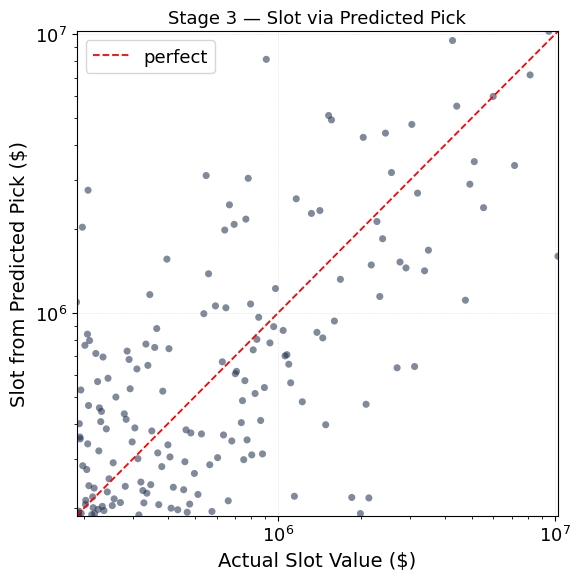

In [72]:
# Stage 3 -- official slot from the predicted pick, chained off Stage 2.
#
# For a given year the college draftees occupy a known, ordered set of overall picks, and
# College_Draft_Order k is by construction the k-th smallest of them. So a player predicted
# at order k is assigned that pick's published slot value. This removes the convexity
# amplification of regressing dollars directly: the model only has to get the ORDER right,
# and the payout curve is looked up rather than learned.
#
# Caveat: the set of college-occupied picks is only knowable after the draft, so this scores
# the ranking fairly but is not a pre-draft board. For a true pre-draft run you would
# substitute the prior year's schedule.

# Recompute the test-year order rather than reuse `pred_order`: the leave-one-year-out loop
# further up rebinds that global to the last fold's predictions.
_pred_rank  = model_rank.predict(test_df[pick_features])
_pred_order = pd.Series(_pred_rank).rank(method='min').astype(int).values

# Published slot schedule for the test year, indexed by college draft order.
_sched = (test_df[['Pick', 'api_pickValue']]
          .dropna(subset=['Pick'])
          .sort_values('Pick')
          .reset_index(drop=True))
_slot_by_order = _sched['api_pickValue'].values * 1e6      # position 0 == college order 1
_pick_by_order = _sched['Pick'].values
_n_order = len(_slot_by_order)

def slot_from_order(order):
    """Published slot dollars (and the pick it came from) for a 1-indexed college order."""
    idx = np.clip(np.asarray(order, dtype=int) - 1, 0, _n_order - 1)
    return _slot_by_order[idx], _pick_by_order[idx]

chain_slot_dollars, chain_pick = slot_from_order(_pred_order)
actual_slot_dollars = test_df['api_pickValue'].values * 1e6

# The stats-regression predictions live on slot_test (a subset); align them onto test_df.
_reg_slot = (pd.Series(slot_preds_dollars, index=slot_test.index)
             .reindex(test_df.index).values)

_m = ~np.isnan(chain_slot_dollars) & ~np.isnan(actual_slot_dollars) & ~np.isnan(_reg_slot)
_a = actual_slot_dollars[_m]

print("=" * 74)
print(f"SLOT VALUE -- chained lookup vs stats regression  (test {int(test_year)}, n={_m.sum()})")
print("=" * 74)
print(f"  {'':<26}{'regression':>14}{'chained':>14}")
for _lbl, _f in [
    ('R2 (dollars)',      lambda p: f"{r2_score(_a, p):+.3f}"),
    ('R2 (log dollars)',  lambda p: f"{r2_score(np.log1p(_a), np.log1p(p)):+.3f}"),
    ('Spearman',          lambda p: f"{spearmanr(_a, p)[0]:.3f}"),
    ('MAE',               lambda p: f"${mean_absolute_error(_a, p):,.0f}"),
    ('median abs error',  lambda p: f"${np.median(np.abs(p - _a)):,.0f}"),
    ('median ratio error',lambda p: f"x{np.exp(np.median(np.abs(np.log(p / _a)))):.2f}"),
]:
    print(f"  {_lbl:<26}{_f(_reg_slot[_m]):>14}{_f(chain_slot_dollars[_m]):>14}")

METRICS['s3_slot_chained'] = dict(
    n=int(_m.sum()),
    r2=float(r2_score(_a, chain_slot_dollars[_m])),
    r2_log=float(r2_score(np.log1p(_a), np.log1p(chain_slot_dollars[_m]))),
    mae=float(mean_absolute_error(_a, chain_slot_dollars[_m])),
    spearman=float(spearmanr(_a, chain_slot_dollars[_m])[0]),
)
METRICS['s3_slot']['r2_log'] = float(r2_score(np.log1p(_a), np.log1p(_reg_slot[_m])))

plot_pred_vs_actual(np.maximum(_a, 1.0), np.maximum(chain_slot_dollars[_m], 1.0),
                    stage=3, name='scatter_slot_chained', log=True,
                    xlabel='Actual Slot Value ($)',
                    ylabel='Slot from Predicted Pick ($)',
                    title='Stage 3 — Slot via Predicted Pick')

Bonus / Slot Ratio -- official slot denominator (test 2025, n=171, 0 unsigned)
  mean 0.904   median 0.944   at/over slot 52   under slot 119   zero 0
  predicted:  mean 0.638   median 0.534

Ratio distribution:
                     actual  predicted  actual %
0 (unsigned)              0          0       0.0
0-0.25                    7         10       4.1
0.25-0.50                 8         70       4.7
0.50-0.75                16         36       9.4
0.75-0.95                56         23      32.7
0.95-1.05 (at slot)      62          6      36.3
1.05-1.50                18         25      10.5
>1.50                     4          1       2.3

Anchoring to slot (n=171):
  exactly 1.0000:        27  ( 15.8%)
  within +/-5% of slot:  62  ( 36.3%)
  in [0.75, 1.05]:      126  ( 73.7%)

  ratio MAE 0.375   Spearman 0.340


,name,Round,Actual_Pick,Predicted_Pick,Actual_Bonus,Actual_Slot,Predicted_Slot,Predicted_Bonus,signed,Actual_Ratio,Predicted_Ratio
0,Tyler Bremner,1.000000,2.000000,58.000000,"$7,689,525","$10,252,700","$1,598,100","$649,892",True,0.750,0.407
1,Kade Anderson,1.000000,3.000000,2.000000,"$8,800,000","$9,504,400","$10,252,700","$2,406,055",True,0.926,0.235
2,Liam Doyle,1.000000,5.000000,7.000000,"$7,250,000","$8,134,800","$7,149,900","$2,854,247",True,0.891,0.399
3,Aiva Arquette,1.000000,7.000000,27.000000,"$7,149,900","$7,149,900","$3,382,600","$2,168,606",True,1.000,0.641
4,Jamie Arnold,1.000000,11.000000,11.000000,"$5,985,100","$5,985,100","$5,985,100","$1,142,660",True,1.000,0.191
5,Gavin Kilen,1.000000,13.000000,41.000000,"$5,247,500","$5,524,300","$2,386,900","$1,091,991",True,0.950,0.457
6,Kyson Witherspoon,1.000000,15.000000,26.000000,"$5,000,000","$5,114,200","$3,492,200","$1,266,418",True,0.978,0.363
7,Marek Houston,1.000000,16.000000,33.000000,"$4,497,500","$4,929,600","$2,898,300","$946,404",True,0.912,0.327
8,Ethan Conrad,1.000000,17.000000,74.000000,"$3,563,100","$4,750,800","$1,111,000","$659,160",True,0.750,0.593
9,Ike Irish,1.000000,19.000000,13.000000,"$4,418,400","$4,420,900","$5,524,300","$1,883,401",True,0.999,0.341


  saved figures_v7_public_nomin/s3_bonus_slot_ratio.pdf


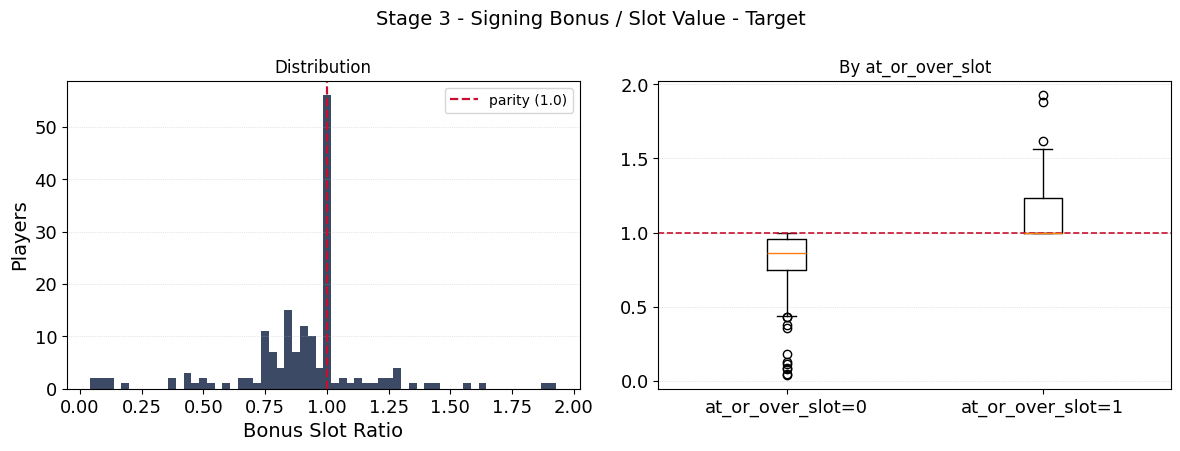

In [73]:
# Bonus / Slot Ratio, against the official slot for the predicted pick.
#   1.00 = signed at slot | >1 = over slot | <1 = under-slot deal | 0 = did not sign

_bonus_actual = test_df['api_signingBonus'].values * 1e6
_bonus_pred   = np.expm1(bonus_model.predict(test_df[bonus_features]))
_signed       = ~np.isnan(_bonus_actual)

# Unsigned picks are a real outcome, not missing data: no bonus means a ratio of 0.
_bonus_actual_filled = np.where(_signed, _bonus_actual, 0.0)

_has_slot = ~np.isnan(actual_slot_dollars) & ~np.isnan(chain_slot_dollars)

ratio_official_df = pd.DataFrame({
    'name':            test_df['nameascii'].values,
    'Round':           test_df['Round'].values,
    'Actual_Pick':     test_df['Pick'].values,
    'Predicted_Pick':  chain_pick,
    'Actual_Bonus':    _bonus_actual_filled,
    'Actual_Slot':     actual_slot_dollars,
    'Predicted_Slot':  chain_slot_dollars,
    'Predicted_Bonus': _bonus_pred,
    'signed':          _signed,
})[_has_slot].copy()

ratio_official_df['Actual_Ratio']    = (ratio_official_df['Actual_Bonus']
                                        / ratio_official_df['Actual_Slot'])
ratio_official_df['Predicted_Ratio'] = (ratio_official_df['Predicted_Bonus']
                                        / ratio_official_df['Predicted_Slot'])
ratio_official_df = ratio_official_df.sort_values('Actual_Pick').reset_index(drop=True)

_r = ratio_official_df['Actual_Ratio']
print(f"Bonus / Slot Ratio -- official slot denominator (test {int(test_year)}, "
      f"n={len(ratio_official_df)}, {int((~ratio_official_df['signed']).sum())} unsigned)")
print(f"  mean {_r.mean():.3f}   median {_r.median():.3f}   "
      f"at/over slot {(_r >= 1).sum()}   under slot {((_r > 0) & (_r < 1)).sum()}   "
      f"zero {(_r == 0).sum()}")
print(f"  predicted:  mean {ratio_official_df['Predicted_Ratio'].mean():.3f}   "
      f"median {ratio_official_df['Predicted_Ratio'].median():.3f}")

_bins   = [-0.001, 0.001, 0.25, 0.50, 0.75, 0.95, 1.05, 1.50, np.inf]
_labels = ['0 (unsigned)', '0-0.25', '0.25-0.50', '0.50-0.75',
           '0.75-0.95', '0.95-1.05 (at slot)', '1.05-1.50', '>1.50']
_dist = pd.DataFrame({
    'actual':    pd.cut(_r, _bins, labels=_labels).value_counts().reindex(_labels),
    'predicted': pd.cut(ratio_official_df['Predicted_Ratio'], _bins,
                        labels=_labels).value_counts().reindex(_labels),
})
_dist['actual %'] = (100 * _dist['actual'] / _dist['actual'].sum()).round(1)
print("\nRatio distribution:")
print(_dist.to_string())

# How tightly bonuses are anchored to the published schedule. Counted on closed
# intervals -- the pd.cut bands above are half-open, so they miss picks sitting exactly
# on an edge (there are 5 at exactly 0.75).
_rv = ratio_official_df['Actual_Ratio'].values
_n  = len(_rv)
_exact  = int((_rv == 1.0).sum())
_within = int((np.abs(_rv - 1.0) <= 0.05).sum())
_anchor = int(((_rv >= 0.75) & (_rv <= 1.05)).sum())
print(f"\nAnchoring to slot (n={_n}):")
print(f"  exactly 1.0000:      {_exact:>4}  ({100*_exact/_n:>5.1f}%)")
print(f"  within +/-5% of slot:{_within:>4}  ({100*_within/_n:>5.1f}%)")
print(f"  in [0.75, 1.05]:     {_anchor:>4}  ({100*_anchor/_n:>5.1f}%)")

METRICS['s3_ratio_anchoring'] = dict(n=_n, exact_slot=_exact,
                                     within_5pct=_within, in_075_105=_anchor)

METRICS['s3_ratio_official'] = dict(
    n=int(len(ratio_official_df)), n_unsigned=int((~ratio_official_df['signed']).sum()),
    actual_mean=float(_r.mean()), actual_median=float(_r.median()),
    pred_mean=float(ratio_official_df['Predicted_Ratio'].mean()),
    mae=float(mean_absolute_error(_r, ratio_official_df['Predicted_Ratio'])),
    spearman=float(spearmanr(_r, ratio_official_df['Predicted_Ratio'])[0]),
)
print(f"\n  ratio MAE {METRICS['s3_ratio_official']['mae']:.3f}   "
      f"Spearman {METRICS['s3_ratio_official']['spearman']:.3f}")

display(ratio_official_df.head(25).style.format({
    'Actual_Bonus': '${:,.0f}', 'Actual_Slot': '${:,.0f}',
    'Predicted_Slot': '${:,.0f}', 'Predicted_Bonus': '${:,.0f}',
    'Actual_Ratio': '{:.3f}', 'Predicted_Ratio': '{:.3f}'}))

plot_target_dist(_r.values, stage=3, name='bonus_slot_ratio', ref=1.0,
                 by=(_r.values >= 1).astype(int), by_label='at_or_over_slot')

  saved figures_v7_public_nomin/s3_bonus_slot_ratio_bands.pdf


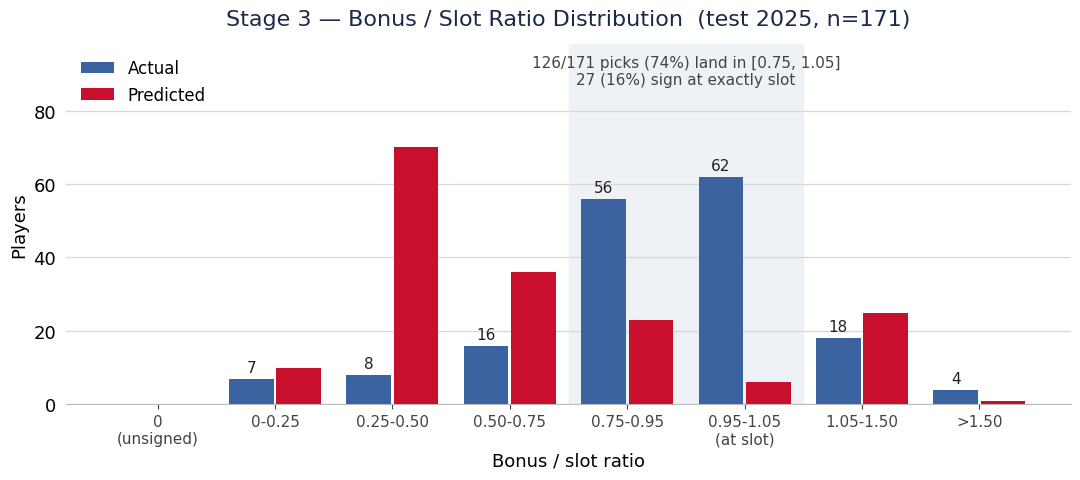

In [74]:
# Stage 3 -- bonus / slot ratio distribution, actual vs predicted.
#
# This is the notebook's only two-series chart, so it needs a categorical pair rather
# than the house single-series NAVY: #1a2a4a is too dark (L 0.29) and too low-chroma
# (0.06) to carry one of two hues. #3a63a0 stays in the navy family and clears the
# lightness, chroma, CVD-separation (protan dE 18.0) and contrast checks against RED.
CAT_BLUE, CAT_RED = '#3a63a0', '#c8102e'

_plot_labels = ['0\n(unsigned)', '0-0.25', '0.25-0.50', '0.50-0.75',
                '0.75-0.95', '0.95-1.05\n(at slot)', '1.05-1.50', '>1.50']
_act = _dist['actual'].to_numpy(dtype=float)
_prd = _dist['predicted'].to_numpy(dtype=float)
_x, _w = np.arange(len(_plot_labels)), 0.38
_top = max(_act.max(), _prd.max())

fig, ax = plt.subplots(figsize=(11, 5))

# Shade the anchor zone so the headline reads off the chart, not just the table.
ax.axvspan(3.5, 5.5, color='#eef1f6', zorder=0)
ax.annotate(f'{_anchor}/{_n} picks ({100*_anchor/_n:.0f}%) land in [0.75, 1.05]\n'
            f'{_exact} ({100*_exact/_n:.0f}%) sign at exactly slot',
            xy=(4.5, _top * 1.36), ha='center', va='top',
            fontsize=11, color='#444444', zorder=5)

# 2px surface gap between the paired bars
ax.bar(_x - _w/2 - 0.012, _act, _w, label='Actual', color=CAT_BLUE, zorder=3)
ax.bar(_x + _w/2 + 0.012, _prd, _w, label='Predicted', color=CAT_RED, zorder=3)

# Direct-label the actual series only: those are the reported counts, and the predicted
# series is read against them by height. Labelling both would be 16 numbers on 16 bars.
for _xi, _v in zip(_x, _act):
    if _v > 0:
        ax.text(_xi - _w/2 - 0.012, _v + _top * 0.015, f'{int(_v)}', ha='center',
                va='bottom', fontsize=11, color='#222222', zorder=4)

ax.set_xticks(_x)
ax.set_xticklabels(_plot_labels, fontsize=11)
ax.set_xlabel('Bonus / slot ratio', fontsize=13)
ax.set_ylabel('Players', fontsize=13)
ax.set_title(f'Stage 3 — Bonus / Slot Ratio Distribution  (test {int(test_year)}, n={_n})',
             fontsize=16, color=NAVY, pad=14)
ax.yaxis.grid(True, color=GRAY, linewidth=0.9, zorder=1)
ax.set_axisbelow(True)
for _s in ('top', 'right', 'left'):
    ax.spines[_s].set_visible(False)
ax.spines['bottom'].set_color('#bbbbbb')
ax.tick_params(left=False)
ax.tick_params(axis='x', labelsize=11, colors='#444444')
ax.set_ylim(0, _top * 1.40)   # headroom so the callout clears the tallest bar labels
ax.legend(frameon=False, fontsize=12, loc='upper left')
plt.tight_layout()
save_fig(fig, 3, 'bonus_slot_ratio_bands')
plt.show()

In [75]:
# Bonus / Slot Ratio
# Match players that have BOTH signing bonus and pick value predictions
common_idx = bonus_test.index.intersection(slot_test.index)
ratio_df_src = draftedClean_df.loc[common_idx].copy()

ratio_bonus_preds = np.expm1(bonus_model.predict(ratio_df_src[bonus_features]))
ratio_slot_preds = np.expm1(slot_model.predict(ratio_df_src[slot_features]))

# Ratio: 1 = slot value, >1 = team valued highly, <1 = discount
bonus_slot_ratio = ratio_bonus_preds / np.maximum(ratio_slot_preds, 1)

ratio_df = pd.DataFrame({
    'name': ratio_df_src['nameascii'].values,
    'Predicted_Bonus': ratio_bonus_preds,
    'Predicted_Slot': ratio_slot_preds,
    'Bonus_Slot_Ratio': bonus_slot_ratio,
    'Actual_Pick': ratio_df_src['Pick'].values if 'Pick' in ratio_df_src.columns else range(len(ratio_df_src)),
}).sort_values('Actual_Pick').reset_index(drop=True)

print("Bonus / Slot Value Ratio (Test Year):")
print("  1.00 = got slot value | >1 = team valued highly | <1 = discount\n")

disp_ratio = ratio_df.head(30).copy()
disp_ratio['Predicted_Bonus'] = disp_ratio['Predicted_Bonus'].apply(lambda x: f"${x:,.0f}")
disp_ratio['Predicted_Slot'] = disp_ratio['Predicted_Slot'].apply(lambda x: f"${x:,.0f}")
disp_ratio['Bonus_Slot_Ratio'] = disp_ratio['Bonus_Slot_Ratio'].apply(lambda x: f"{x:.2f}")
display(disp_ratio)

print(f"\nRatio Summary:")
print(f"  Mean:   {bonus_slot_ratio.mean():.2f}")
print(f"  Median: {np.median(bonus_slot_ratio):.2f}")
print(f"  >1 (over-slot): {(bonus_slot_ratio > 1).sum()} players")
print(f"  <1 (under-slot): {(bonus_slot_ratio < 1).sum()} players")

Bonus / Slot Value Ratio (Test Year):
  1.00 = got slot value | >1 = team valued highly | <1 = discount



,name,Predicted_Bonus,Predicted_Slot,Bonus_Slot_Ratio,Actual_Pick
0,Tyler Bremner,"$649,892","$889,396",0.73,2.0
1,Kade Anderson,"$2,406,055","$3,248,855",0.74,3.0
2,Liam Doyle,"$2,854,247","$3,980,452",0.72,5.0
3,Aiva Arquette,"$2,168,606","$2,010,532",1.08,7.0
4,Jamie Arnold,"$1,142,660","$1,555,009",0.73,11.0
5,Gavin Kilen,"$1,091,991","$1,641,248",0.67,13.0
6,Kyson Witherspoon,"$1,266,418","$1,690,877",0.75,15.0
7,Marek Houston,"$946,404","$1,343,832",0.70,16.0
8,Ethan Conrad,"$659,160","$1,527,224",0.43,17.0
9,Ike Irish,"$1,883,401","$3,594,735",0.52,19.0



Ratio Summary:
  Mean:   0.61
  Median: 0.62
  >1 (over-slot): 9 players
  <1 (under-slot): 225 players


In [76]:
# Show top features by importance from the trained classifier
importance = slot_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df.insert(0, 'Rank', importance_df.index + 1)
importance_df['Rank'] = '#' + importance_df['Rank'].astype(str)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(200))


All Features by Importance:
     Rank                          Feature  Importance
0      #1                          ops_bat   14.324514
1      #2                        class_ord   11.389466
2      #3                         so_pitch   10.567066
3      #4                          wrc_bat    9.616130
4      #5             log_budget_eada_team    8.037675
5      #6                          slg_bat    7.641407
6      #7    log_opex_per_player_eada_team    7.384640
7      #8                           hr_bat    5.828166
8      #9                        HRPG_team    5.683049
9     #10                  first_class_ord    5.243999
10    #11                            r_bat    5.045383
11    #12                         bb/k_bat    4.998765
12    #13  log_budget_per_player_eada_team    4.874228
13    #14                    conf_rpi_team    4.435755
14    #15                         wrc+_bat    4.432657
15    #16                start_share_pitch    4.362631
16    #17                         wr

  saved figures_v7_public_nomin/s3_feature_importance_slot.pdf


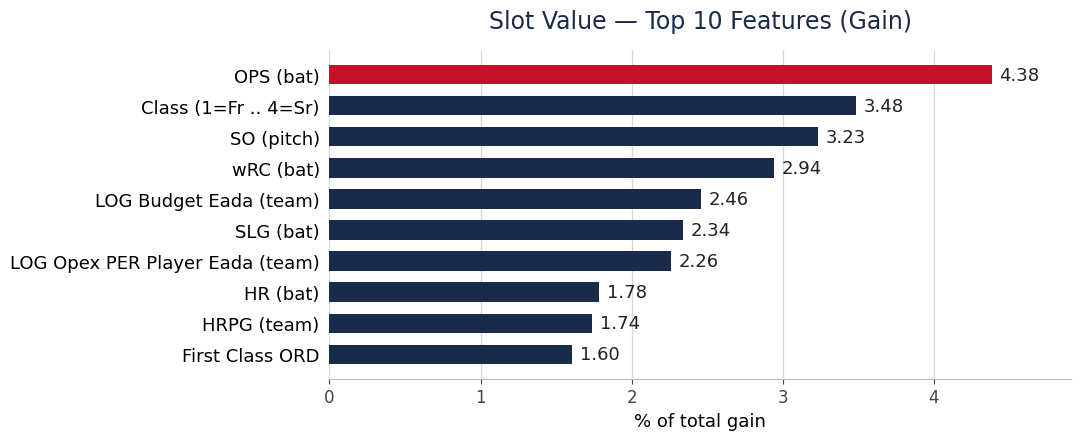

In [77]:
# Stage 3 (slot) -- feature importance.
plot_feature_importance(slot_model, stage=3, top_n=10, name='feature_importance_slot',
                        title='Slot Value — Top 10 Features (Gain)')

/var/folders/h9/bw1pqyx57b34ntg_28c5_g_80000gn/T/ipykernel_21178/3837196070.py:194: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, feature_names=[_pretty(c) for c in Xs.columns],


  saved figures_v7_public_nomin/s3_shap_summary_slot.pdf


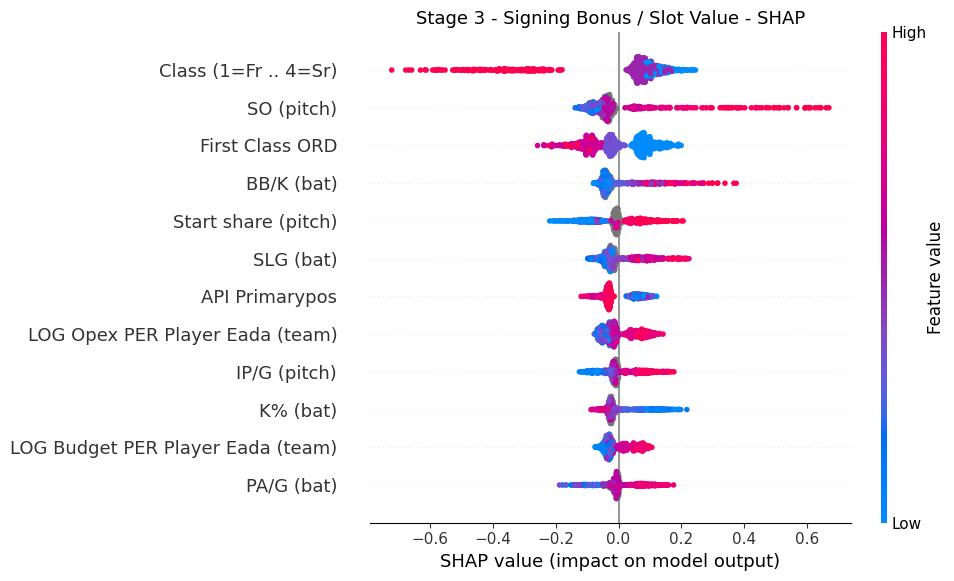

In [78]:
# Stage 3 (slot) -- SHAP beeswarm.
plot_shap_summary(slot_model, slot_train[slot_features], stage=3,
                  name='shap_summary_slot')

  saved figures_v7_public_nomin/s3_waterfall_slot_top.pdf


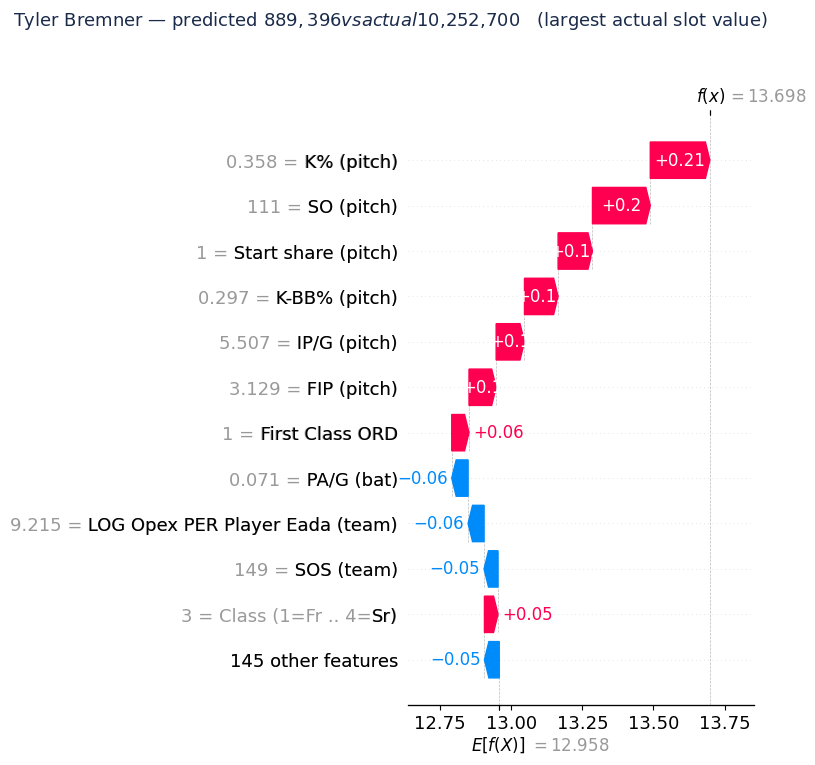

  saved figures_v7_public_nomin/s3_waterfall_slot_miss.pdf


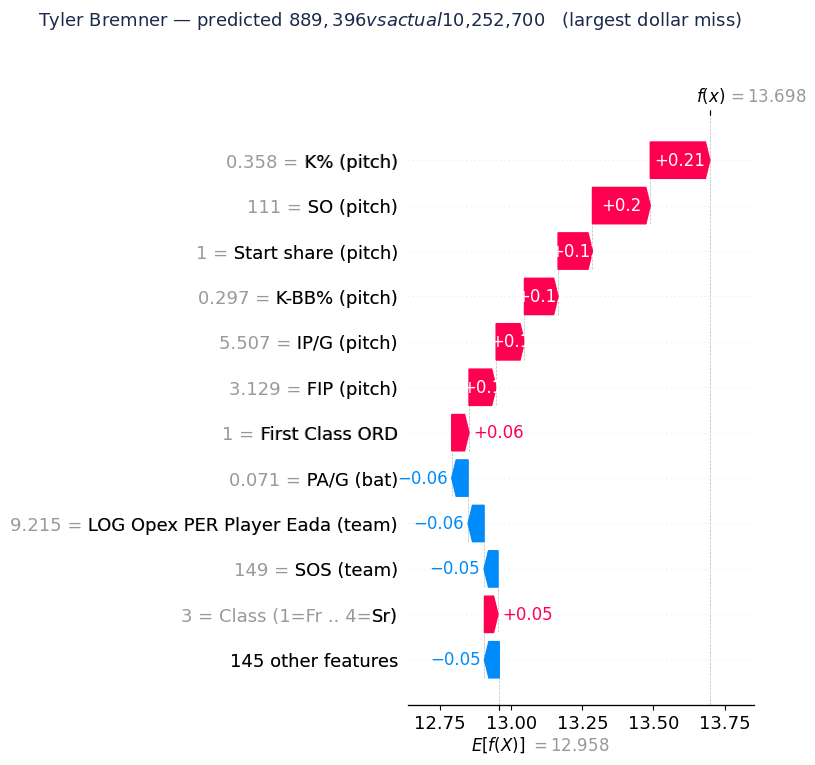

In [79]:
# Stage 3 (slot) -- per-player SHAP waterfalls.
_ns = slot_test['nameascii'].values
_Xs = slot_test[slot_features]
_i_tops  = int(np.argmax(slot_actual_dollars))
_i_misss = int(np.argmax(np.abs(slot_preds_dollars - slot_actual_dollars)))

for _i, _slug, _blurb in [(_i_tops,  'waterfall_slot_top',  'largest actual slot value'),
                          (_i_misss, 'waterfall_slot_miss', 'largest dollar miss')]:
    plot_shap_waterfall(slot_model, _Xs, _Xs.index[_i], stage=3, name=_slug,
                        title=(f"{_ns[_i]} — predicted ${slot_preds_dollars[_i]:,.0f} vs "
                               f"actual ${slot_actual_dollars[_i]:,.0f}   ({_blurb})"))

  saved figures_v7_public_nomin/s3_pdp_slot.pdf


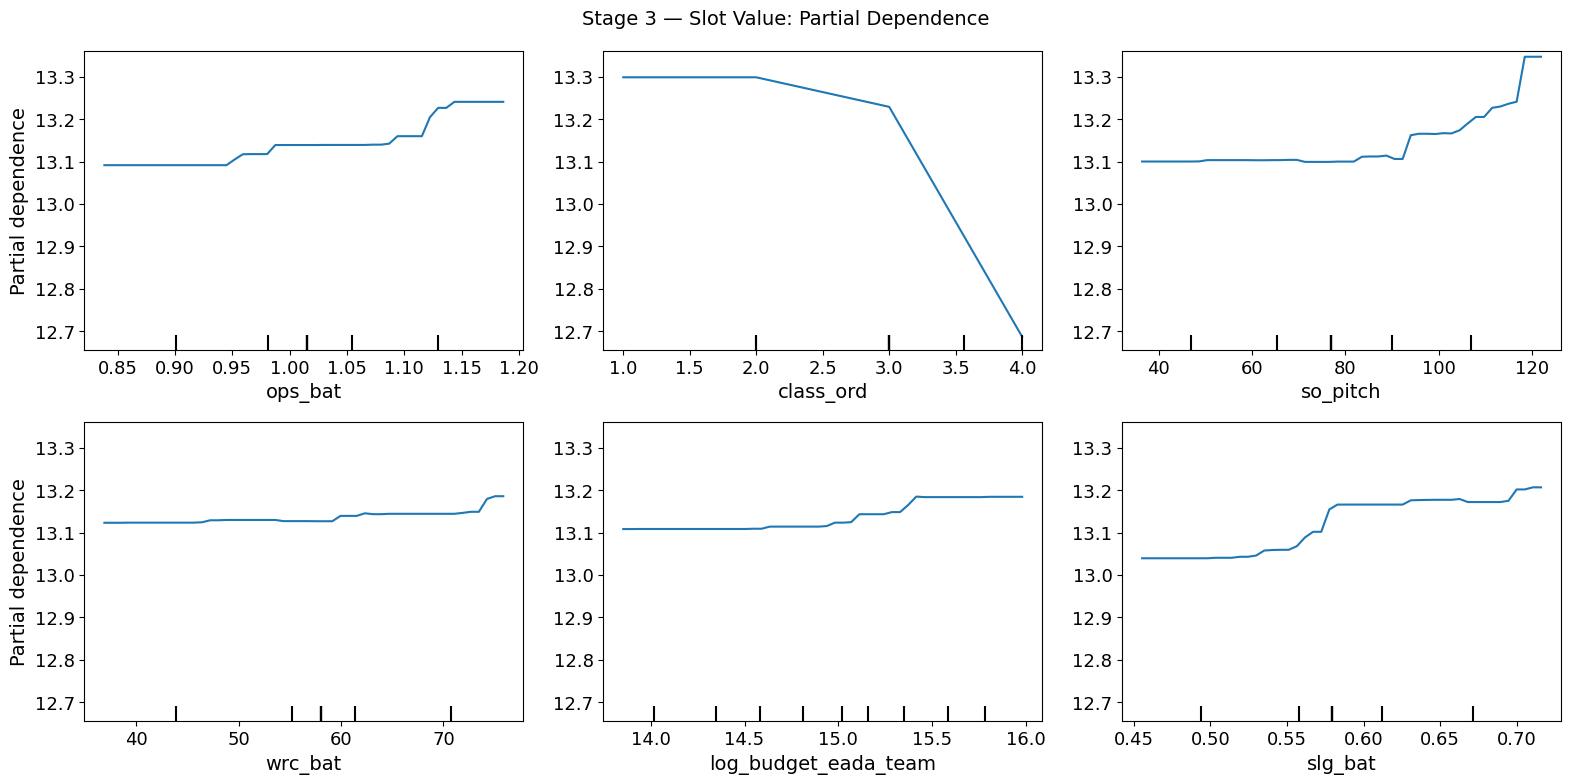

In [80]:
# Partial Dependence Plots - Slot Value Model
plot_pdp_grid(slot_model, slot_train[slot_features], stage=3, top_n=6,
              skip_binary=False, name='pdp_slot',
              title='Stage 3 — Slot Value: Partial Dependence')

  saved figures_v7_public_nomin/s3_pdp_2d_slot.pdf


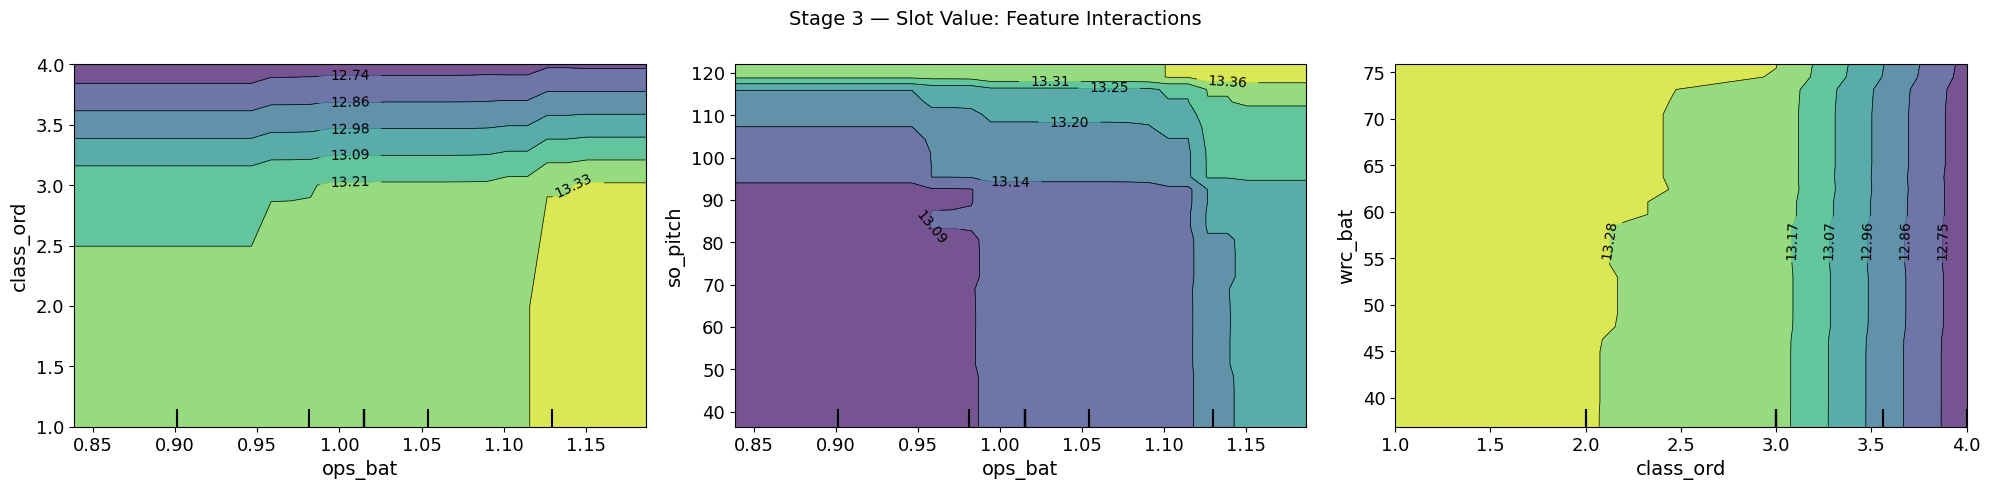

In [81]:
# 2D Interaction PDP - Slot Value Model
plot_pdp_2d(slot_model, slot_train[slot_features], stage=3, name='pdp_2d_slot',
            title='Stage 3 — Slot Value: Feature Interactions')

---
## Scouting Report Explainability Layer

For any player or custom stat line, the model now emits a **scouting report**:
a letter grade per dimension (Draft Probability and Draft Order Rank), a short
narrative, and ranked strengths/concerns showing which stats helped or hurt
the prediction.

Two explainers run side-by-side:

1. **SHAP TreeExplainer** — exact per-feature contribution to each prediction
   (gold-standard for XGBoost). Skipped automatically if `shap` is not installed.
2. **Importance × z-score** — XGBoost gain importance × `(player - train_median) / train_std`.
   No extra dependencies; works as a cross-check.

Scope: Draft Probability classifier (`draft_model`) and Draft Order Rank
regressor (`model_rank`). Bonus and slot models are out of scope here.


In [82]:
# Scouting Report -- explainer setup (run once)
# Builds the SHAP TreeExplainers (if shap is available), normalized feature
# importance dicts, training-set distributions for grading, a human label map,
# and a team-metadata frame re-loaded from the raw CSV (since cell 2 drops the
# team/Full Team Name/league_team columns from df to keep it numeric).

try:
    _HAS_SHAP = True
except Exception as _e:
    _HAS_SHAP = False
    print(f"shap unavailable ({_e.__class__.__name__}) -- falling back to importance x z-score only.")
    print("To enable SHAP: !pip install shap   (and ensure numpy<2 for the rest of this env)")

# Threshold below which the rank/bonus/slot predictions are suppressed in the
# scouting report -- the rank model is trained only on drafted players, so for
# clearly-not-drafted profiles those numbers are unreliable extrapolation.
MIN_DRAFT_PROB_FOR_PICK_DETAILS = 0.25

# Re-load just the team-metadata columns from the raw CSV. df has these dropped
# (cell 2) so it stays numeric for the models; we need them for the scouting header.
_team_meta = pd.read_csv(
    TEAM_META_FILE,
    delimiter=',',
    usecols=['nameascii', 'year', 'team', 'Full Team Name', 'league_team'],
)
_team_meta_idx = (
    _team_meta.dropna(subset=['nameascii', 'year'])
              .drop_duplicates(subset=['nameascii', 'year'], keep='last')
              .set_index(['nameascii', 'year'])
)

def _get_player_team_meta(nameascii, year):
    """Return {team, Full Team Name, league_team} for (nameascii, year), or Nones."""
    try:
        row = _team_meta_idx.loc[(nameascii, int(year))]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        return {
            'team': row.get('team'),
            'Full Team Name': row.get('Full Team Name'),
            'league_team': row.get('league_team'),
        }
    except (KeyError, TypeError):
        return {'team': None, 'Full Team Name': None, 'league_team': None}

# Snapshot the *_team stat columns at setup time -- the Carbon Tracking cell at
# the end of the notebook reassigns df = pd.read_csv(emissions.csv), so any later
# call into get_team_stats would fail with KeyError on df['nameascii']. Build a
# frozen (team_lower, year) -> {*_team col: value} lookup right here, while df
# still points at the player frame.
_team_stat_cols = [c for c in df.columns if c.endswith('_team')]
_TEAM_STATS_BY_TEAM_YEAR = {}
for (_tc, _yr), _grp in (_team_meta
                         .dropna(subset=['nameascii', 'year', 'team'])
                         .groupby(['team', 'year'])):
    _na = _grp['nameascii'].iloc[0]
    _m = df[(df['nameascii'] == _na) & (df[year_col] == _yr)]
    if _m.empty:
        continue
    _row = _m.iloc[0]
    _TEAM_STATS_BY_TEAM_YEAR[(str(_tc).lower(), int(_yr))] = {
        col: _row[col] for col in _team_stat_cols
    }

# Training-set summary stats on the same split used for train_medians.
train_stds = df[df[year_col] < test_year].std(numeric_only=True)

# TreeExplainers (operate on raw model objects; very fast for XGBoost).
expl_draft = shap.TreeExplainer(draft_model) if _HAS_SHAP else None
expl_rank  = shap.TreeExplainer(model_rank)  if _HAS_SHAP else None

# Normalized gain-importance dicts (sum to 1.0).
def _normed_importance(model):
    raw = model.get_booster().get_score(importance_type='gain')
    total = sum(raw.values()) or 1.0
    return {k: v / total for k, v in raw.items()}

imp_draft = _normed_importance(draft_model)
imp_rank  = _normed_importance(model_rank)

# Training distributions for letter-grading the predictions.
_train_mask     = df[year_col] < test_year
_train_X_cls    = df.loc[_train_mask, features]
_train_drafted  = draftedClean_df[draftedClean_df[year_col] < test_year]
_train_X_rank   = _train_drafted[pick_features]
_train_draft_probs = draft_model.predict_proba(_train_X_cls)[:, 1]
_train_rank_preds  = model_rank.predict(_train_X_rank)

# Human-readable labels (raw column name -> short label).
FEATURE_LABELS = {
    'class_ord': 'Class (1=Fr .. 4=Sr)', 'role': 'Role',
    # Pitching
    'era_pitch': 'ERA',         'fip_pitch': 'FIP',
    'k/9_pitch': 'K/9',         'bb/9_pitch': 'BB/9',
    'k/bb_pitch': 'K/BB',       'whip_pitch': 'WHIP',
    'k%_pitch': 'K%',           'bb%_pitch': 'BB%',
    'k-bb%_pitch': 'K-BB%',     'ip_pitch': 'IP',
    'so_pitch': 'SO',           'bb_pitch': 'BB (pitch)',
    'h_pitch': 'H allowed',     'hr_pitch': 'HR allowed',
    'hr/9_pitch': 'HR/9',       'er_pitch': 'ER',
    'r_pitch': 'R allowed',     'avg_pitch': 'BA against',
    'babip_pitch': 'BABIP-against', 'lob%_pitch': 'LOB%',
    'e-f_pitch': 'ERA-FIP',     'sv_pitch': 'SV',
    'g_pitch': 'G (pitch)',     'gs_pitch': 'GS',
    'w_pitch': 'W',             'l_pitch': 'L',
    'tbf_pitch': 'TBF',         'hbp_pitch': 'HBP (pitch)',
    'wp_pitch': 'WP',           'bk_pitch': 'BK',
    'cg_pitch': 'CG',           'sho_pitch': 'SHO',
    # Batting
    'avg_bat': 'AVG',  'obp_bat': 'OBP',  'slg_bat': 'SLG',  'ops_bat': 'OPS',
    'iso_bat': 'ISO',  'woba_bat': 'wOBA','wrc+_bat': 'wRC+','wrc_bat': 'wRC',
    'wraa_bat': 'wRAA','hr_bat': 'HR',    'rbi_bat': 'RBI',  'r_bat': 'R',
    'h_bat': 'H',      '2b_bat': '2B',    '3b_bat': '3B',    '1b_bat': '1B',
    'bb%_bat': 'BB% (bat)',  'k%_bat': 'K% (bat)',
    'bb_bat': 'BB (bat)',    'so_bat': 'SO (bat)',
    'sb_bat': 'SB',          'cs_bat': 'CS',
    'babip_bat': 'BABIP',    'spd_bat': 'Spd',
    'g_bat': 'G (bat)',      'ab_bat': 'AB',  'pa_bat': 'PA',
    'hbp_bat': 'HBP (bat)',  'sf_bat': 'SF',  'sh_bat': 'SH',  'gdp_bat': 'GDP',
    'bb/k_bat': 'BB/K',      'wsb_bat': 'wSB',
    # derived playing-time ratios
    'ip_per_g_pitch': 'IP/G',        'start_share_pitch': 'Start share',
    'pa_per_g_bat': 'PA/G',          'g_share_bat': 'Team G share',
    'ip_share_pitch': 'Team IP share','ab_share_bat': 'Team AB share',
    'so_per_ip_pitch': 'SO/IP',
}


def get_team_stats(team, team_year):
    """Return all *_team stats for a (team, team_year) pair, plus resolved metadata.

    Strict: `team` matches the raw-CSV `team` column case-insensitively (e.g. 'LSU',
    'USF'); `team_year` must exactly match `year`. Reads from the setup-time
    snapshot `_TEAM_STATS_BY_TEAM_YEAR` (not from df), so it stays correct even
    after the Carbon Tracking cell reassigns df to the emissions frame.

    Returns a flat dict for predict_from_stats(..., team_stats_dict=...). The
    `_resolved_*` keys carry display metadata and are ignored by the predictor.

    Raises ValueError if no match is found.
    """
    if team is None or team_year is None:
        raise ValueError("get_team_stats requires both `team` and `team_year`.")
    key = (str(team).lower(), int(team_year))
    stats = _TEAM_STATS_BY_TEAM_YEAR.get(key)
    if stats is None:
        codes = sorted({k[0].upper() for k in _TEAM_STATS_BY_TEAM_YEAR})[:25]
        raise ValueError(
            f"No rows found for team={team!r} year={team_year}. "
            f"Try one of (first 25 codes): {codes}. "
            f"Full list: sorted({{k[0].upper() for k in _TEAM_STATS_BY_TEAM_YEAR}})."
        )

    mask = (_team_meta['team'].astype(str).str.lower() == str(team).lower()) & (_team_meta['year'] == team_year)
    meta = _team_meta[mask].iloc[0]

    out = dict(stats)
    out['_resolved_team'] = str(meta['team']).upper()
    out['_resolved_team_year'] = int(team_year)
    full_name = meta.get('Full Team Name')
    out['_resolved_full_name'] = str(full_name).title() if pd.notna(full_name) else out['_resolved_team']
    league = meta.get('league_team')
    out['_resolved_conference'] = str(league) if pd.notna(league) else None
    return out


print("Explainer setup loaded.")
print(f"  SHAP available:        {_HAS_SHAP}")
print(f"  draft features:        {len(features)}    rank features: {len(pick_features)}")
print(f"  train baseline draft%: {_train_draft_probs.mean()*100:.1f}%")
print(f"  train rank dist:       median={np.median(_train_rank_preds):.1f}  "
      f"p10={np.percentile(_train_rank_preds,10):.1f}  p90={np.percentile(_train_rank_preds,90):.1f}")
print(f"  pick-detail threshold: {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% draft prob (below this, rank/bonus/slot are hidden)")
print(f"  team-meta rows loaded: {len(_team_meta):,}  (re-loaded from CSV; df has these columns dropped)")
print(f"  team-stats snapshot:   {len(_TEAM_STATS_BY_TEAM_YEAR):,} (team, year) pairs cached (survives df mutations)")
print(f"  get_team_stats() ready -- usage: get_team_stats('LSU', 2024)")


Explainer setup loaded.
  SHAP available:        True
  draft features:        151    rank features: 156
  train baseline draft%: 16.4%
  train rank dist:       median=217.1  p10=87.7  p90=316.8
  pick-detail threshold: 25% draft prob (below this, rank/bonus/slot are hidden)
  team-meta rows loaded: 50,836  (re-loaded from CSV; df has these columns dropped)
  team-stats snapshot:   1,510 (team, year) pairs cached (survives df mutations)
  get_team_stats() ready -- usage: get_team_stats('LSU', 2024)


In [83]:
# Scouting Report -- core functions
#   _explain_one(row, kind)  -> per-feature contribution records
#   _grade(percentile)       -> letter grade
#   scouting_report(row, draft_prob, rank_pred, name=..., team=..., conference=...)

def _label(feat):
    return FEATURE_LABELS.get(feat, feat)

def _fmt(value):
    if value is None: return '-'
    if isinstance(value, float):
        if np.isnan(value) or np.isinf(value): return '-'
        return f"{value:.3f}" if abs(value) < 10 else f"{value:.1f}"
    return str(value)

def _rec_score(r):
    """Single sortable score per record: prefer SHAP, fall back to imp_z."""
    for k in ('shap_pct', 'shap_picks'):
        if r[k] is not None and not (isinstance(r[k], float) and np.isnan(r[k])):
            return r[k]
    return r['imp_z']

def _explain_one(row_series, model_kind):
    """Return contribution records sorted strengths-first (positive = good for the player)."""
    if model_kind == 'draft':
        feat_list, imp, explainer, sign_flip = features, imp_draft, expl_draft, 1.0
    elif model_kind == 'rank':
        feat_list, imp, explainer, sign_flip = pick_features, imp_rank, expl_rank, -1.0
    else:
        raise ValueError(model_kind)

    vals = row_series.reindex(feat_list).values
    x_df = pd.DataFrame([vals], columns=feat_list)

    shap_vals = None
    base = 0.0
    log_pred = 0.0
    if explainer is not None:
        sv = explainer.shap_values(x_df)
        if isinstance(sv, list):
            sv = sv[1]
        shap_vals = sv[0]
        ev = explainer.expected_value
        try:
            base = float(ev) if not hasattr(ev, '__len__') else float(ev[1] if len(ev) > 1 else ev[0])
        except (TypeError, ValueError):
            base = float(np.asarray(ev).ravel()[-1])
        log_pred = base + float(np.nansum(shap_vals))

    recs = []
    for i, feat in enumerate(feat_list):
        v = row_series.get(feat)
        if v is None or (isinstance(v, float) and pd.isna(v)):
            continue
        med = train_medians.get(feat, np.nan)
        std = train_stds.get(feat, np.nan)
        imp_z = 0.0 if (pd.isna(std) or std == 0) else imp.get(feat, 0.0) * float((v - med) / std) * sign_flip

        shap_pct = shap_picks = None
        if shap_vals is not None:
            s = float(shap_vals[i])
            if model_kind == 'draft':
                shap_pct = (expit(log_pred) - expit(log_pred - s)) * 100.0
            else:
                shap_picks = s * sign_flip

        recs.append({
            'feature': feat, 'label': _label(feat),
            'value': v, 'median': med,
            'shap_pct': shap_pct, 'shap_picks': shap_picks,
            'imp_z': imp_z,
        })

    recs.sort(key=_rec_score, reverse=True)
    return recs


def _draft_grade(draft_prob):
    """Map raw draft probability directly to a letter grade.

    Absolute thresholds (not training percentiles), so 0% -> F instead of D+:
        >= 90% A+   >= 80% A    >= 70% A-
        >= 60% B+   >= 50% B    >= 40% B-
        >= 30% C+   >= 20% C    >= 10% C-
        >=  5% D+   >=  2% D    >=  1% D-
        <   1% F
    Returns (letter, training_pct) -- training_pct is still computed so the report
    can show it as an auxiliary stat in parentheses.
    """
    p_pct = draft_prob * 100
    bands = [(90,'A+'),(80,'A'),(70,'A-'),(60,'B+'),(50,'B'),(40,'B-'),
             (30,'C+'),(20,'C'),(10,'C-'),(5,'D+'),(2,'D'),(1,'D-')]
    letter = 'F'
    for thresh, lbl in bands:
        if p_pct >= thresh:
            letter = lbl
            break
    train_pct = float((_train_draft_probs <= draft_prob).mean() * 100)
    return letter, train_pct


def _rank_grade(rank_pred):
    pct = float((_train_rank_preds >= rank_pred).mean() * 100)
    bins = [(95,'A+'),(88,'A'),(80,'A-'),(72,'B+'),(62,'B'),(54,'B-'),
            (46,'C+'),(38,'C'),(30,'C-'),(22,'D+'),(15,'D'),(8,'D-')]
    letter = 'F'
    for t, lbl in bins:
        if pct >= t:
            letter = lbl
            break
    return letter, pct


def _narrative(draft_letter, top_strength, top_concern, rank_pred, show_rank):
    band = {
        'A+':'a top profile', 'A':'an elite projection',
        'A-':'a strong projection', 'B+':'a sturdy projection',
        'B':'a solid projection', 'B-':'a mid projection',
        'C+':'a back-half projection', 'C':'a fringe projection',
        'C-':'a fringe-draftable profile', 'D+':'a long-shot draft profile',
        'D':'an undrafted-leaning profile', 'D-':'a Undrafted Free Agent (UDFA)-leaning profile',
        'F':'a clearly undrafted-leaning profile',
    }.get(draft_letter, 'a draftable profile')
    rank_phrase = f" (~pick {int(round(rank_pred))})" if show_rank else ""
    parts = [f"The model sees {band}{rank_phrase}."]
    if top_strength is not None:
        parts.append(f"Driven by {top_strength['label']} ({_fmt(top_strength['value'])} vs {_fmt(top_strength['median'])} median).")
    if top_concern is not None:
        parts.append(f"Main red flag: {top_concern['label']} ({_fmt(top_concern['value'])} vs {_fmt(top_concern['median'])} median).")
    return " ".join(parts)


def scouting_report(row_series, draft_prob, rank_pred, name=None, team=None, conference=None, top_n=5):
    """Print the scouting report block.

    row_series: pandas Series indexed by feature name (player or custom row).
    team/conference: optional strings shown right under the player name.
    """
    name = name or 'Custom Stat Line'
    show_rank = draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS

    d_letter, d_pct = _draft_grade(draft_prob)
    if show_rank:
        r_letter, r_pct = _rank_grade(rank_pred)

    draft_recs = _explain_one(row_series, 'draft')
    rank_recs  = _explain_one(row_series, 'rank') if show_rank else []

    strengths = [r for r in draft_recs if _rec_score(r) > 0][:top_n]
    concerns  = [r for r in reversed(draft_recs) if _rec_score(r) < 0][:top_n]
    top_s = strengths[0] if strengths else None
    top_c = concerns[0] if concerns else None

    sep = '=' * 64
    print(f"\n{sep}")
    print(f"  Scouting Report: {name}")
    if team or conference:
        parts = []
        if team:       parts.append(f"Team: {team}")
        if conference: parts.append(f"Conference: {conference}")
        print(f"  {'   '.join(parts)}")
    print(sep)
    print(f"  Draft Grade: {d_letter}   (P[draft]={draft_prob*100:.1f}%, "
          f"{d_pct:.0f}th pct of training preds)")
    if show_rank:
        print(f"  Rank  Grade: {r_letter}   (predicted pick ~{int(round(rank_pred))}, "
              f"{r_pct:.0f}th pct of training preds)")
    else:
        print(f"  Rank  Grade: -    (suppressed: draft prob < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}%)")
    print('-' * 64)
    print(f"  Take: {_narrative(d_letter, top_s, top_c, rank_pred, show_rank)}")

    def _print_block(title, recs, arrow):
        print()
        header = "    feature             value      vs median"
        if _HAS_SHAP: header += "      d-prob"
        header += "    imp x z"
        print(f"  {title}")
        print(header)
        if not recs:
            print("    (none)")
            return
        for r in recs:
            shap_part = ''
            if _HAS_SHAP and r['shap_pct'] is not None:
                shap_part = f"   {r['shap_pct']:+6.2f}%"
            elif _HAS_SHAP:
                shap_part = '          -'
            imp_part = f"   {r['imp_z']:+7.3f}"
            print(f"    {arrow} {r['label']:<16s}  {_fmt(r['value']):>8s}  "
                  f"(vs {_fmt(r['median']):>7s}){shap_part}{imp_part}")

    _print_block(f"Top {len(strengths)} STRENGTHS (boost draft stock)", strengths, '^')
    _print_block(f"Top {len(concerns)} CONCERNS  (drag it down)",        concerns,  'v')

    if show_rank:
        r_str = [r for r in rank_recs if _rec_score(r) > 0][:3]
        r_con = [r for r in reversed(rank_recs) if _rec_score(r) < 0][:3]
        print()
        print("  Rank-model cross-check (which features improve / hurt predicted pick):")
        print(f"    + improves pick: {', '.join(r['label'] for r in r_str) or '(none)'}")
        print(f"    - hurts pick:    {', '.join(r['label'] for r in r_con) or '(none)'}")
    print(sep)


---
## Player Lookup by Name

Fuzzy-match a player and show stats, draft probability, predicted college order, and predicted signing bonus.

In [84]:
train_medians = df[df[year_col] < test_year].median(numeric_only=True)

def _format_team_display(team_code, full_team_name):
    """Title-case the full team name; append the short code in parens if both exist."""
    has_full = pd.notna(full_team_name) and str(full_team_name).strip()
    has_code = pd.notna(team_code) and str(team_code).strip()
    if has_full and has_code:
        return f"{str(full_team_name).title()} ({str(team_code).upper()})"
    if has_full:
        return str(full_team_name).title()
    if has_code:
        return str(team_code).upper()
    return None

def lookup_player(name_query, year=None, explain=True):
    candidates = df if year is None else df[df[year_col] == year]
    names = candidates['nameascii'].dropna().unique().tolist()
    matches = get_close_matches(name_query, names, n=5, cutoff=0.4)
    if not matches:
        print(f"No match found for '{name_query}'"); return None

    player = candidates[candidates['nameascii'] == matches[0]].sort_values(year_col, ascending=False).iloc[0]
    role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Two-Way'}.get(player['role'], '?')

    # team/Full Team Name/league_team were dropped from df in cell 2 to keep
    # df numeric; re-load them from _team_meta (built in cell 56 from the CSV).
    team_meta = _get_player_team_meta(player['nameascii'], int(player[year_col]))
    team_display = _format_team_display(team_meta['team'], team_meta['Full Team Name'])
    league = team_meta['league_team']
    conf_display = str(league) if pd.notna(league) else None

    print(f"{'='*60}")
    print(f"Player: {player['nameascii']}  |  Year: {int(player[year_col])}  |  Role: {role_name}")
    if team_display or conf_display:
        bits = []
        if team_display: bits.append(f"Team: {team_display}")
        if conf_display: bits.append(f"Conference: {conf_display}")
        print('  ' + '   '.join(bits))
    print(f"{'='*60}")

    if not pd.isna(player.get('api_height')):
        ft, inch = int(player['api_height'] // 12), int(player['api_height'] % 12)
        print(f"Height: {ft}'{inch}\"  |  Weight: {int(player.get('api_weight', 0))} lbs")
    pos_rev = {1:'C', 2:'SS', 3:'2B', 4:'3B', 5:'CF', 6:'LF', 7:'RF', 8:'IF', 9:'1B', 10:'OF', 11:'DH', 12:'P', 13:'TWP'}
    if not pd.isna(player.get('api_primaryPos')):
        print(f"Position: {pos_rev.get(int(player['api_primaryPos']), '?')}")

    print(f"\n--- Key Stats ---")
    if player['role'] in [0, 2]:
        for s in ['era_pitch', 'fip_pitch', 'k/9_pitch', 'bb/9_pitch', 'whip_pitch', 'ip_pitch', 'so_pitch']:
            if not pd.isna(player.get(s)): print(f"  {s}: {player[s]:.2f}")
    if player['role'] in [1, 2]:
        for s in ['avg_bat', 'ops_bat', 'hr_bat', 'wrc+_bat', 'woba_bat', 'slg_bat', 'bb%_bat', 'k%_bat']:
            if not pd.isna(player.get(s)):
                v = player[s]; print(f"  {s}: {v:.3f}" if isinstance(v, float) and v < 10 else f"  {s}: {v:.1f}")

    cls_df = pd.DataFrame([player.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([player.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([player.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    slot_df_in = pd.DataFrame([player.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"\n--- Predictions ---")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    if draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS:
        print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
        print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
        print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
        print(f"Predicted Slot Value: ${slot_pred:,.0f}")
        print(f"Bonus/Slot Ratio: {ratio:.2f}")
    else:
        print(f"Predicted draft order / signing bonus / slot value suppressed "
              f"(draft prob {draft_prob*100:.1f}% < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% threshold -- "
              f"the rank/bonus/slot models are trained only on drafted players and would be extrapolating).")

    if not pd.isna(player.get('Pick')):
        print(f"\n--- Actual ---")
        print(f"Pick: {int(player['Pick'])} (Round {int(player.get('Round', 0))})")
        if not pd.isna(player.get('College_Draft_Order')): print(f"College Order: {int(player['College_Draft_Order'])}")
        if not pd.isna(player.get('api_signingBonus')): print(f"Signing Bonus: ${player['api_signingBonus']*1e6:,.0f}")
    if len(matches) > 1: print(f"\nOther matches: {matches[1:]}")

    if explain and 'scouting_report' in globals():
        scouting_report(player, draft_prob, rank_pred,
                        name=player['nameascii'],
                        team=team_display,
                        conference=conf_display)

    return player

print("lookup_player() defined. Usage: lookup_player('Jace LaViolette')")


lookup_player() defined. Usage: lookup_player('Jace LaViolette')


In [85]:
lookup_player('Jace LaViolette')

Player: Jace Laviolette  |  Year: 2025  |  Role: Batter
  Team: Texas A&M University (TA&M)   Conference: SEC

--- Key Stats ---
  avg_bat: 0.258
  ops_bat: 1.003
  hr_bat: 18.0
  wrc+_bat: 115.4
  woba_bat: 0.428
  slg_bat: 0.576
  bb%_bat: 0.218
  k%_bat: 0.252

--- Predictions ---
Draft Probability: 99.7%
Predicted College Draft Order: ~86
Predicted College Draft Pct: 18.6%
Predicted Signing Bonus: $611,001
Predicted Slot Value: $1,076,801
Bonus/Slot Ratio: 0.57

--- Actual ---
Pick: 27 (Round 1)

Other matches: ['Jack Colette', 'Jake Little', 'Jack Little', 'Jayce Lee']

  Scouting Report: Jace Laviolette
  Team: Texas A&M University (TA&M)   Conference: SEC
  Draft Grade: A+   (P[draft]=99.7%, 98th pct of training preds)
  Rank  Grade: A   (predicted pick ~86, 90th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 86). Driven by Class (1=Fr .. 4=Sr) (3.000 vs 3.000 median). Main red flag: SO (bat) (6

nameascii                          Jace Laviolette
year                                          2025
w_pitch                                        NaN
l_pitch                                        NaN
era_pitch                                      NaN
g_pitch                                        NaN
gs_pitch                                       NaN
cg_pitch                                       NaN
sho_pitch                                      NaN
sv_pitch                                       NaN
ip_pitch                                       NaN
tbf_pitch                                      NaN
h_pitch                                        NaN
r_pitch                                        NaN
er_pitch                                       NaN
hr_pitch                                       NaN
bb_pitch                                       NaN
hbp_pitch                                      NaN
wp_pitch                                       NaN
bk_pitch                       

In [86]:
lookup_player('Roch Cholowsky')

Player: Roch Cholowsky  |  Year: 2025  |  Role: Batter
  Team: University Of California, Los Angeles (UCLA)   Conference: Big Ten

--- Key Stats ---
  avg_bat: 0.353
  ops_bat: 1.190
  hr_bat: 23.0
  wrc+_bat: 155.0
  woba_bat: 0.505
  slg_bat: 0.710
  bb%_bat: 0.139
  k%_bat: 0.093

--- Predictions ---
Draft Probability: 99.7%
Predicted College Draft Order: ~16
Predicted College Draft Pct: 3.8%
Predicted Signing Bonus: $2,124,884
Predicted Slot Value: $2,634,337
Bonus/Slot Ratio: 0.81

Other matches: ['Noah Cook', 'Zach Coldsnow', 'John Calloway', 'Joey Kosowsky']

  Scouting Report: Roch Cholowsky
  Team: University Of California, Los Angeles (UCLA)   Conference: Big Ten
  Draft Grade: A+   (P[draft]=99.7%, 98th pct of training preds)
  Rank  Grade: A+   (predicted pick ~16, 99th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 16). Driven by PA/G (4.909 vs 3.385 median). Main red flag: Class (1=Fr .. 

nameascii                          Roch Cholowsky
year                                         2025
w_pitch                                       NaN
l_pitch                                       NaN
era_pitch                                     NaN
g_pitch                                       NaN
gs_pitch                                      NaN
cg_pitch                                      NaN
sho_pitch                                     NaN
sv_pitch                                      NaN
ip_pitch                                      NaN
tbf_pitch                                     NaN
h_pitch                                       NaN
r_pitch                                       NaN
er_pitch                                      NaN
hr_pitch                                      NaN
bb_pitch                                      NaN
hbp_pitch                                     NaN
wp_pitch                                      NaN
bk_pitch                                      NaN


In [87]:
lookup_player('alex mccoy')

Player: Alex McCoy  |  Year: 2024  |  Role: Batter
  Team: Hofstra University (HOF)   Conference: CAA

--- Key Stats ---
  avg_bat: 0.306
  ops_bat: 0.893
  hr_bat: 11.0
  wrc+_bat: 107.3
  woba_bat: 0.403
  slg_bat: 0.509
  bb%_bat: 0.078
  k%_bat: 0.192

--- Predictions ---
Draft Probability: 19.6%
Predicted draft order / signing bonus / slot value suppressed (draft prob 19.6% < 25% threshold -- the rank/bonus/slot models are trained only on drafted players and would be extrapolating).

Other matches: ['Caleb McRoy', 'Callen Nuccio', 'Kyle McCoy', 'Jake McCoy']

  Scouting Report: Alex McCoy
  Team: Hofstra University (HOF)   Conference: CAA
  Draft Grade: C-   (P[draft]=19.6%, 80th pct of training preds)
  Rank  Grade: -    (suppressed: draft prob < 25%)
----------------------------------------------------------------
  Take: The model sees a fringe-draftable profile. Driven by PA/G (4.554 vs 3.385 median). Main red flag: budget_pct_eada_team (0.909 vs 0.905 median).

  Top 5 STRENG

nameascii                          Alex McCoy
year                                     2024
w_pitch                                   NaN
l_pitch                                   NaN
era_pitch                                 NaN
g_pitch                                   NaN
gs_pitch                                  NaN
cg_pitch                                  NaN
sho_pitch                                 NaN
sv_pitch                                  NaN
ip_pitch                                  NaN
tbf_pitch                                 NaN
h_pitch                                   NaN
r_pitch                                   NaN
er_pitch                                  NaN
hr_pitch                                  NaN
bb_pitch                                  NaN
hbp_pitch                                 NaN
wp_pitch                                  NaN
bk_pitch                                  NaN
so_pitch                                  NaN
k/9_pitch                         

In [88]:
lookup_player('cooper clark')

Player: Cooper Clark  |  Year: 2025  |  Role: Pitcher
  Team: Campbell University (CAM)   Conference: CAA

--- Key Stats ---
  era_pitch: 20.25
  fip_pitch: 6.60
  k/9_pitch: 0.00
  bb/9_pitch: 0.00
  whip_pitch: 4.50
  ip_pitch: 1.10
  so_pitch: 0.00

--- Predictions ---
Draft Probability: 0.1%
Predicted draft order / signing bonus / slot value suppressed (draft prob 0.1% < 25% threshold -- the rank/bonus/slot models are trained only on drafted players and would be extrapolating).

Other matches: ['Cooper  Clark', 'Cooper Parks', 'Cooper Blauser', 'Cooper Foard']

  Scouting Report: Cooper Clark
  Team: Campbell University (CAM)   Conference: CAA
  Draft Grade: F   (P[draft]=0.1%, 35th pct of training preds)
  Rank  Grade: -    (suppressed: draft prob < 25%)
----------------------------------------------------------------
  Take: The model sees a clearly undrafted-leaning profile. Driven by SF_team (16.0 vs 22.0 median). Main red flag: SO (0.000 vs 19.0 median).

  Top 5 STRENGTHS (bo

nameascii                          Cooper Clark
year                                       2025
w_pitch                                     0.0
l_pitch                                     0.0
era_pitch                                 20.25
g_pitch                                     2.0
gs_pitch                                    1.0
cg_pitch                                    0.0
sho_pitch                                   0.0
sv_pitch                                    0.0
ip_pitch                                    1.1
tbf_pitch                                  12.0
h_pitch                                     6.0
r_pitch                                     3.0
er_pitch                                    3.0
hr_pitch                                    0.0
bb_pitch                                    0.0
hbp_pitch                                   1.0
wp_pitch                                    0.0
bk_pitch                                    0.0
so_pitch                                

---
## Custom Stats Input

Predict draft probability, college order, and signing bonus from custom stat values.

In [89]:
PITCHER_TEMPLATE = {
    'class_ord': 3, 'seasons_elapsed': 2, 'first_class_ord': 1, 'era_pitch': 3.50, 'fip_pitch': 3.40, 'ip_pitch': 90.0,
    'so_pitch': 100, 'bb_pitch': 25, 'h_pitch': 75, 'hr_pitch': 5,
    'g_pitch': 15, 'gs_pitch': 14, 'w_pitch': 8, 'l_pitch': 3,
    'k/9_pitch': 10.0, 'bb/9_pitch': 2.5, 'k/bb_pitch': 4.0, 'whip_pitch': 1.10,
    'k%_pitch': 0.28, 'bb%_pitch': 0.07, 'k-bb%_pitch': 0.21,
    'avg_pitch': 0.230, 'babip_pitch': 0.290, 'lob%_pitch': 0.72,
    'hr/9_pitch': 0.5, 'e-f_pitch': 0.5, 'sv_pitch': 0, 'tbf_pitch': 350,
    'r_pitch': 40, 'er_pitch': 35, 'hbp_pitch': 5, 'wp_pitch': 3, 'bk_pitch': 0, 'cg_pitch': 0, 'sho_pitch': 0,
}
BATTER_TEMPLATE = {
    'class_ord': 3, 'seasons_elapsed': 2, 'first_class_ord': 1, 'avg_bat': 0.300, 'ops_bat': 0.900, 'hr_bat': 15,
    'wrc+_bat': 130, 'woba_bat': 0.400, 'slg_bat': 0.520, 'obp_bat': 0.400,
    'bb%_bat': 0.12, 'k%_bat': 0.15, 'iso_bat': 0.200,
    'g_bat': 55, 'ab_bat': 200, 'pa_bat': 240, 'h_bat': 60,
    '1b_bat': 35, '2b_bat': 15, '3b_bat': 2, 'r_bat': 40,
    'rbi_bat': 45, 'bb_bat': 30, 'so_bat': 35, 'hbp_bat': 5,
    'sf_bat': 3, 'sh_bat': 1, 'gdp_bat': 3, 'sb_bat': 10, 'cs_bat': 2,
    'spd_bat': 5.0, 'babip_bat': 0.330, 'wsb_bat': 1.0, 'wrc_bat': 40.0, 'wraa_bat': 15.0, 'bb/k_bat': 0.8,
}

def _derive_usage_inplace(row):
    """Fill the playing-time ratios on a custom stat line.

    These are engineered in add_usage_features() from the full frame, so a hand-built
    row would otherwise leave all 7 as NaN and the models would lose them. Derive
    whatever the supplied stats allow; anything still missing stays NaN, which
    XGBoost handles natively. An explicitly-passed ratio is never overwritten.
    """
    pairs = [('ip_per_g_pitch', 'ip_pitch', 'g_pitch'),
             ('start_share_pitch', 'gs_pitch', 'g_pitch'),
             ('pa_per_g_bat', 'pa_bat', 'g_bat'),
             ('g_share_bat', 'g_bat', 'G_team'),
             ('ip_share_pitch', 'ip_pitch', 'IP_team'),
             ('ab_share_bat', 'ab_bat', 'AB_team'),
             ('so_per_ip_pitch', 'so_pitch', 'ip_pitch')]
    made = []
    for name, num, den in pairs:
        if name not in row.index or pd.notna(row.get(name)):
            continue                                   # not a feature, or caller set it
        n, d = row.get(num), row.get(den)
        if pd.notna(n) and pd.notna(d) and float(d) != 0:
            row[name] = float(n) / float(d)
            made.append(name)
    return made


def predict_from_stats(role, class_ord, stats_dict, team_stats_dict=None,
                       team=None, team_year=None, explain=True, name=None):
    """Predict draft outcomes from a custom stat line.

    New optional kwargs:
      team, team_year -- when both are given AND team_stats_dict is None,
        get_team_stats(team, team_year) is called to auto-populate the team
        stats (and to label the scouting header). Strict match.
    """
    # 'Both' kept as an alias so the existing demo cells keep working.
    role_num = {'Pitcher': 0, 'Batter': 1, 'Two-Way': 2, 'Both': 2}[role]

    resolved_team_display = None
    resolved_conference = None
    if team_stats_dict is None and team is not None and team_year is not None:
        team_stats_dict = get_team_stats(team, team_year)
        resolved_team_display = (
            f"{team_stats_dict['_resolved_full_name']} ({team_stats_dict['_resolved_team']})"
        )
        resolved_conference = team_stats_dict.get('_resolved_conference')
        print(f"Auto-loaded team stats: {team_stats_dict['_resolved_team']} "
              f"{team_stats_dict['_resolved_team_year']} "
              f"({resolved_conference or 'unknown conf'})")
    elif team is not None or team_year is not None:
        if team is None or team_year is None:
            raise ValueError("Pass both `team` and `team_year` together, or neither.")

    row = pd.Series(index=pick_features, dtype=float)
    row[:] = np.nan
    row['class_ord'] = class_ord; row['role'] = role_num
    for k, v in stats_dict.items():
        if k in row.index: row[k] = v
    if team_stats_dict:
        for k, v in team_stats_dict.items():
            if k in row.index: row[k] = v
    else:
        for f in row.index:
            if pd.isna(row[f]) and f.endswith('_team') and f in train_medians.index:
                row[f] = train_medians[f]

    # Team denominators are in place by now (supplied or median-filled), so the
    # team-share ratios can be derived too.
    _made = _derive_usage_inplace(row)
    _missing = [f for f in usage_features if pd.isna(row.get(f))]
    if usage_features:
        print(f"Derived {len(_made)}/{len(usage_features)} usage ratios"
              + (f" (still missing: {_missing})" if _missing else ""))

    cls_df = pd.DataFrame([row.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([row.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([row.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    slot_df_in = pd.DataFrame([row.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"{'='*50}")
    header = f"Custom {role} Prediction (class_ord {class_ord})"
    if resolved_team_display:
        header += f"  --  {resolved_team_display}"
    print(header)
    print(f"{'='*50}")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    if draft_prob >= MIN_DRAFT_PROB_FOR_PICK_DETAILS:
        print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
        print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
        print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
        print(f"Predicted Slot Value: ${slot_pred:,.0f}")
        print(f"Bonus/Slot Ratio: {ratio:.2f}")
    else:
        print(f"Predicted draft order / signing bonus / slot value suppressed "
              f"(draft prob {draft_prob*100:.1f}% < {MIN_DRAFT_PROB_FOR_PICK_DETAILS*100:.0f}% threshold -- "
              f"the rank/bonus/slot models are trained only on drafted players and would be extrapolating).")

    if explain and 'scouting_report' in globals():
        full_row = row.copy()
        for f in features:
            if f not in full_row.index:
                full_row[f] = np.nan
        for k, v in stats_dict.items():
            if k in features: full_row[k] = v
        if team_stats_dict:
            for k, v in team_stats_dict.items():
                if k in features: full_row[k] = v
        full_row['class_ord'] = class_ord; full_row['role'] = role_num
        scouting_report(full_row, draft_prob, rank_pred,
                        name=name or f"Custom {role} (class_ord {class_ord})",
                        team=resolved_team_display,
                        conference=resolved_conference)

    return {'draft_prob': draft_prob, 'pred_order': rank_pred, 'pred_pct': pct_pred,
            'pred_bonus': bonus_pred, 'pred_slot': slot_pred, 'bonus_slot_ratio': ratio}

print("predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE")
print("  Pass team='LSU', team_year=2024 to auto-populate team stats.")
print("  Playing-time ratios are derived automatically from the counting stats you pass:")
print("    ip_pitch+g_pitch -> IP/G | gs_pitch+g_pitch -> start share | pa_bat+g_bat -> PA/G")
print("    so_pitch+ip_pitch -> SO/IP | g_bat,ab_bat,ip_pitch + team totals -> team shares")


predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE
  Pass team='LSU', team_year=2024 to auto-populate team stats.
  Playing-time ratios are derived automatically from the counting stats you pass:
    ip_pitch+g_pitch -> IP/G | gs_pitch+g_pitch -> start share | pa_bat+g_bat -> PA/G
    so_pitch+ip_pitch -> SO/IP | g_bat,ab_bat,ip_pitch + team totals -> team shares


In [90]:
predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.50, 'fip_pitch': 2.80, 'so_pitch': 120, 'ip_pitch': 95.0,
    'bb_pitch': 20, 'k/9_pitch': 11.4, 'bb/9_pitch': 1.9, 'whip_pitch': 0.95,
    'k%_pitch': 0.32, 'bb%_pitch': 0.06, 'k-bb%_pitch': 0.26,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 10, 'l_pitch': 2,
})

Derived 4/7 usage ratios (still missing: ['pa_per_g_bat', 'g_share_bat', 'ab_share_bat'])
Custom Pitcher Prediction (class_ord 21)
Draft Probability: 99.7%
Predicted College Draft Order: ~197
Predicted College Draft Pct: 43.5%
Predicted Signing Bonus: $115,797
Predicted Slot Value: $327,620
Bonus/Slot Ratio: 0.35

  Scouting Report: Custom Pitcher (class_ord 21)
  Draft Grade: A+   (P[draft]=99.7%, 98th pct of training preds)
  Rank  Grade: B-   (predicted pick ~197, 59th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 197). Driven by SO (120.0 vs 19.0 median). Main red flag: Class (1=Fr .. 4=Sr) (21.0 vs 3.000 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ SO                   120.0  (vs    19.0)    +1.22%    +0.269
    ^ K%                   0.320  (vs   0.185)    +0.51%    +0.033
    ^ K-BB%                0.260  (vs   0.068) 

{'draft_prob': np.float32(0.9968088),
 'pred_order': np.float32(197.24591),
 'pred_pct': np.float32(0.435322),
 'pred_bonus': np.float32(115796.51),
 'pred_slot': np.float32(327620.28),
 'bonus_slot_ratio': np.float32(0.35344732)}

In [91]:
predict_from_stats('Batter', 21, {
    'avg_bat': 0.330, 'ops_bat': 1.050, 'hr_bat': 22, 'wrc+_bat': 170,
    'woba_bat': 0.440, 'slg_bat': 0.620, 'obp_bat': 0.430,
    'bb%_bat': 0.14, 'k%_bat': 0.12, 'iso_bat': 0.280,
    'g_bat': 58, 'ab_bat': 210, 'pa_bat': 255, 'h_bat': 69,
    'r_bat': 55, 'rbi_bat': 60, 'sb_bat': 15,
})

Derived 3/7 usage ratios (still missing: ['ip_per_g_pitch', 'start_share_pitch', 'ip_share_pitch', 'so_per_ip_pitch'])
Custom Batter Prediction (class_ord 21)
Draft Probability: 36.6%
Predicted College Draft Order: ~273
Predicted College Draft Pct: 64.6%
Predicted Signing Bonus: $31,329
Predicted Slot Value: $177,166
Bonus/Slot Ratio: 0.18

  Scouting Report: Custom Batter (class_ord 21)
  Draft Grade: C+   (P[draft]=36.6%, 83th pct of training preds)
  Rank  Grade: D+   (predicted pick ~273, 25th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a back-half projection (~pick 273). Driven by ISO (0.280 vs 0.115 median). Main red flag: budget_pct_eada_team (0.905 vs 0.905 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ ISO                  0.280  (vs   0.115)   +11.33%    +0.008
    ^ SLG                  0.620  (vs   0.375)    +9.21%    +0.015
    ^ K% 

{'draft_prob': np.float32(0.36611205),
 'pred_order': np.float32(273.27087),
 'pred_pct': np.float32(0.6460403),
 'pred_bonus': np.float32(31329.262),
 'pred_slot': np.float32(177165.89),
 'bonus_slot_ratio': np.float32(0.17683575)}

In [92]:
# Cooper Clark
predict_from_stats('Pitcher', 19, {
    'era_pitch': 7.714286, 'fip_pitch': 5.554999, 'so_pitch': 47, 'ip_pitch': 51.1,
    'bb_pitch': 15, 'k/9_pitch': 8.24, 'bb/9_pitch': 2.63, 'whip_pitch': 1.58,
    'k%_pitch': 0.194, 'bb%_pitch': 0.062, 'k-bb%_pitch': 0.132,
    'g_pitch': 13, 'gs_pitch': 11, 'w_pitch': 4, 'l_pitch': 1,
})

Derived 4/7 usage ratios (still missing: ['pa_per_g_bat', 'g_share_bat', 'ab_share_bat'])
Custom Pitcher Prediction (class_ord 19)
Draft Probability: 5.9%
Predicted draft order / signing bonus / slot value suppressed (draft prob 5.9% < 25% threshold -- the rank/bonus/slot models are trained only on drafted players and would be extrapolating).



  Scouting Report: Custom Pitcher (class_ord 19)
  Draft Grade: D+   (P[draft]=5.9%, 73th pct of training preds)
  Rank  Grade: -    (suppressed: draft prob < 25%)
----------------------------------------------------------------
  Take: The model sees a long-shot draft profile. Driven by Start share (0.846 vs 0.048 median). Main red flag: Class (1=Fr .. 4=Sr) (19.0 vs 3.000 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ Start share          0.846  (vs   0.048)    +3.13%    +0.019
    ^ IP/G                 3.931  (vs   1.500)    +1.49%    +0.016
    ^ SO                    47.0  (vs    19.0)    +1.30%    +0.075
    ^ GS                    11.0  (vs   1.000)    +0.86%    +0.012
    ^ FIP                  5.555  (vs   6.166)    +0.80%    -0.001

  Top 5 CONCERNS  (drag it down)
    feature             value      vs median      d-prob    imp x z
    v Class (1=Fr .. 4=Sr)      19.0  (vs   3.000)    -4.25%    +0.22

{'draft_prob': np.float32(0.05899568),
 'pred_order': np.float32(335.60934),
 'pred_pct': np.float32(0.79331833),
 'pred_bonus': np.float32(37619.06),
 'pred_slot': np.float32(156284.88),
 'bonus_slot_ratio': np.float32(0.24070825)}

In [93]:
# Test Both
predict_from_stats('Both', 3, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'class_ord': 3, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
})

# Only Pitching stats
predict_from_stats('Pitcher', 21, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'class_ord': 3,
})

# Only Batting stats
predict_from_stats('Batter', 21, {
    'class_ord': 3, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
})

Derived 6/7 usage ratios (still missing: ['pa_per_g_bat'])
Custom Both Prediction (class_ord 3)
Draft Probability: 97.3%
Predicted College Draft Order: ~231
Predicted College Draft Pct: 51.8%
Predicted Signing Bonus: $128,629
Predicted Slot Value: $249,635
Bonus/Slot Ratio: 0.52

  Scouting Report: Custom Both (class_ord 3)
  Draft Grade: A+   (P[draft]=97.3%, 93th pct of training preds)
  Rank  Grade: C   (predicted pick ~231, 44th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 231). Driven by SO (70.0 vs 19.0 median). Main red flag: budget_pct_eada_team (0.905 vs 0.905 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ SO                    70.0  (vs    19.0)    +6.23%    +0.136
    ^ Class (1=Fr .. 4=Sr)     3.000  (vs   3.000)    +2.80%    +0.000
    ^ Start share          0.923  (vs   0.048)    +2.37%    +0.020
    ^ FIP       

{'draft_prob': np.float32(0.016205054),
 'pred_order': np.float32(252.28754),
 'pred_pct': np.float32(0.60175014),
 'pred_bonus': np.float32(107652.88),
 'pred_slot': np.float32(191466.92),
 'bonus_slot_ratio': np.float32(0.5622532)}

In [94]:
# Test Both with team stats USF
predict_from_stats('Both', 3, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'class_ord': 3, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
}, team_stats_dict={
    'conf_rpi_team': 0.5173, 'conf_rank_team': 7, 'W_team': 28, 'L_team': 29, 'T_team': 0, 'G_team': 57, 'WPCT_team': 0.491, 'PE_team': 0.474, 'Difference_team': 0.017, 'BB (Batting)_team': 269, 'AB_team': 1857, 'H_team': 488, 'BA_team': 0.263, 'DP_team': 42, 'DPPG_team': 0.74, '2B_team': 102, '2BPG_team': 1.79, 'IP_team': 494.2, 'R (Pitching)_team': 362, 'ER_team': 320, 'ERA_team': 5.82, 'PO_team': 1484, 'A_team': 520, 'E_team': 78, 'FPCT_team': 0.963, 'HB_team': 55, 'HBP_team': 78, 'HA_team': 559, 'HAPG_team': 10.17, 'HR_team': 60, 'HRPG_team': 1.05, 'SF_team': 26, 'SH_team': 28, 'OBP_team': 0.374, 'SB_team': 29, 'SBPG_team': 0.51, 'CS_team': 15, 'R (Batting)_team': 342, 'RPGTeam': 6, 'SHO_team': 2, 'TB_team': 786, 'SLG_team': 0.423, 'SO_team': 466, 'BB (Pitching)_team': 215, 'K/BB_team': 2.17, 'K/9_team': 8.5, 'TP_team': 0, '3B_team': 8, '3BPG_team': 0.14, 'WHIP_team': 1.56, 'BBPG (Pitching)_team': 3.91,
})

# Only Pitching stats
predict_from_stats('Pitcher', 21, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'wp_pitch': 15, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'class_ord': 3,
}, team_stats_dict={
    'conf_rpi_team': 0.5173, 'conf_rank_team': 7, 'W_team': 28, 'L_team': 29, 'T_team': 0, 'G_team': 57, 'WPCT_team': 0.491, 'PE_team': 0.474, 'Difference_team': 0.017, 'BB (Batting)_team': 269, 'AB_team': 1857, 'H_team': 488, 'BA_team': 0.263, 'DP_team': 42, 'DPPG_team': 0.74, '2B_team': 102, '2BPG_team': 1.79, 'IP_team': 494.2, 'R (Pitching)_team': 362, 'ER_team': 320, 'ERA_team': 5.82, 'PO_team': 1484, 'A_team': 520, 'E_team': 78, 'FPCT_team': 0.963, 'HB_team': 55, 'HBP_team': 78, 'HA_team': 559, 'HAPG_team': 10.17, 'HR_team': 60, 'HRPG_team': 1.05, 'SF_team': 26, 'SH_team': 28, 'OBP_team': 0.374, 'SB_team': 29, 'SBPG_team': 0.51, 'CS_team': 15, 'R (Batting)_team': 342, 'RPGTeam': 6, 'SHO_team': 2, 'TB_team': 786, 'SLG_team': 0.423, 'SO_team': 466, 'BB (Pitching)_team': 215, 'K/BB_team': 2.17, 'K/9_team': 8.5, 'TP_team': 0, '3B_team': 8, '3BPG_team': 0.14, 'WHIP_team': 1.56, 'BBPG (Pitching)_team': 3.91,
})

# Only Batting stats
predict_from_stats('Batter', 21, {
    'class_ord': 3, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
}, team_stats_dict={
    'conf_rpi_team': 0.5173, 'conf_rank_team': 7, 'W_team': 28, 'L_team': 29, 'T_team': 0, 'G_team': 57, 'WPCT_team': 0.491, 'PE_team': 0.474, 'Difference_team': 0.017, 'BB (Batting)_team': 269, 'AB_team': 1857, 'H_team': 488, 'BA_team': 0.263, 'DP_team': 42, 'DPPG_team': 0.74, '2B_team': 102, '2BPG_team': 1.79, 'IP_team': 494.2, 'R (Pitching)_team': 362, 'ER_team': 320, 'ERA_team': 5.82, 'PO_team': 1484, 'A_team': 520, 'E_team': 78, 'FPCT_team': 0.963, 'HB_team': 55, 'HBP_team': 78, 'HA_team': 559, 'HAPG_team': 10.17, 'HR_team': 60, 'HRPG_team': 1.05, 'SF_team': 26, 'SH_team': 28, 'OBP_team': 0.374, 'SB_team': 29, 'SBPG_team': 0.51, 'CS_team': 15, 'R (Batting)_team': 342, 'RPGTeam': 6, 'SHO_team': 2, 'TB_team': 786, 'SLG_team': 0.423, 'SO_team': 466, 'BB (Pitching)_team': 215, 'K/BB_team': 2.17, 'K/9_team': 8.5, 'TP_team': 0, '3B_team': 8, '3BPG_team': 0.14, 'WHIP_team': 1.56, 'BBPG (Pitching)_team': 3.91,
})

Derived 6/7 usage ratios (still missing: ['pa_per_g_bat'])


Custom Both Prediction (class_ord 3)
Draft Probability: 61.9%
Predicted College Draft Order: ~264
Predicted College Draft Pct: 57.6%
Predicted Signing Bonus: $235,526
Predicted Slot Value: $337,734
Bonus/Slot Ratio: 0.70

  Scouting Report: Custom Both (class_ord 3)
  Draft Grade: B+   (P[draft]=61.9%, 86th pct of training preds)
  Rank  Grade: C-   (predicted pick ~264, 30th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a sturdy projection (~pick 264). Driven by SO (70.0 vs 19.0 median). Main red flag: HA_team (559.0 vs 508.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ SO                    70.0  (vs    19.0)   +27.17%    +0.136
    ^ Class (1=Fr .. 4=Sr)     3.000  (vs   3.000)   +19.96%    +0.000
    ^ Start share          0.923  (vs   0.048)   +15.69%    +0.020
    ^ FIP                  1.503  (vs   6.166)    +9.17%    -0.007
    ^ IP/G    

Custom Pitcher Prediction (class_ord 21)
Draft Probability: 64.3%
Predicted College Draft Order: ~265
Predicted College Draft Pct: 63.0%
Predicted Signing Bonus: $232,486
Predicted Slot Value: $325,526
Bonus/Slot Ratio: 0.71



  Scouting Report: Custom Pitcher (class_ord 21)
  Draft Grade: B+   (P[draft]=64.3%, 86th pct of training preds)
  Rank  Grade: D+   (predicted pick ~265, 29th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a sturdy projection (~pick 265). Driven by SO (70.0 vs 19.0 median). Main red flag: Class (1=Fr .. 4=Sr) (21.0 vs 3.000 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ SO                    70.0  (vs    19.0)   +20.32%    +0.136
    ^ Start share          0.923  (vs   0.048)   +14.02%    +0.020
    ^ FIP                  1.503  (vs   6.166)    +8.99%    -0.007
    ^ BB (pitch)            50.0  (vs    12.0)    +5.97%    +0.018
    ^ IP/G                 4.862  (vs   1.500)    +5.25%    +0.023

  Top 5 CONCERNS  (drag it down)
    feature             value      vs median      d-prob    imp x z
    v Class (1=Fr .. 4=Sr)      21.0  (vs   3.000)    

{'draft_prob': np.float32(0.008379122),
 'pred_order': np.float32(282.6421),
 'pred_pct': np.float32(0.68184716),
 'pred_bonus': np.float32(175766.22),
 'pred_slot': np.float32(251548.78),
 'bonus_slot_ratio': np.float32(0.69873613)}

In [95]:
# Test Both with team stats USF
predict_from_stats('Both', 3, {
    'era_pitch': 6.50, 'fip_pitch': 1.503, 'so_pitch': 70, 'ip_pitch': 63.2,
    'bb_pitch': 50, 'h_pitch': 62, 'hr_pitch': 4, 'r_pitch': 59, 'er_pitch': 46,
    'hbp_pitch': 11, 'bk_pitch': 7, 'cg_pitch': 2, 'sho_pitch': 0,
    'g_pitch': 13, 'gs_pitch': 12, 'w_pitch': 6, 'l_pitch': 2,
    'class_ord': 3, 'avg_bat': 0.310, 'ops_bat': 0.982, 'hr_bat': 2, 'slg_bat': 0.500, 'obp_bat': 0.482,
    'g_bat': 34, 'ab_bat': 42, 'h_bat': 13, '2b_bat': 2, '3b_bat': 0, 'r_bat': 12,
    'rbi_bat': 10, 'bb_bat': 14, 'so_bat': 13, 'hbp_bat': 0,
    'sf_bat': 0, 'sh_bat': 0, 'gdp_bat': 0, 'sb_bat': 0,
}, name='Cam Simmons', team='USF', team_year=2024)

Auto-loaded team stats: USF 2024 (The American)
Derived 6/7 usage ratios (still missing: ['pa_per_g_bat'])
Custom Both Prediction (class_ord 3)  --  University Of South Florida (USF)
Draft Probability: 98.5%
Predicted College Draft Order: ~226
Predicted College Draft Pct: 54.6%
Predicted Signing Bonus: $148,828
Predicted Slot Value: $310,752
Bonus/Slot Ratio: 0.48



  Scouting Report: Cam Simmons
  Team: University Of South Florida (USF)   Conference: The American
  Draft Grade: A+   (P[draft]=98.5%, 95th pct of training preds)
  Rank  Grade: C+   (predicted pick ~226, 46th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick 226). Driven by SO (70.0 vs 19.0 median). Main red flag: rpi_team (146.0 vs 149.0 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ SO                    70.0  (vs    19.0)    +3.51%    +0.136
    ^ Class (1=Fr .. 4=Sr)     3.000  (vs   3.000)    +2.22%    +0.000
    ^ Start share          0.923  (vs   0.048)    +1.47%    +0.020
    ^ IP/G                 4.862  (vs   1.500)    +0.57%    +0.023
    ^ FIP                  1.503  (vs   6.166)    +0.55%    -0.007

  Top 5 CONCERNS  (drag it down)
    feature             value      vs median      d-prob    imp x z
    v rpi_team  

{'draft_prob': np.float32(0.98506284),
 'pred_order': np.float32(225.92361),
 'pred_pct': np.float32(0.5458134),
 'pred_bonus': np.float32(148828.38),
 'pred_slot': np.float32(310752.2),
 'bonus_slot_ratio': np.float32(0.47892946)}

---
## Scouting Report Demos

Showcasing the new strengths / concerns / grade view across a strong projection
(Kade Anderson), a weak projection (Cooper Clark), and a custom stat line.
The existing demo cells above also now show the scouting report automatically
because `lookup_player` and `predict_from_stats` call it by default.


In [96]:
# Strong projection -- expect A-range grades, K/9 / FIP / WHIP among strengths.
_ = lookup_player('Kade Anderson')

# Weak projection -- expect grade flip, ERA/WHIP/K% among concerns.
_ = lookup_player('cooper clark')

# Custom pitcher (elite line)
_ = predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.10, 'fip_pitch': 2.40, 'so_pitch': 130, 'ip_pitch': 100.0,
    'bb_pitch': 18, 'k/9_pitch': 11.7, 'bb/9_pitch': 1.6, 'whip_pitch': 0.92,
    'k%_pitch': 0.34, 'bb%_pitch': 0.05, 'k-bb%_pitch': 0.29,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 11, 'l_pitch': 1,
}, name='Hypothetical Ace')

# Custom batter (mid-tier line, expect mixed grades)
_ = predict_from_stats('Batter', 22, {
    'avg_bat': 0.290, 'ops_bat': 0.860, 'hr_bat': 10, 'wrc+_bat': 120,
    'woba_bat': 0.380, 'slg_bat': 0.480, 'obp_bat': 0.380,
    'bb%_bat': 0.10, 'k%_bat': 0.20, 'iso_bat': 0.190,
    'g_bat': 55, 'ab_bat': 205, 'pa_bat': 240, 'h_bat': 60,
    'r_bat': 40, 'rbi_bat': 40, 'sb_bat': 5,
}, name='Mid-tier Batter')

# Backwards compatibility check -- explain=False yields the pre-V7 output exactly.
print("\n\n[explain=False sanity check below: should match pre-V7 output]")
_ = predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.10, 'k/9_pitch': 11.7, 'whip_pitch': 0.92,
}, explain=False)


Player: Kade Anderson  |  Year: 2025  |  Role: Pitcher
  Team: Louisiana State University (LSU)   Conference: SEC

--- Key Stats ---
  era_pitch: 3.18
  fip_pitch: 3.42
  k/9_pitch: 13.61
  bb/9_pitch: 2.65
  whip_pitch: 1.06
  ip_pitch: 119.00
  so_pitch: 180.00

--- Predictions ---
Draft Probability: 99.9%
Predicted College Draft Order: ~-12
Predicted College Draft Pct: -1.2%
Predicted Signing Bonus: $2,560,485
Predicted Slot Value: $3,751,683
Bonus/Slot Ratio: 0.68

--- Actual ---
Pick: 3 (Round 1)

Other matches: ['Cade Anderson', 'Jaden Anderson', 'Nate Anderson', 'Kyle Anderson']



  Scouting Report: Kade Anderson
  Team: Louisiana State University (LSU)   Conference: SEC
  Draft Grade: A+   (P[draft]=99.9%, 99th pct of training preds)
  Rank  Grade: A+   (predicted pick ~-12, 100th pct of training preds)
----------------------------------------------------------------
  Take: The model sees a top profile (~pick -12). Driven by SO (180.0 vs 19.0 median). Main red flag: Class (1=Fr .. 4=Sr) (2.000 vs 3.000 median).

  Top 5 STRENGTHS (boost draft stock)
    feature             value      vs median      d-prob    imp x z
    ^ SO                   180.0  (vs    19.0)    +0.11%    +0.429
    ^ K%                   0.374  (vs   0.185)    +0.05%    +0.046
    ^ IP/G                 6.263  (vs   1.500)    +0.04%    +0.032
    ^ Start share          1.000  (vs   0.048)    +0.03%    +0.022
    ^ BA against           0.206  (vs   0.274)    +0.03%    -0.004

  Top 5 CONCERNS  (drag it down)
    feature             value      vs median      d-prob    imp x z
    v Class (1

Player: Cooper Clark  |  Year: 2025  |  Role: Pitcher
  Team: Campbell University (CAM)   Conference: CAA

--- Key Stats ---
  era_pitch: 20.25
  fip_pitch: 6.60
  k/9_pitch: 0.00
  bb/9_pitch: 0.00
  whip_pitch: 4.50
  ip_pitch: 1.10
  so_pitch: 0.00

--- Predictions ---
Draft Probability: 0.1%
Predicted draft order / signing bonus / slot value suppressed (draft prob 0.1% < 25% threshold -- the rank/bonus/slot models are trained only on drafted players and would be extrapolating).

Other matches: ['Cooper  Clark', 'Cooper Parks', 'Cooper Blauser', 'Cooper Foard']

  Scouting Report: Cooper Clark
  Team: Campbell University (CAM)   Conference: CAA
  Draft Grade: F   (P[draft]=0.1%, 35th pct of training preds)
  Rank  Grade: -    (suppressed: draft prob < 25%)
----------------------------------------------------------------
  Take: The model sees a clearly undrafted-leaning profile. Driven by SF_team (16.0 vs 22.0 median). Main red flag: SO (0.000 vs 19.0 median).

  Top 5 STRENGTHS (bo

---
## Pre-Draft Simulation (leakage-free backtest)

Ported from V9. Simulate the moment **right before the draft** for a completed year and
grade the whole pipeline against what actually happened.

Unlike the sections above (which score only known draftees), this runs the **entire
player population** through all three stages with **leakage-free** models: nothing from
the simulated year or later is in training, and only pre-draft information is used
(stats-only features; post-draft `api_*` fields dropped). It then gates by draft
probability, applies the **draft-eligibility filter** (age >= 21 or 3rd+ college season,
via the no-minimum season counts), and orders by the rank model to produce a predicted
board — for a year we can score against reality and the MLB Pipeline top-250.

`SIM_TEST_YEAR` defaults to the notebook's held-out year. Set it to 2025 to reproduce
V9's numbers.

In [97]:
# ---- Pre-draft simulation: leakage-free models ----
# Simulate the moment right before the SIM_TEST_YEAR draft: nothing from that year
# (or later) is allowed into training, and we use ONLY pre-draft information
# (stats-only features -- no post-draft api_* fields), so every player can be
# scored, not just the ones we already know were drafted.

SIM_TEST_YEAR = int(os.environ.get('V7_SIM_YEAR', test_year))   # the "upcoming" draft
PROB_GATE = 0.90              # keep players with P(drafted) >= this on the board
BOARD_SIZE = 300              # ~ number of college players drafted per year
CLASS_ELIGIBLE_ORD = 3        # junior or above
CLASS_ELIGIBLE_SEASONS = 3

# Stats-only feature sets: drop post-draft api_* so the models apply to EVERY
# player (drafted or not). Stage 1 (features) is already api-free.
sim_cls_features  = [f for f in features if not str(f).startswith('api_')]
sim_rank_features = [f for f in pick_features if not str(f).startswith('api_')]
print(f"SIM_TEST_YEAR={SIM_TEST_YEAR} | classifier feats={len(sim_cls_features)} | "
      f"rank/bonus/slot feats={len(sim_rank_features)} (api_* dropped)")

_RP = dict(n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
           colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
           random_state=42)

# --- Stage 1: draft classifier, trained STRICTLY on years < SIM_TEST_YEAR ---
_hist = df[df[year_col] < SIM_TEST_YEAR]
_pos = _hist[_hist['Drafted?'] == 1].index
_neg = _hist[_hist['Drafted?'] == 0].index
np.random.seed(40)
_neg_us = np.random.choice(_neg, size=len(_pos), replace=False)
_bal = np.concatenate([_pos.values, _neg_us]); np.random.shuffle(_bal)
draft_model_sim = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                    subsample=0.8, colsample_bytree=0.8, random_state=42)
draft_model_sim.fit(df.loc[_bal, sim_cls_features], df.loc[_bal, 'Drafted?'])

# --- Stage 2: college draft order, drafted players < SIM_TEST_YEAR ---
sim_drafted_train = draftedClean_df[draftedClean_df[year_col] < SIM_TEST_YEAR]
model_rank_sim = xgb.XGBRegressor(**_RP)
model_rank_sim.fit(sim_drafted_train[sim_rank_features], sim_drafted_train['College_Draft_Order'])

# --- Stage 3: signing bonus + slot value, drafted players < SIM_TEST_YEAR ---
# api_pickValue is null for round 11+ (see the loader fix), so the slot model is
# rounds 1-10 only -- the same population the Stage 3 section uses.
_btr = sim_drafted_train[sim_drafted_train['api_signingBonus'].notna()]
bonus_model_sim = xgb.XGBRegressor(**_RP)
bonus_model_sim.fit(_btr[sim_rank_features], np.log1p(_btr['api_signingBonus'] * 1e6))
_str = sim_drafted_train[sim_drafted_train['api_pickValue'].notna()]
slot_model_sim = xgb.XGBRegressor(**_RP)
slot_model_sim.fit(_str[sim_rank_features], np.log1p(_str['api_pickValue'] * 1e6))

print(f"Trained on years {sorted(_hist[year_col].unique())} "
      f"(held out: {SIM_TEST_YEAR}). "
      f"Stage1 balanced n={len(_bal)}, Stage2 n={len(sim_drafted_train)}, "
      f"bonus n={len(_btr)}, slot n={len(_str)}.")

SIM_TEST_YEAR=2025 | classifier feats=151 | rank/bonus/slot feats=151 (api_* dropped)


Trained on years [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)] (held out: 2025). Stage1 balanced n=3366, Stage2 n=1683, bonus n=1629, slot n=940.


In [98]:
# ---- Score EVERY SIM_TEST_YEAR player + build the eligibility-filtered board ----
# Run the whole population through all stages, then gate by confidence, drop
# draft-ineligible underclassmen, and order by the rank model.
import glob

# person_id was dropped from df (cell 5); reload it for the eligibility join.
#
# It has to be person_id and NOT playerid. NCAA mints a new playerid every season --
# consecutive roster years share exactly zero ids -- so counting distinct seasons per
# playerid returns 1 for everyone, which would mark the whole population as
# underclassmen and silently reduce the board to a class-only filter. person_id is
# the minted cross-season key; see ncaa_scraper/sources/identity.py for how each
# link is earned and out/reports/person_links.csv for the evidence.
_ids = pd.read_csv(DATA_FILE, usecols=['nameascii', 'year', 'person_id'])
_ids['person_id'] = _ids['person_id'].astype(str).str.strip()

# Season count per person: the public no-minimum player files, which cover every
# player with any playing time. >=3 seasons => junior+ (draft-eligible by class).
seasons_by_pid = {}
def _add_seasons(path, year=None):
    d = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    d.columns = [c.strip().lower() for c in d.columns]
    if 'person_id' not in d.columns:
        return
    if 'year' in d.columns:
        pairs = zip(d['person_id'].astype(str).str.strip(), d['year'])
    elif year is not None:
        pairs = zip(d['person_id'].astype(str).str.strip(), [year] * len(d))
    else:
        return
    for pid, yr in pairs:
        # isinstance guard, not just a truthiness test: pandas 3 leaves missing
        # values as NaN through .astype(str) instead of producing the string
        # "nan", so pid can be a float here and float has no .lower().
        if isinstance(pid, str) and pid and pid.lower() != 'nan' and pd.notna(yr):
            seasons_by_pid.setdefault(pid, set()).add(int(yr))

for _g in ['../ncaa_public/batting_combined_all.csv',
           '../ncaa_public/pitching_combined_all.csv']:
    for _p in glob.glob(_g):
        _add_seasons(_p)
print(f"season counts loaded for {len(seasons_by_pid):,} person_ids "
      f"(years {min(min(v) for v in seasons_by_pid.values())}-"
      f"{max(max(v) for v in seasons_by_pid.values())})")

# Score the full SIM_TEST_YEAR population through every stage.
sim = df[df[year_col] == SIM_TEST_YEAR].copy()
sim['draft_prob'] = draft_model_sim.predict_proba(sim[sim_cls_features])[:, 1]
sim['rank_raw']   = model_rank_sim.predict(sim[sim_rank_features])
sim['pred_bonus'] = np.expm1(bonus_model_sim.predict(sim[sim_rank_features]))
sim['pred_slot']  = np.expm1(slot_model_sim.predict(sim[sim_rank_features]))

# Eligibility: junior or above by class, OR >= 3 counted college seasons.
# The two bases disagree for transfers and redshirts, so both are kept, exactly as
# V7 keeps age and season count.
_id_yr = _ids[_ids['year'] == SIM_TEST_YEAR].drop_duplicates('nameascii').set_index('nameascii')
sim['person_id'] = sim['nameascii'].map(_id_yr['person_id'])
sim['total_college_seasons'] = sim['person_id'].map(
    lambda p: len(seasons_by_pid.get(str(p), set())))

def _elig_basis(r):
    if r['total_college_seasons'] >= CLASS_ELIGIBLE_SEASONS: return 'seasons'
    if pd.notna(r['class_ord']) and r['class_ord'] >= CLASS_ELIGIBLE_ORD: return 'class'
    if pd.isna(r['class_ord']):                                           return 'unknown'
    return 'ineligible'
sim['eligibility_basis'] = sim.apply(_elig_basis, axis=1)
sim['eligible'] = sim['eligibility_basis'].isin(['seasons', 'class'])

# Board: gate by confidence -> order by rank model -> filter to eligible -> cap.
gated = sim[sim['draft_prob'] >= PROB_GATE].sort_values('rank_raw').reset_index(drop=True)
gated['raw_board_pos'] = range(1, len(gated) + 1)
sim_board = gated[gated['eligible']].head(BOARD_SIZE).reset_index(drop=True)
sim_board['Predicted_Draft_Order'] = range(1, len(sim_board) + 1)
sim_board['Tier'] = sim_board['Predicted_Draft_Order'].map(
    lambda p: 'Early' if p <= 50 else ('Middle' if p <= 150 else 'Late'))

print(f"Scored {len(sim)} {SIM_TEST_YEAR} players (full population).")
print(f"  Pass gate (P>= {PROB_GATE:.0%}): {len(gated)}  |  eligible: {int(gated['eligible'].sum())}"
      f"  |  removed ineligible: {int((~gated['eligible']).sum())}")
print(f"  Final board: {len(sim_board)} players "
      f"(basis: {dict(sim_board['eligibility_basis'].value_counts())})")

# Export the simulated board. The _v7 suffix keeps V10's {year}_simulated_board.csv intact.
_out = sim_board[['Predicted_Draft_Order', 'Tier', 'nameascii', 'draft_prob',
                  'rank_raw', 'pred_bonus', 'pred_slot', 'class_ord',
                  'total_college_seasons', 'eligibility_basis']].copy()
_out['draft_prob'] = (_out['draft_prob'] * 100).round(1)
for _c in ['pred_bonus', 'pred_slot']:
    _out[_c] = _out[_c].round(0)
_out.to_csv(f'{SIM_TEST_YEAR}_simulated_board_v7_{RUN_TAG}.csv', index=False)
print(f"Saved -> {SIM_TEST_YEAR}_simulated_board_v7_{RUN_TAG}.csv")

season counts loaded for 26,982 person_ids (years 2021-2025)
Scored 10495 2025 players (full population).
  Pass gate (P>= 90%): 988  |  eligible: 766  |  removed ineligible: 222
  Final board: 300 players (basis: {'seasons': np.int64(242), 'class': np.int64(58)})
Saved -> 2025_simulated_board_v7_public_nomin.csv


PRE-DRAFT SIMULATION GRADED vs REALITY — 2025

STAGE 1 — Draftable?  (all 10495 players; 434 were actually drafted)
  PR-AUC 0.561   ROC-AUC 0.951
  At gate P>= 90%: flagged 988  ->  precision 0.335  recall 0.763   (TP 331, FP 657, FN 103)

ELIGIBILITY FILTER AUDIT:
  Removed 222 gated players as ineligible.
  Of those, 20 were ACTUALLY drafted -> FALSE removals (9% of removals).
  Actually-drafted players the filter wrongly cut (pick | name | class | seasons):
      #3  Kade Anderson          class 2.0  2 seasons
     #35  Luke Stevenson         class 2.0  2 seasons
     #41  Charles Davalan        class 2.0  2 seasons
     #46  Brandon Compton        class 2.0  2 seasons
     #47  Chase Shores           class 2.0  2 seasons
     #64  Dean Curley            class 2.0  2 seasons
     #81  Jake Cook              class 2.0  2 seasons
     #88  James Ellwanger        class 2.0  2 seasons
    #102  Antonio Jimenez        class 2.0  2 seasons
    #155  Sean Episcope          class 2.0  2 se

  saved figures_v7_public_nomin/s1_pr_curve_predraft_sim.pdf


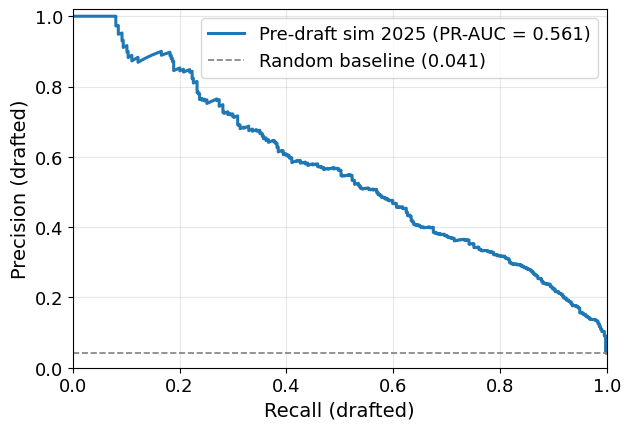


Graded board (predicted vs actual); actually_drafted=False rows are pre-draft 'misses':


,Predicted_Draft_Order,Tier,nameascii,draft_prob,pred_bonus,eligibility_basis,actual_pick,College_Draft_Order,pipeline_rank,api_signingBonus,actually_drafted
0,1,Early,Devin Taylor,100.000000,3.315917e+06,seasons,48.0,28.0,30.0,2.500000,True
1,2,Early,Andrew Fischer,100.000000,3.026828e+06,seasons,20.0,11.0,29.0,3.500000,True
2,3,Early,Anthony Eyanson,100.000000,2.353286e+06,seasons,87.0,52.0,40.0,1.750000,True
3,4,Early,Liam Doyle,100.000000,2.964052e+06,seasons,5.0,3.0,8.0,7.250000,True
4,5,Early,JD Thompson,100.000000,1.843278e+06,seasons,59.0,33.0,NaN,1.560200,True
5,6,Early,Kyson Witherspoon,100.000000,1.511092e+06,class,15.0,7.0,10.0,5.000000,True
6,7,Early,Patrick Forbes,100.000000,1.605264e+06,seasons,29.0,14.0,31.0,3.000000,True
7,8,Early,Zach Root,99.900002,2.154248e+06,seasons,40.0,21.0,42.0,2.197500,True
8,9,Early,Jamie Arnold,100.000000,1.708026e+06,seasons,11.0,5.0,4.0,5.985100,True
9,10,Early,Wehiwa Aloy,100.000000,2.681833e+06,seasons,31.0,16.0,17.0,3.042800,True


In [99]:
# ---- Grade the simulated board against what ACTUALLY happened + MLB Pipeline ----
_clean = lambda s: str(s).strip().lower()

# Actual SIM_TEST_YEAR outcomes. Rename Pick -> actual_pick: sim_board already carries
# a 'Pick' column, so an un-renamed merge would collide into Pick_x / Pick_y.
actual_detail = (draftedClean_df[draftedClean_df[year_col] == SIM_TEST_YEAR]
                 [['nameascii', 'Pick', 'College_Draft_Order',
                   'api_signingBonus', 'api_pickValue']].copy()
                 .rename(columns={'Pick': 'actual_pick'}))
drafted_names = set(df[(df[year_col] == SIM_TEST_YEAR) & (df['Drafted?'] == 1)]['nameascii'])
sim['actual_drafted'] = sim['nameascii'].isin(drafted_names).astype(int)

print("=" * 72)
print(f"PRE-DRAFT SIMULATION GRADED vs REALITY — {SIM_TEST_YEAR}")
print("=" * 72)

# ---------- STAGE 1: draftable? evaluated on the FULL population ----------
y_true, y_score = sim['actual_drafted'].values, sim['draft_prob'].values
ap = average_precision_score(y_true, y_score)
auc = roc_auc_score(y_true, y_score)
pred_pos = sim['draft_prob'] >= PROB_GATE
TP = int((pred_pos & (sim['actual_drafted'] == 1)).sum())
FP = int((pred_pos & (sim['actual_drafted'] == 0)).sum())
FN = int((~pred_pos & (sim['actual_drafted'] == 1)).sum())
prec = TP / (TP + FP) if TP + FP else float('nan')
rec = TP / (TP + FN) if TP + FN else float('nan')
print(f"\nSTAGE 1 — Draftable?  (all {len(sim)} players; {int(y_true.sum())} were actually drafted)")
print(f"  PR-AUC {ap:.3f}   ROC-AUC {auc:.3f}")
print(f"  At gate P>= {PROB_GATE:.0%}: flagged {int(pred_pos.sum())}  ->  "
      f"precision {prec:.3f}  recall {rec:.3f}   (TP {TP}, FP {FP}, FN {FN})")

# ---------- ELIGIBILITY FILTER AUDIT: did we wrongly remove real draftees? ----------
removed = gated[~gated['eligible']].copy()
removed['actually_drafted'] = removed['nameascii'].isin(drafted_names)
n_removed, n_bad = len(removed), int(removed['actually_drafted'].sum())
print(f"\nELIGIBILITY FILTER AUDIT:")
print(f"  Removed {n_removed} gated players as ineligible.")
print(f"  Of those, {n_bad} were ACTUALLY drafted -> FALSE removals "
      f"({n_bad/n_removed*100:.0f}% of removals)." if n_removed else "  (nothing removed)")
if n_bad:
    _bad = (removed[removed['actually_drafted']]
            .merge(actual_detail, on='nameascii', how='left').sort_values('actual_pick'))
    print(f"  Actually-drafted players the filter wrongly cut (pick | name | class | seasons):")
    for _, x in _bad.iterrows():
        _pk = f"#{int(x['actual_pick'])}" if pd.notna(x['actual_pick']) else "n/a"
        print(f"    {_pk:>4}  {x['nameascii']:22} class {x['class_ord']}  {int(x['total_college_seasons'])} seasons")

# ---------- BOARD hit-rate vs MLB Pipeline ----------
# Our board is college-only by construction, but MLB Pipeline's top-250 mixes in high
# schoolers, who can NEVER register as a hit here because drafted_names comes from the
# college dataset. Scoring Pipeline's raw list therefore understates it badly (V9 and V10
# both do this). Report the raw list for continuity and the college-only list for the
# like-for-like comparison.
prosp = prospects_by_year.get(SIM_TEST_YEAR)
_college_pop = {_clean(n) for n in sim['nameascii'].dropna()}
if prosp is not None:
    prosp_names = prosp.sort_values('rank')['name_clean'].tolist()
    prosp_college = [n for n in prosp_names if n in _college_pop]
else:
    prosp_names, prosp_college = [], []
drafted_clean = {_clean(n) for n in drafted_names}
board_names = sim_board['nameascii'].map(_clean).tolist()
def _hits(names, k):
    top = names[:k]
    return sum(n in drafted_clean for n in top), len(top)
print(f"\nBOARD QUALITY — of the top-K names, how many were ACTUALLY drafted:")
print(f"  {'K':>4} {'your board':>14} {'Pipeline raw':>14} {'Pipeline college-only':>23}")
for k in [50, 100, 200, BOARD_SIZE]:
    yb, pb, pc = _hits(board_names, k), _hits(prosp_names, k), _hits(prosp_college, k)
    print(f"  {k:>4} {f'{yb[0]}/{yb[1]}':>14} {f'{pb[0]}/{pb[1]}':>14} {f'{pc[0]}/{pc[1]}':>23}")
print(f"  NOTE: {len(prosp_college)}/{len(prosp_names)} of Pipeline's top-250 are college "
      f"players; the rest are high schoolers and cannot be hits in a college-only dataset.")
print(f"  Use the college-only column for any head-to-head claim.")

# ---------- STAGE 2: order among board players who were actually drafted ----------
bd = sim_board.merge(actual_detail, on='nameascii', how='left')
bd['name_clean'] = bd['nameascii'].map(_clean)
if prosp is not None:
    bd = bd.merge(prosp[['name_clean', 'rank']].rename(columns={'rank': 'pipeline_rank'}),
                  on='name_clean', how='left')
else:
    bd['pipeline_rank'] = np.nan
m2 = bd[bd['College_Draft_Order'].notna()]
sp_m = mae_m = np.nan
print(f"\nSTAGE 2 — Draft order  (board players who were actually drafted, n={len(m2)}):")
if len(m2) >= 5:
    sp_m, _ = spearmanr(m2['College_Draft_Order'], m2['Predicted_Draft_Order'])
    mae_m = mean_absolute_error(m2['College_Draft_Order'].rank(method='min'),
                                m2['Predicted_Draft_Order'].rank(method='min'))
    print(f"  Model vs actual:         Spearman {sp_m:.3f}   MAE(rank) {mae_m:.1f}")
    mp = m2[m2['pipeline_rank'].notna()]
    if len(mp) >= 5:
        sp_p, _ = spearmanr(mp['College_Draft_Order'], mp['pipeline_rank'])
        print(f"  MLB Pipeline vs actual:  Spearman {sp_p:.3f}   (n={len(mp)})")

# ---------- STAGE 3: bonus/slot among board players actually drafted ----------
mb, ms = bd[bd['api_signingBonus'].notna()], bd[bd['api_pickValue'].notna()]
print(f"\nSTAGE 3 — Signing bonus & slot value  (board players actually drafted):")
if len(mb):
    ab = mb['api_signingBonus'] * 1e6
    print(f"  Bonus n={len(mb):>3}  MAE ${mean_absolute_error(ab, mb['pred_bonus']):>11,.0f}"
          f"  R2 {r2_score(ab, mb['pred_bonus']):>6.3f}  Spearman {spearmanr(ab, mb['pred_bonus'])[0]:>6.3f}")
if len(ms):
    aslot = ms['api_pickValue'] * 1e6
    print(f"  Slot  n={len(ms):>3}  MAE ${mean_absolute_error(aslot, ms['pred_slot']):>11,.0f}"
          f"  R2 {r2_score(aslot, ms['pred_slot']):>6.3f}  Spearman {spearmanr(aslot, ms['pred_slot'])[0]:>6.3f}")

METRICS['sim_predraft'] = dict(
    sim_year=int(SIM_TEST_YEAR), n_population=int(len(sim)),
    n_actually_drafted=int(y_true.sum()), prob_gate=float(PROB_GATE),
    pr_auc=float(ap), roc_auc=float(auc),
    precision_at_gate=float(prec), recall_at_gate=float(rec),
    board_size=int(len(sim_board)), n_removed_ineligible=int(n_removed),
    n_false_removals=int(n_bad),
    stage2_spearman=float(sp_m), stage2_mae_rank=float(mae_m),
)

# Stage 1 on the full pre-draft population -- the operational curve that matters here.
plot_pr_curve(y_true, y_score, stage=1, name='pr_curve_predraft_sim',
              label=f'Pre-draft sim {SIM_TEST_YEAR}')

# Graded board for inspection (predicted next to actual).
sim_board_graded = bd[['Predicted_Draft_Order', 'Tier', 'nameascii', 'draft_prob',
                       'pred_bonus', 'eligibility_basis', 'actual_pick', 'College_Draft_Order',
                       'pipeline_rank', 'api_signingBonus']].copy()
sim_board_graded['actually_drafted'] = sim_board_graded['nameascii'].isin(drafted_names)
sim_board_graded['draft_prob'] = (sim_board_graded['draft_prob'] * 100).round(1)
print(f"\nGraded board (predicted vs actual); actually_drafted=False rows are pre-draft 'misses':")
pd.set_option('display.max_rows', 60)
display(sim_board_graded.head(50))

In [100]:
# ---- Per-player pre-draft trace (sim models) + demo ----
# Walk ANY SIM_TEST_YEAR player (drafted or not) through all 3 sim stages and line
# it up against the real outcome and the MLB Pipeline rank.
def _money2(x):
    return f"${x:,.0f}" if x is not None and pd.notna(x) else "n/a"

def sim_trace(name_query, verbose=True):
    names = sim['nameascii'].dropna().unique().tolist()
    m = get_close_matches(name_query, names, n=1, cutoff=0.4)
    if not m:
        if verbose: print(f"No {SIM_TEST_YEAR} player match for '{name_query}'")
        return None
    r = sim[sim['nameascii'] == m[0]].iloc[0]
    nm = r['nameascii']
    role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Two-Way'}.get(r['role'], '?')
    act = actual_detail[actual_detail['nameascii'] == nm]
    was_drafted = nm in drafted_names
    prosp = prospects_by_year.get(SIM_TEST_YEAR)
    pr = prosp[prosp['name_clean'] == str(nm).strip().lower()] if prosp is not None else None
    pipe_rank = int(pr.iloc[0]['rank']) if pr is not None and len(pr) else None
    on_board = sim_board[sim_board['nameascii'] == nm]
    board_pos = int(on_board.iloc[0]['Predicted_Draft_Order']) if len(on_board) else None

    if verbose:
        L = "=" * 68
        print(L)
        print(f"PRE-DRAFT TRACE — {nm}  ({SIM_TEST_YEAR})  |  {role_name}  "
              f"|  eligibility: {r['eligibility_basis']}")
        print(L)
        print("STAGE 1 — Draftable?")
        print(f"  Model P(drafted):   {r['draft_prob']*100:5.1f}%   "
              f"(gate {PROB_GATE:.0%}: {'PASS' if r['draft_prob']>=PROB_GATE else 'below'})")
        print(f"  Real:               {'DRAFTED' if was_drafted else 'NOT drafted'}"
              + (f" — overall pick #{int(act.iloc[0]['actual_pick'])}" if was_drafted and len(act) else ""))
        print(f"  MLB Pipeline:       " + (f"#{pipe_rank} of top-250" if pipe_rank else "not in top-250"))
        if not r['eligible']:
            print(f"  -> removed from board (draft-ineligible: {r['eligibility_basis']}, "
                  f"class {r['class_ord']}, {int(r['total_college_seasons'])} college seasons)")
        else:
            print("STAGE 2 — Draft order")
            print(f"  Board position:     " + (f"#{board_pos}" if board_pos else "not on board (missed gate)"))
            ao = int(act.iloc[0]['College_Draft_Order']) if was_drafted and len(act) else None
            print(f"  Real college order: " + (f"{ao}" if ao else "n/a (not drafted)"))
            print(f"  MLB Pipeline order: " + (f"{pipe_rank}" if pipe_rank else "n/a"))
            print("STAGE 3 — Signing bonus & slot value")
            ab = act.iloc[0]['api_signingBonus'] * 1e6 if was_drafted and len(act) and pd.notna(act.iloc[0]['api_signingBonus']) else None
            aslot = act.iloc[0]['api_pickValue'] * 1e6 if was_drafted and len(act) and pd.notna(act.iloc[0]['api_pickValue']) else None
            print(f"  Model bonus:        {_money2(r['pred_bonus']):>13}   Real: {_money2(ab):>13}")
            print(f"  Model slot:         {_money2(r['pred_slot']):>13}   Real: {_money2(aslot):>13}")
        print(L)
    return r

print("sim_trace() defined. Usage: sim_trace('Kade Anderson')\n")

# Demo: top-3 board players, plus the top few high-confidence players REMOVED for
# ineligibility (the filter in action).
for _nm in sim_board['nameascii'].head(3).tolist():
    sim_trace(_nm)

_removed = gated[~gated['eligible']].head(5)
if len(_removed):
    print("\nTop high-confidence players REMOVED by the eligibility filter "
          "(would-be board spot -> reason):")
    for _, _r in _removed.iterrows():
        print(f"  raw #{int(_r['raw_board_pos']):>3}  {_r['nameascii']:22} "
              f"P={_r['draft_prob']*100:4.1f}%  class {_r['class_ord']}  "
              f"{int(_r['total_college_seasons'])} seasons  ({_r['eligibility_basis']})")
    _ex = _removed.iloc[0]['nameascii']
    print()
    sim_trace(_ex)

sim_trace() defined. Usage: sim_trace('Kade Anderson')

PRE-DRAFT TRACE — Devin Taylor  (2025)  |  Batter  |  eligibility: seasons
STAGE 1 — Draftable?
  Model P(drafted):   100.0%   (gate 90%: PASS)
  Real:               DRAFTED — overall pick #48
  MLB Pipeline:       #30 of top-250
STAGE 2 — Draft order
  Board position:     #1
  Real college order: 28
  MLB Pipeline order: 30
STAGE 3 — Signing bonus & slot value
  Model bonus:           $3,315,917   Real:    $2,500,000
  Model slot:            $2,068,776   Real:    $2,031,500


PRE-DRAFT TRACE — Andrew Fischer  (2025)  |  Batter  |  eligibility: seasons
STAGE 1 — Draftable?
  Model P(drafted):   100.0%   (gate 90%: PASS)
  Real:               DRAFTED — overall pick #20
  MLB Pipeline:       #29 of top-250
STAGE 2 — Draft order
  Board position:     #2
  Real college order: 11
  MLB Pipeline order: 29
STAGE 3 — Signing bonus & slot value
  Model bonus:           $3,026,828   Real:    $3,500,000
  Model slot:            $3,529,004   Real:    $4,268,100
PRE-DRAFT TRACE — Anthony Eyanson  (2025)  |  Pitcher  |  eligibility: seasons
STAGE 1 — Draftable?
  Model P(drafted):   100.0%   (gate 90%: PASS)
  Real:               DRAFTED — overall pick #87
  MLB Pipeline:       #40 of top-250
STAGE 2 — Draft order
  Board position:     #3
  Real college order: 52
  MLB Pipeline order: 40
STAGE 3 — Signing bonus & slot value
  Model bonus:           $2,353,286   Real:    $1,750,000
  Model slot:            $2,298,987   Real:      $907,200

Top high-confidence players REMOV

PRE-DRAFT TRACE — Kade Anderson  (2025)  |  Pitcher  |  eligibility: ineligible
STAGE 1 — Draftable?
  Model P(drafted):    99.9%   (gate 90%: PASS)
  Real:               DRAFTED — overall pick #3
  MLB Pipeline:       #2 of top-250
  -> removed from board (draft-ineligible: ineligible, class 2.0, 2 college seasons)


---
## Metrics Ledger

Machine-readable dump of every headline metric, for the before/after
comparison. Kept above the Carbon Tracking cells because the last cell
rebinds `df` to the emissions frame.

In [101]:
METRICS['run'] = dict(tag=RUN_TAG, data_file=DATA_FILE, max_year=MAX_YEAR,
                      role_fix=ROLE_FIX, slot_zero_null=SLOT_ZERO_NULL,
                      usage_features=USAGE_FEATURES,
                      test_year=int(test_year),
                      n_rows=int(len(X)), n_features=int(len(features)))

print('===METRICS_JSON_START')
print(json.dumps(METRICS, indent=2, default=float))
print('===METRICS_JSON_END')

===METRICS_JSON_START
{
  "s1_balanced": {
    "n": 844,
    "accuracy": 0.8957345971563981,
    "precision": 0.8711111111111111,
    "recall": 0.9289099526066351,
    "f1": 0.8990825688073395,
    "roc_auc": 0.9610745490891939
  },
  "s1_operational": {
    "n": 10172,
    "n_pos": 422,
    "base_rate": 0.04148643334644121,
    "pr_auc": 0.5564595046216735,
    "roc_auc": 0.9617781018349738,
    "pr_lift": 13.413047585335693,
    "thresholds": {
      "0.50": {
        "precision": 0.24794433902593296,
        "recall": 0.9289099526066351,
        "f1": 0.3914128806789815
      },
      "0.40": {
        "precision": 0.23140011716461628,
        "recall": 0.9360189573459715,
        "f1": 0.371066228276186
      },
      "0.30": {
        "precision": 0.21192758253461128,
        "recall": 0.943127962085308,
        "f1": 0.34608695652173915
      },
      "0.20": {
        "precision": 0.19384319384319385,
        "recall": 0.9549763033175356,
        "f1": 0.32227109156337463
      

## Carbon Tracking

In [102]:
emissions = tracker.stop()

# Constants for equivalencies
CAR_EMISSION_FACTOR = 0.12        # kgCO2 per km
TV_DAILY_WH = 138                 # Wh per day
TV_EMISSION_FACTOR = 0.084        # kgCO2 per kWh (implied by source)
US_WEEKLY_KG = (13.3 * 1000) / 52  # kg CO2 per week for avg US citizen

energy_kwh = tracker.final_emissions_data.energy_consumed

print("\nCarbon Emissions Summary:")
print(f"  Total CO₂ emitted:     {emissions:.7f} kg")
print(f"  Total energy consumed: {energy_kwh:.7f} kWh")
print(f"  Total cost of energy:  ${tracker.final_emissions_data.energy_consumed*0.269141194:.7f} USD")
print(f"    CPU energy:          {tracker.final_emissions_data.cpu_energy:.7f} kWh")
print(f"    RAM energy:          {tracker.final_emissions_data.ram_energy:.7f} kWh")
_gpu_kwh = tracker.final_emissions_data.gpu_energy
def _nvidia_gpu_present():
    try:
        pynvml.nvmlInit()
        n = pynvml.nvmlDeviceGetCount()
        pynvml.nvmlShutdown()
        return n > 0
    except Exception:
        return False
if _gpu_kwh == 0 and not _nvidia_gpu_present():
    print(f"    GPU energy:          N/A (no NVIDIA GPU detected by codecarbon)")
else:
    print(f"    GPU energy:          {_gpu_kwh:.7f} kWh")
print(f"  Duration:              {tracker.final_emissions_data.duration:.2f} s")

print("\nEquivalency Estimates:")
print(f"  🚗 Car distance:       {emissions / CAR_EMISSION_FACTOR:.4f} km driven")
print(f"  📺 TV usage:           {(energy_kwh / (TV_DAILY_WH / 1000)):.4f} days of TV")
print(f"  🧍 US citizen:         {(emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")

# Cumulative stats from emissions.csv
EMISSIONS_CSV = os.path.join(os.getcwd(), "emissions.csv")

if os.path.exists(EMISSIONS_CSV):
    df = pd.read_csv(EMISSIONS_CSV)
    total_emissions = df["emissions"].sum()
    total_energy    = df["energy_consumed"].sum()
    total_duration  = df["duration"].sum()
    n_runs          = len(df)

    print(f"\nCumulative Summary ({n_runs} runs):")
    print(f"  Total CO₂ emitted:     {total_emissions:.7f} kg")
    print(f"  Total energy consumed: {total_energy:.7f} kWh")
    print(f"  Total cost of energy:  ${total_energy * 0.269141194:.7f} USD")
    print(f"  Total duration:        {total_duration:.2f} s ({total_duration/3600:.2f} hrs)")

    print("\nEquivalency Estimates (Cumulative):")
    print(f"  🚗 Car distance:       {total_emissions / CAR_EMISSION_FACTOR:.4f} km driven")
    print(f"  📺 TV usage:           {(total_energy / (TV_DAILY_WH / 1000)):.4f} days of TV")
    print(f"  🧍 US citizen:         {(total_emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")


Carbon Emissions Summary:
  Total CO₂ emitted:     0.0003754 kg
  Total energy consumed: 0.0010160 kWh
  Total cost of energy:  $0.0002735 USD
    CPU energy:          0.0008903 kWh
    RAM energy:          0.0001257 kWh
    GPU energy:          N/A (no NVIDIA GPU detected by codecarbon)
  Duration:              75.42 s

Equivalency Estimates:
  🚗 Car distance:       0.0031 km driven
  📺 TV usage:           0.0074 days of TV
  🧍 US citizen:         0.000147% of weekly per-capita emissions

Cumulative Summary (88 runs):
  Total CO₂ emitted:     0.0295099 kg
  Total energy consumed: 0.0798703 kWh
  Total cost of energy:  $0.0214964 USD
  Total duration:        6008.36 s (1.67 hrs)

Equivalency Estimates (Cumulative):
  🚗 Car distance:       0.2459 km driven
  📺 TV usage:           0.5788 days of TV
  🧍 US citizen:         0.011538% of weekly per-capita emissions
